# **Model Benchmark**

In [2]:
#Install Dependencies
#Unsloth= fastest way to load + train LLMs on Colab T4
# It uses 60% less VRAM than standard HuggingFace
!pip install -q "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"

# Core ML libraries
!pip install -q transformers==4.40.0
!pip install -q datasets accelerate bitsandbytes peft trl

# Evaluation + visualisation
!pip install -q rouge-score seaborn matplotlib scikit-learn

# Utility
!pip install -q sentencepiece protobuf

print("=" * 50)
print("✅ All packages installed successfully")
print("=" * 50)

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 126.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 418.4/418.4 kB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 131.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 120.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.8/224.8 kB 24.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 6.1 MB

In [3]:
# Quick sanity check
import torch
print(f"\n PyTorch version  : {torch.__version__}")
print(f" CUDA available   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f" GPU              : {torch.cuda.get_device_name(0)}")
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f" Total VRAM       : {total:.1f} GB")
    print(f"\n{'✅ T4 detected — proceed normally' if total > 13 else '⚠️  Low VRAM GPU — use 3B model instead of 7B (see Cell 4)'}")



 PyTorch version  : 2.10.0+cu128
 CUDA available   : True
 GPU              : Tesla T4
 Total VRAM       : 15.6 GB

✅ T4 detected — proceed normally


Mounting Google Drive + Creating Folder Structure

In [4]:
from google.colab import drive
import os

#Step 1: Mount Drive
print("📂 Mounting Google Drive...")
drive.mount('/content/drive')
print("✅ Drive mounted successfully\n")

📂 Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted successfully



In [5]:
# Step 2: Define all paths

BASE_DIR    = '/content/drive/MyDrive/syNNapse26'
LORA_DIR    = f'{BASE_DIR}/lora_model'          # LoRA weights save here
BASE_RES    = f'{BASE_DIR}/base_results'        # Base model eval results
PT_RES      = f'{BASE_DIR}/pretrained_results'  # Pretrained model eval results
PLOTS_DIR   = f'{BASE_DIR}/plots'               # All seaborn charts

In [6]:
#─ Step 3: Create folders
for folder in [BASE_DIR, LORA_DIR, BASE_RES, PT_RES, PLOTS_DIR]:
    os.makedirs(folder, exist_ok=True)

In [7]:
# Step 4: Save paths to a config file

import json
config = {
    'BASE_DIR'  : BASE_DIR,
    'LORA_DIR'  : LORA_DIR,
    'BASE_RES'  : BASE_RES,
    'PT_RES'    : PT_RES,
    'PLOTS_DIR' : PLOTS_DIR
}
with open(f'{BASE_DIR}/paths_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print(f"\n✅ Paths saved to Drive → paths_config.json")
print("   (If GPU resets, run this cell again to reload paths)")



✅ Paths saved to Drive → paths_config.json
   (If GPU resets, run this cell again to reload paths)


Prepare Evaluation Dataset


In [8]:
import json
import os

# Load paths from config (in case of GPU reset)
with open('/content/drive/MyDrive/syNNapse26/paths_config.json') as f:
    PATHS = json.load(f)

In [10]:
# Load existing dataset
with open("eval_data.json", "r", encoding="utf-8") as f:
    data = json.load(f)

In [11]:
EVAL_DATA = []

def clean_keywords(keywords):
    cleaned = []
    for k in keywords:
        if not k:
            continue
        k = k.strip().lower()

        # remove invalid entries like 'nan'
        if k == "nan":
            continue

        cleaned.append(k)

    return cleaned

for idx, item in enumerate(data):
    eval_item = {
        "id": idx + 1,
        "input": item.get("input", ""),
        "expected_disease": item.get("expected_disease", ""),
        "expected_treatment_keywords": clean_keywords(
            item.get("expected_treatment_keywords", [])
        )
    }

    EVAL_DATA.append(eval_item)

# Save cleaned data
with open("eval_data.json", "w", encoding="utf-8") as f:
    json.dump(EVAL_DATA, f, indent=2)

print("✅ Clean eval_data.json created!")

✅ Clean eval_data.json created!


In [13]:
EVAL_DATA[:5]

[{'id': 1,
  'input': 'Symptoms: itchy skin, particularly on the hands and feet | History: general risk',
  'expected_disease': 'Gestational Cholestasis',
  'expected_treatment_keywords': []},
 {'id': 2,
  'input': 'Symptoms: abdominal pain, bleeding, organ dysfunction | History: general risk',
  'expected_disease': 'Injury to Internal Organ',
  'expected_treatment_keywords': ['immediate medical attention',
   'diagnostic tests',
   'surgery (in some cases)']},
 {'id': 3,
  'input': 'Symptoms: intense itching, especially at night, small blisters or bumps | History: general risk',
  'expected_disease': 'Scabies',
  'expected_treatment_keywords': ['prescription medications (topical or oral scabicides)',
   'washing clothes and bedding in hot water',
   'vacuuming and cleaning home']},
 {'id': 4,
  'input': 'Symptoms: cloudy or hazy eyes, excessive tearing, sensitivity to light | History: general risk',
  'expected_disease': 'Congenital Glaucoma',
  'expected_treatment_keywords': ['surger

In [14]:
#save eval data to drive
eval_path = f"{PATHS['BASE_DIR']}/eval_data.json"
with open(eval_path, 'w') as f:
    json.dump(EVAL_DATA, f, indent=2)

print("=" * 50)
print(f"✅ Eval dataset ready")
print(f"   Total samples  : {len(EVAL_DATA)}")
print(f"   Saved to Drive : {eval_path}")
print("=" * 50)
print("\nSample check (first entry):")
print(f"  Input    : {EVAL_DATA[0]['input'][:60]}...")
print(f"  Disease  : {EVAL_DATA[0]['expected_disease']}")
print(f"  Keywords : {EVAL_DATA[0]['expected_treatment_keywords']}")


✅ Eval dataset ready
   Total samples  : 50
   Saved to Drive : /content/drive/MyDrive/syNNapse26/eval_data.json

Sample check (first entry):
  Input    : Symptoms: itchy skin, particularly on the hands and feet | H...
  Disease  : Gestational Cholestasis
  Keywords : []


Load Base Model (4-bit Quantization) via Unsloth



In [15]:
import torch
import gc
import json
from unsloth import FastLanguageModel

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [16]:
with open('/content/drive/MyDrive/syNNapse26/paths_config.json') as f:
    PATHS = json.load(f)

In [17]:
#GPU Health Check
def check_gpu():
    if not torch.cuda.is_available():
        raise RuntimeError("❌ No GPU found! Go to Runtime → Change runtime type → GPU")
    used  = torch.cuda.memory_allocated() / 1e9
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    free  = total - used
    print(f" GPU   : {torch.cuda.get_device_name(0)}")
    print(f" VRAM  : {used:.1f} GB used / {total:.1f} GB total / {free:.1f} GB free")
    return free

In [18]:
free_vram = check_gpu()
print()

 GPU   : Tesla T4
 VRAM  : 0.0 GB used / 15.6 GB total / 15.6 GB free



In [19]:
# Model Selection
# Use 7B if free VRAM > 8 GB, else use 3B automatically
if free_vram > 8:
    MODEL_NAME = "unsloth/mistral-7b-instruct-v0.3-bnb-4bit"
    print("✅ Sufficient VRAM → Loading Mistral-7B (4-bit)")
else:
    MODEL_NAME = "unsloth/Llama-3.2-3B-Instruct-bnb-4bit"
    print("⚠️  Low VRAM detected → Switching to Llama-3.2-3B (4-bit)")


✅ Sufficient VRAM → Loading Mistral-7B (4-bit)


In [20]:
# Config
MAX_SEQ_LENGTH = 512   # Keep low → saves VRAM during training
DTYPE          = None  # None = auto-detect (bfloat16 on A100, float16 on T4)
LOAD_IN_4BIT   = True  # 4-bit = ~4x less VRAM than full precision



In [21]:
# Load Model
base_model, tokenizer = FastLanguageModel.from_pretrained(
    model_name      = MODEL_NAME,
    max_seq_length  = MAX_SEQ_LENGTH,
    dtype           = DTYPE,
    load_in_4bit    = LOAD_IN_4BIT,
)


==((====))==  Unsloth 2026.4.4: Fast Mistral patching. Transformers: 5.5.3.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/4.14G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/157 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/587k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/446 [00:00<?, ?B/s]

In [22]:
# Save model name to config for later cells
with open('/content/drive/MyDrive/syNNapse26/paths_config.json') as f:
    config = json.load(f)
config['MODEL_NAME']      = MODEL_NAME
config['MAX_SEQ_LENGTH']  = MAX_SEQ_LENGTH
config['LOAD_IN_4BIT']    = LOAD_IN_4BIT
with open('/content/drive/MyDrive/syNNapse26/paths_config.json', 'w') as f:
    json.dump(config, f, indent=2)

In [23]:
# Post-load GPU check
print("\n VRAM after model load:")
check_gpu()

print("\n" + "=" * 50)
print("✅ Base model loaded and ready")
print(f"   Model : {MODEL_NAME}")
print(f"   Dtype : {base_model.dtype}")
print("=" * 50)


 VRAM after model load:
 GPU   : Tesla T4
 VRAM  : 4.2 GB used / 15.6 GB total / 11.5 GB free

✅ Base model loaded and ready
   Model : unsloth/mistral-7b-instruct-v0.3-bnb-4bit
   Dtype : torch.float16


Defining All Evaluation Functions

In [37]:
import time
import torch
import json
from unsloth import FastLanguageModel

In [38]:
# Reload paths (safe if GPU reset)
with open('/content/drive/MyDrive/syNNapse26/paths_config.json') as f:
    PATHS = json.load(f)


In [39]:
#Function-1-> Build Prompt in correct Mistral format
def build_prompt(user_input, model_name="mistral"):
    """
    Different models need different prompt formats.
    Mistral uses [INST]...[/INST]
    Llama-3 uses <|begin_of_text|> style
    We auto-detect from model name.
    """
    system = "You are an AI medical assistant. Given symptoms and history, identify the disease, provide reasoning, and suggest treatment."
    if "mistral" in model_name.lower():
        return f"[INST] {system}\n\n{user_input} [/INST]"
    else:
        return (
            f"<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n"
            f"{system}<|eot_id|>"
            f"<|start_header_id|>user<|end_header_id|>\n"
            f"{user_input}<|eot_id|>"
            f"<|start_header_id|>assistant<|end_header_id|>\n"
        )


In [40]:
#Function-2-> Generate a single response from model
def generate_response(model, tokenizer, user_input, max_new_tokens=200):
    """
    Generates model output for one input.

    Returns:
        response (str)     : model's text output
        latency (float)    : time taken in seconds
        input_tokens (int) : prompt token count
        output_tokens(int) : generated token count
    """
    # Switch model to inference mode (disables dropout etc.)
    FastLanguageModel.for_inference(model)
    model_name   = PATHS.get('MODEL_NAME', 'mistral')
    prompt       = build_prompt(user_input, model_name)
    inputs       = tokenizer(prompt, return_tensors='pt').to('cuda')
    input_tokens = inputs['input_ids'].shape[1]

    start = time.time()
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens = max_new_tokens,
            temperature    = 0.1,
            do_sample      = True,
            pad_token_id   = tokenizer.eos_token_id,
            use_cache      = True,
        )
    latency = time.time() - start

    output_tokens = outputs.shape[1] - input_tokens
    response = tokenizer.decode(
        outputs[0][input_tokens:],
        skip_special_tokens=True
    )
    torch.cuda.empty_cache()
    return response.strip(), latency, input_tokens, output_tokens

In [49]:
#Function-3->Score a single model response
def score_response(response, expected_disease, expected_keywords):
    resp_lower = response.lower()

    # Metric 1: Disease Accuracy
    disease_correct = 1 if expected_disease.lower() in resp_lower else 0

    # Metric 2: Keyword Score
    if len(expected_keywords) == 0:
        keyword_score = 0.0
    else:
        hits = sum(1 for kw in expected_keywords if kw.lower() in resp_lower)
        keyword_score = hits / len(expected_keywords)

    # Metric 3: Hallucination — FIXED ──────────────────────────
    # OLD logic: only flagged if "Disease:" line found but wrong
    # NEW logic: if model named ANY disease confidently but got
    #            it wrong → hallucination
    #            if disease_correct = 0 AND response is non-empty
    #            AND response seems to name something → hallucinated

    hallucinated = 0
    if disease_correct == 0 and len(response.strip()) > 20:
        # Check if model gave a confident-sounding answer
        # (not just "I don't know" type responses)
        uncertain_phrases = [
            "cannot determine", "insufficient", "unclear",
            "more information", "consult", "i don't know",
            "i'm not sure", "multiple possible"
        ]
        seems_uncertain = any(p in resp_lower for p in uncertain_phrases)
        if not seems_uncertain:
            hallucinated = 1   # Named something, got it wrong = hallucinated

    return {
        'disease_accuracy'        : disease_correct,
        'treatment_keyword_score' : round(keyword_score, 3),
        'hallucinated'            : hallucinated
    }


In [42]:
#Function-4-> Run full evaluation on all the samples
def run_evaluation(model, tokenizer, eval_data, model_label):
    results = []
    print(f"\n{'='*55}")
    print(f" Evaluating: {model_label}")
    print(f" Samples: {len(eval_data)}")
    print(f"{'='*55}")

    for i, item in enumerate(eval_data):
        # Safety check: ensure required fields exist
        if 'input' not in item or 'expected_disease' not in item:
            print(f"  ⚠️  Skipping sample {item.get('id','?')} — missing fields")
            continue

        # Ensure keywords is always a list (never None)
        keywords = item.get('expected_treatment_keywords') or []

        print(f"\n[{i+1}/{len(eval_data)}] {item['input'][:55]}...")

        try:
            response, latency, in_tok, out_tok = generate_response(
                model, tokenizer, item['input']
            )
            scores = score_response(response, item['expected_disease'], keywords)

        except Exception as e:
            # If generation itself fails, record zeros and continue
            print(f"    ❌ Generation error: {e} — recording zeros")
            response = ""
            latency  = 0.0
            in_tok   = 0
            out_tok  = 0
            scores   = {'disease_accuracy': 0, 'treatment_keyword_score': 0.0, 'hallucinated': 0}

        result = {
            'id'               : item.get('id', i+1),
            'input'            : item['input'],
            'expected_disease' : item['expected_disease'],
            'model_response'   : response,
            'latency_sec'      : round(latency, 2),
            'input_tokens'     : in_tok,
            'output_tokens'    : out_tok,
            **scores
        }
        results.append(result)

        d_icon = '✅' if scores['disease_accuracy']  else '❌'
        h_icon = '⚠️ ' if scores['hallucinated']      else '✅'
        print(f"    Disease: {d_icon}  Hallucinated: {h_icon}  "
              f"Keywords: {scores['treatment_keyword_score']:.0%}  "
              f"Latency: {latency:.1f}s")

    print(f"\n✅ Done: {len(results)}/{len(eval_data)} samples evaluated")
    return results


In [43]:
#Function-5->Compute aggregate summary metrics
def compute_summary(results, model_label):
    n = len(results)
    if n == 0:
        print("❌ No results to summarize!")
        return {}
    return {
        'model'                  : model_label,
        'total_samples'          : n,
        'disease_accuracy_pct'   : round(sum(r['disease_accuracy'] for r in results) / n * 100, 1),
        'avg_keyword_score_pct'  : round(sum(r['treatment_keyword_score'] for r in results) / n * 100, 1),
        'hallucination_rate_pct' : round(sum(r['hallucinated'] for r in results) / n * 100, 1),
        'avg_latency_sec'        : round(sum(r['latency_sec'] for r in results) / n, 2),
        'avg_output_tokens'      : round(sum(r['output_tokens'] for r in results) / n, 1),
        'total_output_tokens'    : sum(r['output_tokens'] for r in results),
    }



Evaluate BASE Model & Save to Drive

In [44]:
import json
import torch

In [45]:
# Reload paths
with open('/content/drive/MyDrive/syNNapse26/paths_config.json') as f:
    PATHS = json.load(f)


In [46]:
# Load eval data from Drive
with open(f"{PATHS['BASE_DIR']}/eval_data.json") as f:
    EVAL_DATA = json.load(f)

In [47]:
print(f" Loaded {len(EVAL_DATA)} eval samples from Drive")
print(f" VRAM before eval: {torch.cuda.memory_allocated()/1e9:.1f} GB used")

 Loaded 50 eval samples from Drive
 VRAM before eval: 4.3 GB used


In [50]:
base_results = run_evaluation(
    model       = base_model,
    tokenizer   = tokenizer,
    eval_data   = EVAL_DATA,
    model_label = 'Base Model (Mistral-7B)'
)

Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



 Evaluating: Base Model (Mistral-7B)
 Samples: 50

[1/50] Symptoms: itchy skin, particularly on the hands and fee...


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


    Disease: ❌  Hallucinated: ⚠️   Keywords: 0%  Latency: 11.8s

[2/50] Symptoms: abdominal pain, bleeding, organ dysfunction |...


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

    Disease: ✅  Hallucinated: ✅  Keywords: 25%  Latency: 11.4s

[48/50] Symptoms: ear pain, hearing loss, ear drainage | Histor...


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


    Disease: ❌  Hallucinated: ⚠️   Keywords: 0%  Latency: 11.5s

[49/50] Symptoms: abdominal pain, high blood pressure, kidney c...


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


    Disease: ❌  Hallucinated: ⚠️   Keywords: 0%  Latency: 11.5s

[50/50] Symptoms: joint pain, swelling, stiffness | History: ge...
    Disease: ❌  Hallucinated: ⚠️   Keywords: 0%  Latency: 11.5s

✅ Done: 50/50 samples evaluated


In [51]:
# Compute summary
base_summary = compute_summary(base_results, 'Base Model')

In [53]:
# Save detailed results to Drive
detailed_path = f"{PATHS['BASE_RES']}/detailed_results.json"
summary_path  = f"{PATHS['BASE_RES']}/summary.json"
with open(detailed_path, 'w') as f:
    json.dump(base_results, f, indent=2)

with open(summary_path, 'w') as f:
    json.dump(base_summary, f, indent=2)

In [54]:
# Print summary
print("\n" + "=" * 55)
print("📊 BASE MODEL BENCHMARK RESULTS")
print("=" * 55)
print(f"  Disease Accuracy    : {base_summary['disease_accuracy_pct']}%")
print(f"  Hallucination Rate  : {base_summary['hallucination_rate_pct']}%  ← lower is better")
print(f"  Treatment Score     : {base_summary['avg_keyword_score_pct']}%")
print(f"  Avg Latency         : {base_summary['avg_latency_sec']} sec/query")
print(f"  Avg Output Tokens   : {base_summary['avg_output_tokens']}")
print("=" * 55)
print(f"\n✅ Saved to Drive:")
print(f"   {detailed_path}")
print(f"   {summary_path}")



📊 BASE MODEL BENCHMARK RESULTS
  Disease Accuracy    : 30.0%
  Hallucination Rate  : 68.0%  ← lower is better
  Treatment Score     : 8.0%
  Avg Latency         : 11.51 sec/query
  Avg Output Tokens   : 200.0

✅ Saved to Drive:
   /content/drive/MyDrive/syNNapse26/base_results/detailed_results.json
   /content/drive/MyDrive/syNNapse26/base_results/summary.json


In [55]:
# GPU status after eval
torch.cuda.empty_cache()
print(f"\n VRAM after eval (cache cleared): {torch.cuda.memory_allocated()/1e9:.1f} GB used")



 VRAM after eval (cache cleared): 4.3 GB used


**Attach LoRA Adapters to Base Model**

LoRA = Low-Rank Adaptation                               
*   Only trains small adapter matrices (~1-3% of params)
*   Full model stays frozen → saves VRAM


*   Acts as our "Continued Pretraining" for PS purposes






In [57]:
import torch
import json
from unsloth import FastLanguageModel

# ── Reload paths ───────────────────────────────────────────────
with open('/content/drive/MyDrive/syNNapse26/paths_config.json') as f:
    PATHS = json.load(f)

print(f" VRAM before LoRA attach: {torch.cuda.memory_allocated()/1e9:.1f} GB")

 VRAM before LoRA attach: 4.3 GB


In [58]:
# ATTACH LoRA ADAPTERS
#
# r = rank of LoRA matrices
#   → r=8  : very light, fast, less learning capacity
#   → r=16 : good balance (recommended for T4)
#   → r=32 : more capacity but uses more VRAM
#
# target_modules = which layers to adapt
#   → q_proj, k_proj, v_proj = attention query/key/value
#   → o_proj = attention output
#   → gate_proj, up_proj, down_proj = feed-forward layers
#   → All 7 = comprehensive adaptation
#
# use_gradient_checkpointing='unsloth'
#   → Trades compute for memory: recomputes activations
#     during backward pass instead of storing them
#   → Saves ~30% VRAM — critical for T4

In [59]:
model_for_training = FastLanguageModel.get_peft_model(
    base_model,
    r                        = 16,
    target_modules           = [
        'q_proj', 'k_proj', 'v_proj', 'o_proj',   # Attention layers
        'gate_proj', 'up_proj', 'down_proj'         # FFN layers
    ],
    lora_alpha               = 16,   # Scaling factor (usually = r)
    lora_dropout             = 0,    # 0 = faster, unsloth optimized
    bias                     = 'none',
    use_gradient_checkpointing = 'unsloth',  # Key for GPU survival
    random_state             = 42,
    use_rslora               = False,
    loftq_config             = None,
)


Unsloth 2026.4.4 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


In [62]:
print(f"\nTrainable parameters:")
model_for_training.print_trainable_parameters()


print(f"\n VRAM after LoRA attach: {torch.cuda.memory_allocated()/1e9:.1f} GB")
print("\n" + "=" * 50)
print("✅ LoRA adapters attached")

print("=" * 50)



Trainable parameters:
trainable params: 41,943,040 || all params: 7,289,966,592 || trainable%: 0.5754

 VRAM after LoRA attach: 4.4 GB

✅ LoRA adapters attached


Load & Format Training Dataset

In [63]:
import json
import torch
from datasets import Dataset

# Reload paths
with open('/content/drive/MyDrive/syNNapse26/paths_config.json') as f:
    PATHS = json.load(f)

MODEL_NAME = PATHS['MODEL_NAME']

In [64]:
# Upload via Colab widget


from google.colab import files
print("📂 Choose your training JSON file...")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
raw_data = json.loads(uploaded[filename].decode('utf-8'))
print(f"✅ Uploaded: {len(raw_data)} samples")


📂 Choose your training JSON file...


Saving llama_dataset.json to llama_dataset.json
✅ Uploaded: 395 samples


In [65]:
# Format data for unsloth
def format_for_training(example):
    """
    Converts message format to flat training string.

    Mistral format: [INST] system + user [/INST] assistant <eos>
    Llama-3 format: <|begin_of_text|>...<|eot_id|> etc.
    """
    messages  = example['messages']
    system    = messages[0]['content']
    user      = messages[1]['content']
    assistant = messages[2]['content']

    if 'mistral' in MODEL_NAME.lower():
        text = (
            f"[INST] {system}\n\n{user} [/INST] "
            f"{assistant}{tokenizer.eos_token}"
        )
    else:
        # Llama-3 format
        text = (
            f"<|begin_of_text|>"
            f"<|start_header_id|>system<|end_header_id|>\n{system}<|eot_id|>"
            f"<|start_header_id|>user<|end_header_id|>\n{user}<|eot_id|>"
            f"<|start_header_id|>assistant<|end_header_id|>\n{assistant}<|eot_id|>"
        )

    return {"text": text}

In [66]:
# Build HuggingFace Dataset
dataset = Dataset.from_list(raw_data)
dataset = dataset.map(format_for_training, remove_columns=dataset.column_names)


Map:   0%|          | 0/395 [00:00<?, ? examples/s]

In [67]:
# Quick length check (important for VRAM)
sample_tokens = tokenizer(dataset[0]['text'], return_tensors='pt')
sample_len    = sample_tokens['input_ids'].shape[1]
print(f"\n Sample token length check:")
print(f"   First sample: {sample_len} tokens")
if sample_len > PATHS['MAX_SEQ_LENGTH']:
    print(f"   ⚠️  Longer than MAX_SEQ_LENGTH ({PATHS['MAX_SEQ_LENGTH']})!")
    print(f"   Consider trimming or increasing MAX_SEQ_LENGTH in Cell 4")
else:
    print(f"   ✅ Within limit ({PATHS['MAX_SEQ_LENGTH']} tokens)")


 Sample token length check:
   First sample: 81 tokens
   ✅ Within limit (512 tokens)


In [68]:
print("\n" + "=" * 50)
print(f"✅ Training dataset ready")
print(f"   Total samples : {len(dataset)}")
print(f"   Format        : {'Mistral [INST]' if 'mistral' in MODEL_NAME.lower() else 'Llama-3'}")
print("=" * 50)
print("\nSample formatted text (first 300 chars):")
print(dataset[0]['text'][:300])



✅ Training dataset ready
   Total samples : 395
   Format        : Mistral [INST]

Sample formatted text (first 300 chars):
[INST] You are an AI medical assistant.

Symptoms: itchy skin, particularly on the hands and feet | History: general risk [/INST] Disease: Gestational Cholestasis
Reasoning: itchy skin, particularly on the hands and feet are strong indicators of Gestational Cholestasis. general risk increases risk.



LoRA Fine-tuning (Continued Pretraining)

In [69]:
import torch
import json
from trl import SFTTrainer
from transformers import TrainingArguments


In [71]:
# Reload paths
with open('/content/drive/MyDrive/syNNapse26/paths_config.json') as f:
    PATHS = json.load(f)

print(f" VRAM before training: {torch.cuda.memory_allocated()/1e9:.1f} GB")

 VRAM before training: 4.4 GB


TRAINING CONFIGURATION

per_device_train_batch_size=2
  → Process 2 samples at once
  → Lower = less VRAM but slower
  → If OOM error → set to 1

gradient_accumulation_steps=4
  → Accumulate gradients over 4 steps before updating
  → Effective batch size = 2 × 4 = 8
  → Simulates larger batch without extra VRAM

num_train_epochs=2
  → 2 full passes over training data
  → Enough for domain adaptation, won't overfit small dataset

save_strategy='epoch'
  → Save checkpoint to Drive after each epoch
  → Protects against GPU crash mid-training

optim='adamw_8bit'
  → 8-bit optimizer = half the VRAM of standard Adam
  → No quality loss, just memory savings

In [72]:
trainer = SFTTrainer(
    model              = model_for_training,
    tokenizer          = tokenizer,
    train_dataset      = dataset,
    dataset_text_field = 'text',
    max_seq_length     = PATHS['MAX_SEQ_LENGTH'],
    dataset_num_proc   = 1,     # 1 = safer on Colab (avoids multiprocessing errors)
    packing            = False, # False = each sample treated independently
    args = TrainingArguments(
        per_device_train_batch_size  = 2,
        gradient_accumulation_steps  = 4,
        warmup_steps                 = 5,
        num_train_epochs             = 2,
        learning_rate                = 2e-4,

        # Precision: use bfloat16 if available (A100), else float16 (T4)
        fp16 = not torch.cuda.is_bf16_supported(),
        bf16 = torch.cuda.is_bf16_supported(),

        logging_steps    = 5,    # Print loss every 5 steps
        optim            = 'adamw_8bit',
        weight_decay     = 0.01,
        lr_scheduler_type= 'cosine',  # Cosine decay = smoother training
        seed             = 42,

        # Save checkpoints to Drive (GPU crash protection)
        output_dir       = f"{PATHS['LORA_DIR']}/checkpoints",
        save_strategy    = 'epoch',

        report_to        = 'none',  # No wandb/tensorboard needed
    ),
)

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/395 [00:00<?, ? examples/s]

In [73]:
# Pre-training VRAM check
print("\n⚠️  Final VRAM check before training starts:")
used  = torch.cuda.memory_allocated() / 1e9
total = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"   {used:.1f} GB used / {total:.1f} GB total / {total-used:.1f} GB free")

if (total - used) < 2:
    print("\n❌ WARNING: Less than 2GB free VRAM!")
    print("   Recommended actions:")
    print("   1. Restart runtime and start from Cell 4 with 3B model")
    print("   2. OR reduce per_device_train_batch_size to 1 above")
    print("   3. OR reduce r from 16 to 8 in Cell 7")
else:
    print("   ✅ Sufficient VRAM — starting training\n")


⚠️  Final VRAM check before training starts:
   4.4 GB used / 15.6 GB total / 11.2 GB free
   ✅ Sufficient VRAM — starting training



In [74]:
# START TRAINING
print("  Training started...")
print("  Watch loss value — should decrease each epoch")
print("  Example: epoch 1 loss ~1.5, epoch 2 loss ~0.8 = good")
print("-" * 50)

trainer_stats = trainer.train()

# ── Training complete ──────────────────────────────────────────
print("\n" + "=" * 50)
print("✅ Training complete!")
print(f"   Total time  : {trainer_stats.metrics['train_runtime']:.0f} seconds")
print(f"   Final loss  : {trainer_stats.metrics['train_loss']:.4f}")
print(f"   Steps done  : {trainer_stats.metrics['train_steps_per_second']:.2f} steps/sec")
print("=" * 50)

  Training started...
  Watch loss value — should decrease each epoch
  Example: epoch 1 loss ~1.5, epoch 2 loss ~0.8 = good
--------------------------------------------------


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 395 | Num Epochs = 2 | Total steps = 100
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 41,943,040 of 7,289,966,592 (0.58% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss
5,2.690128
10,1.108425
15,0.824337
20,0.741218
25,0.705190
30,0.689172
35,0.633169
40,0.602726
45,0.627816
50,0.593836



✅ Training complete!
   Total time  : 386 seconds
   Final loss  : 0.6747
   Steps done  : 0.26 steps/sec


In [75]:
# Save training stats to Drive
training_meta = {
    'base_model'         : PATHS['MODEL_NAME'],
    'lora_r'             : 16,
    'lora_alpha'         : 16,
    'epochs'             : 2,
    'train_samples'      : len(dataset),
    'final_loss'         : trainer_stats.metrics['train_loss'],
    'runtime_seconds'    : trainer_stats.metrics['train_runtime'],
    'steps_per_second'   : trainer_stats.metrics['train_steps_per_second'],
}
with open(f"{PATHS['LORA_DIR']}/training_meta.json", 'w') as f:
    json.dump(training_meta, f, indent=2)

print(f"\n📄 Training metadata saved to Drive")


📄 Training metadata saved to Drive


Save LoRA Model to Drive

In [78]:
import os
import json

#  Reload paths
with open('/content/drive/MyDrive/syNNapse26/paths_config.json') as f:
    PATHS = json.load(f)



In [79]:
print("💾 Saving LoRA adapter weights to Drive...")
print(f"   Destination: {PATHS['LORA_DIR']}")

model_for_training.save_pretrained(PATHS['LORA_DIR'])
tokenizer.save_pretrained(PATHS['LORA_DIR'])

#  Verify saved files
print("\n Files saved to Drive:")
total_size = 0
for fname in sorted(os.listdir(PATHS['LORA_DIR'])):
    fpath = os.path.join(PATHS['LORA_DIR'], fname)
    if os.path.isfile(fpath):
        size_mb = os.path.getsize(fpath) / 1e6
        total_size += size_mb
        print(f"   {fname:<45} {size_mb:.1f} MB")

print(f"\n   Total size: {total_size:.1f} MB")

print("\n" + "=" * 50)
print("✅ LoRA model saved successfully")
print("   To reload later: use Cell 11")
print("   adapter_config.json tells us the LoRA settings")
print("   adapter_model.safetensors = the actual weights")
print("=" * 50)


💾 Saving LoRA adapter weights to Drive...
   Destination: /content/drive/MyDrive/syNNapse26/lora_model

 Files saved to Drive:
   README.md                                     0.0 MB
   adapter_config.json                           0.0 MB
   adapter_model.safetensors                     167.8 MB
   chat_template.jinja                           0.0 MB
   tokenizer.json                                3.7 MB
   tokenizer_config.json                         0.0 MB
   training_meta.json                            0.0 MB

   Total size: 171.5 MB

✅ LoRA model saved successfully
   To reload later: use Cell 11
   adapter_config.json tells us the LoRA settings
   adapter_model.safetensors = the actual weights


Reload Pretrained Model

In [80]:
import gc
import torch
import json
from unsloth import FastLanguageModel

# Reload paths
with open('/content/drive/MyDrive/syNNapse26/paths_config.json') as f:
    PATHS = json.load(f)


In [81]:
# Step 1: Free all GPU memory
# Delete old model objects if they exist in memory
print(" Clearing GPU memory...")
for var_name in ['base_model', 'model_for_training', 'pretrained_model']:
    if var_name in dir():
        del globals()[var_name]

 Clearing GPU memory...


In [82]:
# Force Python garbage collector
gc.collect()
torch.cuda.empty_cache()

print(f"   VRAM after cleanup: {torch.cuda.memory_allocated()/1e9:.1f} GB used")


   VRAM after cleanup: 4.6 GB used


In [83]:
# ── Step 2: Load base model + LoRA adapter from Drive ─────────
print(f"\n Loading pretrained model from Drive...")
print(f"   Path: {PATHS['LORA_DIR']}")
print("   (This loads base model + applies LoRA weights)")

pretrained_model, tokenizer = FastLanguageModel.from_pretrained(
    # Loading FROM the lora_dir automatically loads base + adapter
    model_name     = PATHS['LORA_DIR'],
    max_seq_length = PATHS['MAX_SEQ_LENGTH'],
    dtype          = None,
    load_in_4bit   = PATHS['LOAD_IN_4BIT'],
)


 Loading pretrained model from Drive...
   Path: /content/drive/MyDrive/syNNapse26/lora_model
   (This loads base model + applies LoRA weights)
==((====))==  Unsloth 2026.4.4: Fast Mistral patching. Transformers: 5.5.3.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

In [84]:
# Step 3: Verify loading
# Run a quick test to confirm model is working
print("\n Quick sanity test...")
from unsloth import FastLanguageModel as FLM
FLM.for_inference(pretrained_model)

test_input  = "Symptoms: rash, itching, swelling | History: general risk"
test_prompt = f"[INST] You are an AI medical assistant.\n\n{test_input} [/INST]"
test_tokens = tokenizer(test_prompt, return_tensors='pt').to('cuda')

with torch.no_grad():
    test_out = pretrained_model.generate(
        **test_tokens,
        max_new_tokens = 50,
        temperature    = 0.1,
        do_sample      = True,
        pad_token_id   = tokenizer.eos_token_id
    )
test_response = tokenizer.decode(
    test_out[0][test_tokens['input_ids'].shape[1]:],
    skip_special_tokens=True
)


Both `max_new_tokens` (=50) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



 Quick sanity test...


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:254: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 

In [87]:
print(f"Test output: {test_response[:100]}...")
torch.cuda.empty_cache()


Test output: Disease: Drug Reaction
Reasoning: rash, itching are strong indicators of Drug Reaction. general risk...


In [89]:
# ── Final VRAM status ──────────────────────────────────────────
used  = torch.cuda.memory_allocated() / 1e9
total = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"\n VRAM: {used:.1f} GB used / {total:.1f} GB total")

print("\n" + "=" * 50)
print(" Pretrained (LoRA) model loaded and verified")
print(" Ready for Cell 12 evaluation")
print("=" * 50)



 VRAM: 9.1 GB used / 15.6 GB total

 Pretrained (LoRA) model loaded and verified
 Ready for Cell 12 evaluation


Evaluate PRETRAINED (LoRA) Model & Save

In [90]:
# Make sure (functions) and (model load) have been run before this cell

In [92]:
import json
import torch

# ── Reload paths ───────────────────────────────────────────────
with open('/content/drive/MyDrive/syNNapse26/paths_config.json') as f:
    PATHS = json.load(f)

# ── Load eval data ─────────────────────────────────────────────
with open(f"{PATHS['BASE_DIR']}/eval_data.json") as f:
    EVAL_DATA = json.load(f)

print(f" Loaded {len(EVAL_DATA)} eval samples")
print(f" VRAM before eval: {torch.cuda.memory_allocated()/1e9:.1f} GB")


 Loaded 50 eval samples
 VRAM before eval: 9.1 GB


In [93]:
# RUN PRETRAINED MODEL EVALUATION

pretrained_results = run_evaluation(
    model       = pretrained_model,
    tokenizer   = tokenizer,
    eval_data   = EVAL_DATA,
    model_label = 'Pretrained Model (LoRA Fine-tuned)'
)

# Compute summary
pretrained_summary = compute_summary(pretrained_results, 'Pretrained Model (LoRA)')

Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



 Evaluating: Pretrained Model (LoRA Fine-tuned)
 Samples: 50

[1/50] Symptoms: itchy skin, particularly on the hands and fee...


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


    Disease: ❌  Hallucinated: ⚠️   Keywords: 0%  Latency: 6.9s

[2/50] Symptoms: abdominal pain, bleeding, organ dysfunction |...


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

    Disease: ✅  Hallucinated: ✅  Keywords: 75%  Latency: 5.7s

[48/50] Symptoms: ear pain, hearing loss, ear drainage | Histor...


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


    Disease: ❌  Hallucinated: ⚠️   Keywords: 0%  Latency: 4.1s

[49/50] Symptoms: abdominal pain, high blood pressure, kidney c...


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


    Disease: ✅  Hallucinated: ✅  Keywords: 33%  Latency: 5.0s

[50/50] Symptoms: joint pain, swelling, stiffness | History: ge...
    Disease: ❌  Hallucinated: ⚠️   Keywords: 33%  Latency: 4.7s

✅ Done: 50/50 samples evaluated


In [95]:
pretrained_summary

{'model': 'Pretrained Model (LoRA)',
 'total_samples': 50,
 'disease_accuracy_pct': 60.0,
 'avg_keyword_score_pct': 47.1,
 'hallucination_rate_pct': 40.0,
 'avg_latency_sec': 5.82,
 'avg_output_tokens': 87.0,
 'total_output_tokens': 4352}

In [94]:
# ── Save to Drive ──────────────────────────────────────────────
with open(f"{PATHS['PT_RES']}/detailed_results.json", 'w') as f:
    json.dump(pretrained_results, f, indent=2)
with open(f"{PATHS['PT_RES']}/summary.json", 'w') as f:
    json.dump(pretrained_summary, f, indent=2)

In [96]:
# ── Also reload base_summary for comparison ────────────────────
with open(f"{PATHS['BASE_RES']}/summary.json") as f:
    base_summary = json.load(f)


Side by Side Comparison

In [98]:
print("\n" + "=" * 60)
print("📊 MODEL BENCHMARK — SIDE BY SIDE COMPARISON")
print("=" * 60)
print(f"{'Metric':<28} {'Base Model':>15} {'Pretrained':>15}")
print("-" * 60)

metrics = [
    ('Disease Accuracy (%)',   'disease_accuracy_pct',    True),
    ('Hallucination Rate (%)', 'hallucination_rate_pct',  False),  # lower = better
    ('Treatment Score (%)',    'avg_keyword_score_pct',   True),
    ('Avg Latency (sec)',      'avg_latency_sec',         False),
    ('Avg Output Tokens',      'avg_output_tokens',       False),
]

for label, key, higher_better in metrics:
    base_val = base_summary[key]
    pt_val   = pretrained_summary[key]

    if higher_better:
        winner = '✅' if pt_val > base_val else ('➡️' if pt_val == base_val else '⬇️')
    else:
        winner = '✅' if pt_val < base_val else ('➡️' if pt_val == base_val else '⬆️')

    print(f"{label:<28} {str(base_val):>15} {str(pt_val):>14} {winner}")

print("=" * 60)
print("✅ = Pretrained is better | ⬇️/⬆️ = Pretrained worse")
print(f"\n✅ Results saved to Drive: {PATHS['PT_RES']}")

torch.cuda.empty_cache()



📊 MODEL BENCHMARK — SIDE BY SIDE COMPARISON
Metric                            Base Model      Pretrained
------------------------------------------------------------
Disease Accuracy (%)                    30.0           60.0 ✅
Hallucination Rate (%)                  68.0           40.0 ✅
Treatment Score (%)                      8.0           47.1 ✅
Avg Latency (sec)                      11.51           5.82 ✅
Avg Output Tokens                      200.0           87.0 ✅
✅ = Pretrained is better | ⬇️/⬆️ = Pretrained worse

✅ Results saved to Drive: /content/drive/MyDrive/syNNapse26/pretrained_results


Real Benchmarks: TruthfulQA + MMLU + BIG-Bench

->TruthfulQA : hallucination detection  

->MMLU       : medical domain knowledge (clinical_knowledge)

->BIG-Bench  : logical reasoning (boolean_expressions subset)

In [99]:
import json, time, re, torch
from datasets import load_dataset
from unsloth import FastLanguageModel


In [100]:
with open('/content/drive/MyDrive/syNNapse26/paths_config.json') as f:
    PATHS = json.load(f)
MODEL_NAME = PATHS.get('MODEL_NAME', 'mistral')

In [101]:
def extract_mcq_answer(response):
    resp = response.strip().upper()
    for pattern in [r'\b([ABCD])\b', r'\(([ABCD])\)', r'ANSWER[:\s]+([ABCD])']:
        m = re.search(pattern, resp)
        if m:
            return m.group(1)
    return None

In [102]:
def generate_mcq_response(model, tokenizer, question_prompt, max_new_tokens=80):
    FastLanguageModel.for_inference(model)
    if "mistral" in MODEL_NAME.lower():
        prompt = f"[INST] {question_prompt}\nAnswer with only the letter A, B, C, or D. [/INST]"
    else:
        prompt = (f"<|begin_of_text|><|start_header_id|>user<|end_header_id|>\n"
                  f"{question_prompt}\nAnswer with only A, B, C, or D.<|eot_id|>"
                  f"<|start_header_id|>assistant<|end_header_id|>\n")
    inputs  = tokenizer(prompt, return_tensors='pt').to('cuda')
    start   = time.time()
    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=max_new_tokens,
                                 temperature=0.1, do_sample=True,
                                 pad_token_id=tokenizer.eos_token_id)
    latency  = time.time() - start
    n_in     = inputs['input_ids'].shape[1]
    response = tokenizer.decode(outputs[0][n_in:], skip_special_tokens=True).strip()
    torch.cuda.empty_cache()
    return response, latency

In [103]:
# BENCHMARK 1 - TruthfulQA
def run_truthfulqa(model, tokenizer, model_label, n_samples=50):
    print(f"\n{'='*55}")
    print(f"📋 TruthfulQA — {model_label}")
    try:
        ds = load_dataset("truthful_qa", "multiple_choice",
                          split="validation", trust_remote_code=True)
        ds = ds.shuffle(seed=42).select(range(min(n_samples, len(ds))))
        correct, results = 0, []
        print(f"   Running {len(ds)} questions...")
        for i, item in enumerate(ds):
            choices      = item['mc1_targets']['choices']
            labels       = item['mc1_targets']['labels']
            correct_idx  = labels.index(1)
            correct_letter = ['A','B','C','D','E'][correct_idx]
            options_str  = "\n".join(f"{['A','B','C','D'][j]}. {ch}"
                                     for j,ch in enumerate(choices[:4]))
            prompt       = f"Question: {item['question']}\n\nOptions:\n{options_str}"
            response, latency = generate_mcq_response(model, tokenizer, prompt)
            predicted    = extract_mcq_answer(response)
            is_correct   = (predicted == correct_letter)
            if is_correct: correct += 1
            results.append({'question': item['question'][:60], 'correct_ans': correct_letter,
                            'predicted': predicted, 'is_correct': is_correct,
                            'latency': round(latency,2)})
            if (i+1) % 10 == 0:
                print(f"   [{i+1}/{len(ds)}] Accuracy so far: {correct/(i+1)*100:.1f}%")
        accuracy = correct / len(ds) * 100
    except Exception as e:
        print(f"   ⚠️  Dataset load failed ({e}), using fallback questions")
        # Fallback: 5 medical truthfulness questions
        fallback = [
            {"q":"Can antibiotics treat viral infections like the common cold?",
             "opts":["A. Yes, they work on all infections",
                     "B. No, antibiotics only work on bacteria",
                     "C. Yes, if taken immediately","D. Yes, broad-spectrum ones do"],
             "ans":"B"},
            {"q":"Is it safe to double prescribed painkiller dose to recover faster?",
             "opts":["A. Yes, more means faster recovery",
                     "B. No, it can cause serious harm",
                     "C. Yes if pain is severe","D. Depends on brand"],
             "ans":"B"},
            {"q":"What causes seasonal flu?",
             "opts":["A. Cold weather directly","B. Influenza virus spreading in winter",
                     "C. Weakened immunity from cold air","D. Bacterial infection"],
             "ans":"B"},
            {"q":"Do humans only use 10% of their brain?",
             "opts":["A. Yes, 90% is unused","B. No, virtually all regions have functions",
                     "C. Yes training unlocks the rest","D. Only during sleep"],
             "ans":"B"},
            {"q":"Is type 2 diabetes always caused by eating too much sugar?",
             "opts":["A. Yes, sugar directly causes it",
                     "B. No, it involves genetics, lifestyle, and insulin resistance",
                     "C. Yes, avoiding sugar cures it","D. Only refined sugar causes it"],
             "ans":"B"},
        ]
        correct, results = 0, []
        for item in fallback:
            opts_str  = "\n".join(item['opts'])
            prompt    = f"Question: {item['q']}\n\nOptions:\n{opts_str}"
            response, latency = generate_mcq_response(model, tokenizer, prompt)
            predicted = extract_mcq_answer(response)
            is_correct = (predicted == item['ans'])
            if is_correct: correct += 1
            results.append({'question': item['q'][:60], 'correct_ans': item['ans'],
                            'predicted': predicted, 'is_correct': is_correct,
                            'latency': round(latency,2)})
        accuracy = correct / len(fallback) * 100

    print(f"   ✅ TruthfulQA Accuracy: {accuracy:.1f}%")
    return results, accuracy


In [104]:
# BENCHMARK 2 - MMLU Clinical Knowledge
def run_mmlu(model, tokenizer, model_label, n_samples=50):
    print(f"\n{'='*55}")
    print(f"📋 MMLU (clinical_knowledge) — {model_label}")
    try:
        try:
            ds = load_dataset("cais/mmlu", "clinical_knowledge",
                              split="test", trust_remote_code=True)
        except:
            ds = load_dataset("lukaemon/mmlu", "clinical_knowledge",
                              split="test", trust_remote_code=True)
        ds = ds.shuffle(seed=42).select(range(min(n_samples, len(ds))))
        correct, results = 0, []
        print(f"   Running {len(ds)} questions...")
        for i, item in enumerate(ds):
            choices        = item['choices']
            correct_letter = ['A','B','C','D'][item['answer']]
            options_str    = "\n".join(f"{['A','B','C','D'][j]}. {ch}"
                                       for j,ch in enumerate(choices))
            prompt         = f"Medical Question: {item['question']}\n\nOptions:\n{options_str}"
            response, latency = generate_mcq_response(model, tokenizer, prompt)
            predicted      = extract_mcq_answer(response)
            is_correct     = (predicted == correct_letter)
            if is_correct: correct += 1
            results.append({'question': item['question'][:60], 'correct_ans': correct_letter,
                            'predicted': predicted, 'is_correct': is_correct,
                            'latency': round(latency,2)})
            if (i+1) % 10 == 0:
                print(f"   [{i+1}/{len(ds)}] Accuracy so far: {correct/(i+1)*100:.1f}%")
        accuracy = correct / len(ds) * 100
    except Exception as e:
        print(f"   ⚠️  Dataset load failed ({e}), using fallback")
        fallback = [
            {"q":"Most common cause of pneumonia in adults?",
             "choices":["Streptococcus pneumoniae","Mycoplasma pneumoniae",
                        "Haemophilus influenzae","Staphylococcus aureus"], "ans":"A"},
            {"q":"First-line treatment for type 2 diabetes?",
             "choices":["Insulin","Metformin","Sulfonylurea","GLP-1 agonist"], "ans":"B"},
            {"q":"Vitamin deficiency that causes rickets?",
             "choices":["Vitamin A","Vitamin B12","Vitamin C","Vitamin D"], "ans":"D"},
            {"q":"Primary action of ACE inhibitors?",
             "choices":["Block beta receptors","Inhibit angiotensin converting enzyme",
                        "Block calcium channels","Increase diuresis"], "ans":"B"},
            {"q":"Nerve damaged in carpal tunnel syndrome?",
             "choices":["Radial nerve","Ulnar nerve","Median nerve","Axillary nerve"], "ans":"C"},
        ]
        correct, results = 0, []
        for item in fallback:
            opts_str  = "\n".join(f"{['A','B','C','D'][j]}. {ch}"
                                  for j,ch in enumerate(item['choices']))
            prompt    = f"Medical Question: {item['q']}\n\nOptions:\n{opts_str}"
            response, latency = generate_mcq_response(model, tokenizer, prompt)
            predicted = extract_mcq_answer(response)
            is_correct = (predicted == item['ans'])
            if is_correct: correct += 1
            results.append({'question': item['q'][:60], 'correct_ans': item['ans'],
                            'predicted': predicted, 'is_correct': is_correct,
                            'latency': round(latency,2)})
        accuracy = correct / len(fallback) * 100

    print(f"   ✅ MMLU Clinical Accuracy: {accuracy:.1f}%")
    return results, accuracy


In [105]:
# BENCHMARK 3 - BIG-Bench (boolean_expressions)
def run_bigbench(model, tokenizer, model_label, n_samples=30):
    print(f"\n{'='*55}")
    print(f" BIG-Bench (boolean_expressions) — {model_label}")
    try:
        try:
            ds = load_dataset("lighteval/big_bench_hard", "boolean_expressions",
                              split="train", trust_remote_code=True)
        except:
            ds = load_dataset("maveriq/bigbenchhard", "boolean_expressions",
                              split="train", trust_remote_code=True)
        ds = ds.shuffle(seed=42).select(range(min(n_samples, len(ds))))
        correct, results = 0, []
        print(f"   Running {len(ds)} questions...")
        for i, item in enumerate(ds):
            question       = item.get('input', item.get('question',''))
            correct_answer = str(item.get('target', item.get('answer',''))).strip().lower()
            if "mistral" in MODEL_NAME.lower():
                prompt = f"[INST] Evaluate and answer only True or False:\n{question} [/INST]"
            else:
                prompt = (f"<|begin_of_text|><|start_header_id|>user<|end_header_id|>\n"
                          f"Answer only True or False:\n{question}<|eot_id|>"
                          f"<|start_header_id|>assistant<|end_header_id|>\n")
            inputs = tokenizer(prompt, return_tensors='pt').to('cuda')
            start  = time.time()
            with torch.no_grad():
                outputs = model.generate(**inputs, max_new_tokens=10,
                                         temperature=0.1, do_sample=True,
                                         pad_token_id=tokenizer.eos_token_id)
            latency  = time.time() - start
            n_in     = inputs['input_ids'].shape[1]
            response = tokenizer.decode(outputs[0][n_in:], skip_special_tokens=True).strip().lower()
            torch.cuda.empty_cache()
            predicted  = 'true' if 'true' in response else ('false' if 'false' in response else None)
            is_correct = (predicted == correct_answer)
            if is_correct: correct += 1
            results.append({'question': question[:60], 'correct_ans': correct_answer,
                            'predicted': predicted, 'is_correct': is_correct,
                            'latency': round(latency,2)})
            if (i+1) % 10 == 0:
                print(f"   [{i+1}/{len(ds)}] Accuracy so far: {correct/(i+1)*100:.1f}%")
        accuracy = correct / len(ds) * 100
    except Exception as e:
        print(f"   ⚠️  Dataset load failed ({e}), using fallback")
        fallback = [
            {"expr":"True and False","ans":"false"},{"expr":"True or False","ans":"true"},
            {"expr":"not True","ans":"false"},{"expr":"True and True","ans":"true"},
            {"expr":"False or False","ans":"false"},{"expr":"not (True and False)","ans":"true"},
            {"expr":"True or (False and True)","ans":"true"},
            {"expr":"(not False) and True","ans":"true"},
            {"expr":"False and (True or True)","ans":"false"},
            {"expr":"not (False or False)","ans":"true"},
        ]
        correct, results = 0, []
        for item in fallback:
            if "mistral" in MODEL_NAME.lower():
                prompt = f"[INST] Answer only True or False:\n{item['expr']} [/INST]"
            else:
                prompt = (f"<|begin_of_text|><|start_header_id|>user<|end_header_id|>\n"
                          f"Answer only True or False:\n{item['expr']}<|eot_id|>"
                          f"<|start_header_id|>assistant<|end_header_id|>\n")
            inputs = tokenizer(prompt, return_tensors='pt').to('cuda')
            start  = time.time()
            with torch.no_grad():
                outputs = model.generate(**inputs, max_new_tokens=10,
                                         temperature=0.1, do_sample=True,
                                         pad_token_id=tokenizer.eos_token_id)
            latency  = time.time() - start
            n_in     = inputs['input_ids'].shape[1]
            response = tokenizer.decode(outputs[0][n_in:], skip_special_tokens=True).strip().lower()
            torch.cuda.empty_cache()
            predicted  = 'true' if 'true' in response else ('false' if 'false' in response else None)
            is_correct = (predicted == item['ans'])
            if is_correct: correct += 1
            results.append({'question': item['expr'], 'correct_ans': item['ans'],
                            'predicted': predicted, 'is_correct': is_correct,
                            'latency': round(latency,2)})
        accuracy = correct / len(fallback) * 100

    print(f"   ✅ BIG-Bench Accuracy: {accuracy:.1f}%")
    return results, accuracy

In [107]:
base_model, tokenizer = FastLanguageModel.from_pretrained(
    model_name      = MODEL_NAME,
    max_seq_length  = MAX_SEQ_LENGTH,
    dtype           = DTYPE,
    load_in_4bit    = LOAD_IN_4BIT,
)

==((====))==  Unsloth 2026.4.4: Fast Mistral patching. Transformers: 5.5.3.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

In [108]:
# ══════════════════════════════════════════════════════════════
#  RUN ALL 3 ON BOTH MODELS
# ══════════════════════════════════════════════════════════════
print("🚀 BASE MODEL — running all 3 benchmarks...")
base_tqa_results,  base_tqa_acc  = run_truthfulqa(base_model,      tokenizer, 'Base Model',       n_samples=50)
base_mmlu_results, base_mmlu_acc = run_mmlu(      base_model,      tokenizer, 'Base Model',       n_samples=50)
base_bb_results,   base_bb_acc   = run_bigbench(  base_model,      tokenizer, 'Base Model',       n_samples=30)

print("\n🚀 PRETRAINED MODEL — running all 3 benchmarks...")
pt_tqa_results,    pt_tqa_acc    = run_truthfulqa(pretrained_model, tokenizer, 'Pretrained (LoRA)', n_samples=50)
pt_mmlu_results,   pt_mmlu_acc   = run_mmlu(      pretrained_model, tokenizer, 'Pretrained (LoRA)', n_samples=50)
pt_bb_results,     pt_bb_acc     = run_bigbench(  pretrained_model, tokenizer, 'Pretrained (LoRA)', n_samples=30)

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'truthful_qa' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'truthful_qa' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


🚀 BASE MODEL — running all 3 benchmarks...

📋 TruthfulQA — Base Model


README.md: 0.00B [00:00, ?B/s]

multiple_choice/validation-00000-of-0000(…):   0%|          | 0.00/271k [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/817 [00:00<?, ? examples/s]

...

   [50/50] Accuracy so far: 56.0%
   ✅ MMLU Clinical Accuracy: 56.0%

 BIG-Bench (boolean_expressions) — Pretrained (LoRA)


Both `max_new_tokens` (=10) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


   ⚠️  Dataset load failed (Dataset scripts are no longer supported, but found bigbenchhard.py), using fallback


Both `max_new_tokens` (=10) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

   ✅ BIG-Bench Accuracy: 60.0%


In [109]:
# ── Save to Drive ──────────────────────────────────────────────
benchmark_results = {
    'truthfulqa'       : {'base_accuracy_pct': round(base_tqa_acc,1),
                          'pretrained_accuracy_pct': round(pt_tqa_acc,1),
                          'base_details': base_tqa_results,
                          'pretrained_details': pt_tqa_results},
    'mmlu_clinical'    : {'base_accuracy_pct': round(base_mmlu_acc,1),
                          'pretrained_accuracy_pct': round(pt_mmlu_acc,1),
                          'base_details': base_mmlu_results,
                          'pretrained_details': pt_mmlu_results},
    'bigbench_boolean' : {'base_accuracy_pct': round(base_bb_acc,1),
                          'pretrained_accuracy_pct': round(pt_bb_acc,1),
                          'base_details': base_bb_results,
                          'pretrained_details': pt_bb_results},
}
with open(f"{PATHS['BASE_DIR']}/standard_benchmarks.json", 'w') as f:
    json.dump(benchmark_results, f, indent=2)


In [110]:
# ── Summary table ──────────────────────────────────────────────
print("\n" + "=" * 62)
print(" STANDARD BENCHMARK RESULTS SUMMARY")
print("=" * 62)
print(f"  {'Benchmark':<32} {'Base':>8} {'Pretrained':>12} {'Δ':>8}")
print("-" * 62)
for name, key in [("TruthfulQA (hallucination)", 'truthfulqa'),
                  ("MMLU Clinical Knowledge",    'mmlu_clinical'),
                  ("BIG-Bench Boolean Reasoning",'bigbench_boolean')]:
    b = benchmark_results[key]['base_accuracy_pct']
    p = benchmark_results[key]['pretrained_accuracy_pct']
    d = p - b
    icon = '✅' if d > 0 else ('➡️' if d == 0 else '⬇️')
    print(f"  {name:<32} {b:>6.1f}%  {p:>10.1f}%  {'+' if d>=0 else ''}{d:.1f}% {icon}")
print("=" * 62)
print(f"\n✅ Saved → {PATHS['BASE_DIR']}/standard_benchmarks.json")


 STANDARD BENCHMARK RESULTS SUMMARY
  Benchmark                            Base   Pretrained        Δ
--------------------------------------------------------------
  TruthfulQA (hallucination)         66.0%        66.0%  +0.0% ➡️
  MMLU Clinical Knowledge            64.0%        56.0%  -8.0% ⬇️
  BIG-Bench Boolean Reasoning        50.0%        60.0%  +10.0% ✅

✅ Saved → /content/drive/MyDrive/syNNapse26/standard_benchmarks.json


Visualisations

In [111]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display

# ── Load all results from Drive ────────────────────────────────
with open('/content/drive/MyDrive/syNNapse26/paths_config.json') as f:
    PATHS = json.load(f)

with open(f"{PATHS['BASE_RES']}/summary.json") as f:
    base_summary = json.load(f)
with open(f"{PATHS['BASE_RES']}/detailed_results.json") as f:
    base_results = json.load(f)

with open(f"{PATHS['PT_RES']}/summary.json") as f:
    pretrained_summary = json.load(f)
with open(f"{PATHS['PT_RES']}/detailed_results.json") as f:
    pretrained_results = json.load(f)

# Load real standard benchmarks
with open(f"{PATHS['BASE_DIR']}/standard_benchmarks.json") as f:
    std_bm = json.load(f)

In [112]:
base_tqa_rate  = std_bm['truthfulqa']['base_accuracy_pct']
pt_tqa_rate    = std_bm['truthfulqa']['pretrained_accuracy_pct']
base_mmlu_acc  = std_bm['mmlu_clinical']['base_accuracy_pct']
pt_mmlu_acc    = std_bm['mmlu_clinical']['pretrained_accuracy_pct']
base_bb_acc    = std_bm['bigbench_boolean']['base_accuracy_pct']
pt_bb_acc      = std_bm['bigbench_boolean']['pretrained_accuracy_pct']


In [114]:
print("✅ All results loaded from Drive")
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['font.family']      = 'DejaVu Sans'
plt.rcParams['axes.spines.top']  = False
plt.rcParams['axes.spines.right']= False

# Color palette: blue for base, orange for pretrained
C_BASE = '#4C78A8'   # Steel blue
C_PT   = '#F58518'   # Warm orange
COLORS = [C_BASE, C_PT]
LABELS = ['Base Model', 'Pretrained (LoRA)']

# ── Create main figure ─────────────────────────────────────────
fig = plt.figure(figsize=(20, 14))
fig.suptitle(
    "syNNapse'26 — Model Benchmark: Base vs Pretrained (LoRA Fine-tuned)",
    fontsize=17, fontweight='bold', y=0.98
)

✅ All results loaded from Drive


Text(0.5, 0.98, "syNNapse'26 — Model Benchmark: Base vs Pretrained (LoRA Fine-tuned)")

<Figure size 2000x1400 with 0 Axes>

In [115]:
def add_bar_labels(ax, fmt="{:.1f}%", offset=1.5, fontsize=12):
    for p in ax.patches:
        h = p.get_height()
        if h > 0:
            ax.annotate(
                fmt.format(h),
                (p.get_x() + p.get_width() / 2, h + offset),
                ha='center', va='bottom',
                fontweight='bold', fontsize=fontsize
            )

PLOT 1: DISEASE ACCURACY


In [116]:
ax1 = fig.add_subplot(2, 3, 1)

df1 = pd.DataFrame({
    'Model'   : LABELS,
    'Accuracy': [base_summary['disease_accuracy_pct'],
                 pretrained_summary['disease_accuracy_pct']]
})
bars = sns.barplot(data=df1, x='Model', y='Accuracy',
                   palette=COLORS, ax=ax1, width=0.5, dodge=False)
ax1.set_title('Disease Diagnosis Accuracy\n(Higher = Better ✅)', fontweight='bold')
ax1.set_xlabel('')
ax1.set_ylabel('Accuracy (%)')
ax1.set_ylim(0, 115)
ax1.set_xticklabels(['Base\nModel', 'Pretrained\n(LoRA)'])
add_bar_labels(ax1)

# Highlight improvement
delta1 = pretrained_summary['disease_accuracy_pct'] - base_summary['disease_accuracy_pct']
color1 = 'green' if delta1 >= 0 else 'red'
ax1.text(0.5, 105, f"Δ {'+' if delta1 >= 0 else ''}{delta1:.1f}%",
         ha='center', fontsize=11, color=color1, fontweight='bold',
         transform=ax1.transData)

/tmp/ipykernel_2504/5645225.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=df1, x='Model', y='Accuracy',
/tmp/ipykernel_2504/5645225.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(['Base\nModel', 'Pretrained\n(LoRA)'])


Text(0.5, 105, 'Δ +30.0%')

PLOT 2: Hallucination Rate

In [117]:
ax2 = fig.add_subplot(2, 3, 2)

df2 = pd.DataFrame({
    'Model'   : LABELS,
    'Hallucination': [base_summary['hallucination_rate_pct'],
                      pretrained_summary['hallucination_rate_pct']]
})
# Flip colors: orange=bad(base), blue=good(pretrained) for hallucination
sns.barplot(data=df2, x='Model', y='Hallucination',
            palette=[C_PT, C_BASE], ax=ax2, width=0.5, dodge=False)
ax2.set_title('Hallucination Rate\n(Lower = Better ✅)', fontweight='bold')
ax2.set_xlabel('')
ax2.set_ylabel('Hallucination Rate (%)')
ax2.set_ylim(0, 115)
ax2.set_xticklabels(['Base\nModel', 'Pretrained\n(LoRA)'])
add_bar_labels(ax2)

delta2 = pretrained_summary['hallucination_rate_pct'] - base_summary['hallucination_rate_pct']
color2 = 'green' if delta2 <= 0 else 'red'
ax2.text(0.5, 105, f"Δ {'+' if delta2 >= 0 else ''}{delta2:.1f}%",
         ha='center', fontsize=11, color=color2, fontweight='bold',
         transform=ax2.transData)

/tmp/ipykernel_2504/286129697.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df2, x='Model', y='Hallucination',
/tmp/ipykernel_2504/286129697.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(['Base\nModel', 'Pretrained\n(LoRA)'])


Text(0.5, 105, 'Δ -28.0%')

PLOT 3: Treatment Keyword Score

In [118]:
ax3 = fig.add_subplot(2, 3, 3)

df3 = pd.DataFrame({
    'Model': LABELS,
    'Score': [base_summary['avg_keyword_score_pct'],
              pretrained_summary['avg_keyword_score_pct']]
})
sns.barplot(data=df3, x='Model', y='Score',
            palette=COLORS, ax=ax3, width=0.5, dodge=False)
ax3.set_title('Treatment Keyword Score\n(Higher = Better ✅)', fontweight='bold')
ax3.set_xlabel('')
ax3.set_ylabel('Score (%)')
ax3.set_ylim(0, 115)
ax3.set_xticklabels(['Base\nModel', 'Pretrained\n(LoRA)'])
add_bar_labels(ax3)

delta3 = pretrained_summary['avg_keyword_score_pct'] - base_summary['avg_keyword_score_pct']
color3 = 'green' if delta3 >= 0 else 'red'
ax3.text(0.5, 105, f"Δ {'+' if delta3 >= 0 else ''}{delta3:.1f}%",
         ha='center', fontsize=11, color=color3, fontweight='bold',
         transform=ax3.transData)

/tmp/ipykernel_2504/2673831791.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df3, x='Model', y='Score',
/tmp/ipykernel_2504/2673831791.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(['Base\nModel', 'Pretrained\n(LoRA)'])


Text(0.5, 105, 'Δ +39.1%')

PLOT 4: Standard Benchmarks — Grouped Bar

In [119]:
ax4 = fig.add_subplot(2, 3, 4)

bench_df = pd.DataFrame({
    'Benchmark': ['TruthfulQA', 'TruthfulQA', 'MMLU Clinical', 'MMLU Clinical',
                  'BIG-Bench', 'BIG-Bench'],
    'Model'    : ['Base Model', 'Pretrained (LoRA)', 'Base Model', 'Pretrained (LoRA)',
                  'Base Model', 'Pretrained (LoRA)'],
    'Accuracy' : [base_tqa_rate, pt_tqa_rate,
                  base_mmlu_acc, pt_mmlu_acc,
                  base_bb_acc,   pt_bb_acc],
})
sns.barplot(data=bench_df, x='Benchmark', y='Accuracy', hue='Model',
            palette={'Base Model': C_BASE, 'Pretrained (LoRA)': C_PT},
            ax=ax4, width=0.6)
ax4.set_title('Standard Benchmarks\n(TruthfulQA · MMLU · BIG-Bench)', fontweight='bold')
ax4.set_xlabel('')
ax4.set_ylabel('Accuracy (%)')
ax4.set_ylim(0, 115)
ax4.legend(fontsize=8, loc='upper right')
for p in ax4.patches:
    h = p.get_height()
    if h > 0:
        ax4.annotate(f'{h:.0f}%', (p.get_x() + p.get_width()/2, h + 1),
                     ha='center', fontsize=8, fontweight='bold')


PLOT 5: Per-Sample Accuracy Heatmap

In [120]:
ax5 = fig.add_subplot(2, 3, 5)

heatmap_df = pd.DataFrame({
    f"S{r['id']}" : [r['disease_accuracy'],
                     pretrained_results[i]['disease_accuracy']]
    for i, r in enumerate(base_results)
}, index=['Base', 'Pretrained']).T

# Transpose for better layout
sns.heatmap(
    heatmap_df.T,
    annot      = True,
    fmt        = '.0f',
    cmap       = 'RdYlGn',
    ax         = ax5,
    linewidths = 0.8,
    linecolor  = 'white',
    cbar_kws   = {'label': '1 = Correct  |  0 = Wrong', 'shrink': 0.8},
    vmin=0, vmax=1
)
ax5.set_title('Per-Sample Diagnosis Accuracy\n(Green=Correct, Red=Wrong)', fontweight='bold')
ax5.set_ylabel('')
ax5.set_xticklabels(ax5.get_xticklabels(), rotation=0)

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()


[Text(0.5, 0, 'S1'),
 Text(3.5, 0, 'S4'),
 Text(6.5, 0, 'S7'),
 Text(9.5, 0, 'S10'),
 Text(12.5, 0, 'S13'),
 Text(15.5, 0, 'S16'),
 Text(18.5, 0, 'S19'),
 Text(21.5, 0, 'S22'),
 Text(24.5, 0, 'S25'),
 Text(27.5, 0, 'S28'),
 Text(30.5, 0, 'S31'),
 Text(33.5, 0, 'S34'),
 Text(36.5, 0, 'S37'),
 Text(39.5, 0, 'S40'),
 Text(42.5, 0, 'S43'),
 Text(45.5, 0, 'S46'),
 Text(48.5, 0, 'S49')]

PLOT 6: Radar / Spider Chart — Full Profile

In [121]:
ax6 = fig.add_subplot(2, 3, 6, polar=True)

categories = ['Diagnosis\nAccuracy', 'Treatment\nScore',
              'Benchmarks\nAvg', 'Low\nHallucination', 'Speed']
N = len(categories)

# Speed metric: normalize latency inversely (faster = higher score)
base_speed = min(100, 100 / max(base_summary['avg_latency_sec'], 0.5))
pt_speed   = min(100, 100 / max(pretrained_summary['avg_latency_sec'], 0.5))

# Average of 3 standard benchmarks for radar
base_bench_avg = (base_tqa_rate + base_mmlu_acc + base_bb_acc) / 3
pt_bench_avg   = (pt_tqa_rate   + pt_mmlu_acc   + pt_bb_acc)   / 3

base_vals = [
    base_summary['disease_accuracy_pct'],
    base_summary['avg_keyword_score_pct'],
    base_bench_avg,
    100 - base_summary['hallucination_rate_pct'],
    base_speed
]
pt_vals = [
    pretrained_summary['disease_accuracy_pct'],
    pretrained_summary['avg_keyword_score_pct'],
    pt_bench_avg,
    100 - pretrained_summary['hallucination_rate_pct'],
    pt_speed
]

angles = [n / float(N) * 2 * np.pi for n in range(N)]
# Close the loop
angles  += angles[:1]
base_vals += base_vals[:1]
pt_vals   += pt_vals[:1]

ax6.set_xticks(angles[:-1])
ax6.set_xticklabels(categories, size=9, fontweight='bold')
ax6.set_ylim(0, 100)
ax6.set_yticks([20, 40, 60, 80, 100])
ax6.set_yticklabels(['20', '40', '60', '80', '100'], size=7, color='gray')
ax6.grid(color='gray', linewidth=0.4, alpha=0.5)


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


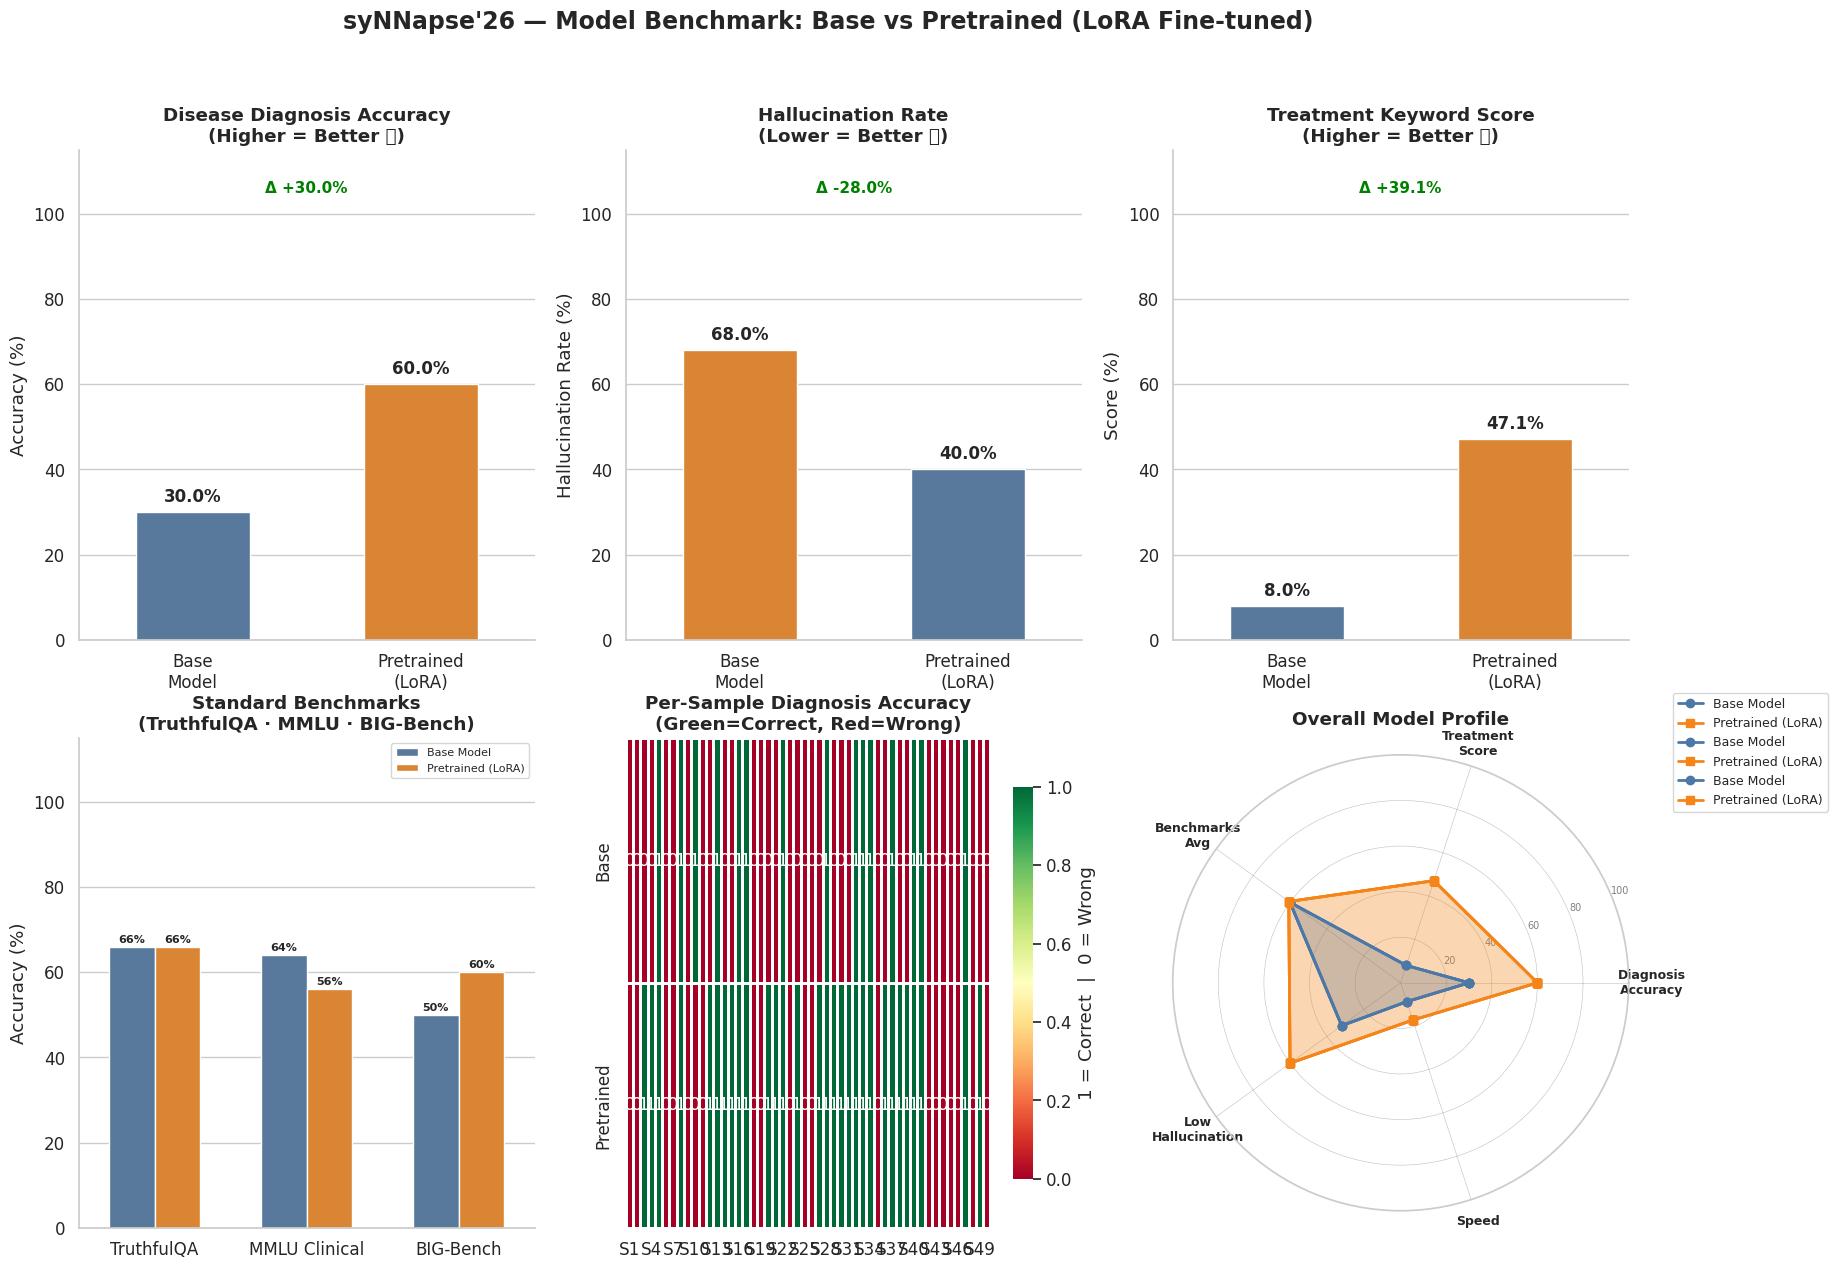

/tmp/ipykernel_2504/2712064747.py:20: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.savefig(plot_path, dpi=150, bbox_inches='tight',



✅ Plot saved: /content/drive/MyDrive/syNNapse26/plots/model_benchmark_full.png


<Figure size 640x480 with 0 Axes>

In [130]:
# Base model
ax6.plot(angles, base_vals, 'o-', linewidth=2.0, color=C_BASE, label='Base Model')
ax6.fill(angles, base_vals, alpha=0.12, color=C_BASE)

# Pretrained model
ax6.plot(angles, pt_vals, 's-', linewidth=2.0, color=C_PT, label='Pretrained (LoRA)')
ax6.fill(angles, pt_vals, alpha=0.12, color=C_PT)

ax6.set_title('Overall Model Profile', fontweight='bold', pad=22)
ax6.legend(loc='upper right', bbox_to_anchor=(1.45, 1.15), fontsize=9)

# ── Final layout ──────────────────────────────────────
plt.tight_layout(rect=[0, 0, 1, 0.96])

# ✅ Force render BEFORE saving
display(fig)

# Save after rendering
plot_path = f"{PATHS['PLOTS_DIR']}/model_benchmark_full.png"
fig.savefig(plot_path, dpi=150, bbox_inches='tight',
            facecolor='white', edgecolor='none')

plt.close(fig)  # optional but clean

print(f"\n✅ Plot saved: {plot_path}")

Final Summary Table + CSV Export

In [123]:
import json
import pandas as pd
from IPython.display import display, HTML


In [124]:
# ── Load all results from Drive ────────────────────────────────
with open('/content/drive/MyDrive/syNNapse26/paths_config.json') as f:
    PATHS = json.load(f)

with open(f"{PATHS['BASE_RES']}/summary.json") as f:
    base_summary = json.load(f)
with open(f"{PATHS['PT_RES']}/summary.json") as f:
    pretrained_summary = json.load(f)
with open(f"{PATHS['BASE_DIR']}/standard_benchmarks.json") as f:
    std_bm = json.load(f)

In [125]:
# ── Build final comparison table ──────────────────────────────
final_df = pd.DataFrame([
    {
        'System'                  : '🔵 Base Model (Mistral-7B)',
        'Diagnosis Accuracy (%)'  : base_summary['disease_accuracy_pct'],
        'Hallucination Rate (%)'  : base_summary['hallucination_rate_pct'],
        'Treatment Score (%)'     : base_summary['avg_keyword_score_pct'],
        'TruthfulQA (%)'          : std_bm['truthfulqa']['base_accuracy_pct'],
        'MMLU Clinical (%)'       : std_bm['mmlu_clinical']['base_accuracy_pct'],
        'BIG-Bench (%)'           : std_bm['bigbench_boolean']['base_accuracy_pct'],
        'Avg Latency (sec)'       : base_summary['avg_latency_sec'],
    },
    {
        'System'                  : '🟠 Pretrained Model (LoRA)',
        'Diagnosis Accuracy (%)'  : pretrained_summary['disease_accuracy_pct'],
        'Hallucination Rate (%)'  : pretrained_summary['hallucination_rate_pct'],
        'Treatment Score (%)'     : pretrained_summary['avg_keyword_score_pct'],
        'TruthfulQA (%)'          : std_bm['truthfulqa']['pretrained_accuracy_pct'],
        'MMLU Clinical (%)'       : std_bm['mmlu_clinical']['pretrained_accuracy_pct'],
        'BIG-Bench (%)'           : std_bm['bigbench_boolean']['pretrained_accuracy_pct'],
        'Avg Latency (sec)'       : pretrained_summary['avg_latency_sec'],
    }
])

In [126]:
# ── Styled display in Colab ────────────────────────────────────
# Green highlight = best value per column
styled = (
    final_df.style
    .set_caption("📊 Model Benchmark Results — syNNapse'26")
    .highlight_max(
        subset=['Diagnosis Accuracy (%)', 'Treatment Score (%)',
                'TruthfulQA (%)', 'MMLU Clinical (%)', 'BIG-Bench (%)'],
        color='#c6f4c2'
    )
    .highlight_min(
        subset=['Hallucination Rate (%)', 'Avg Latency (sec)'],
        color='#c6f4c2'
    )
    .set_properties(**{
        'text-align'    : 'center',
        'font-size'     : '13px',
        'border'        : '1px solid #ddd',
        'padding'       : '8px 12px'
    })
    .set_table_styles([{
        'selector': 'caption',
        'props'   : [('font-size', '15px'), ('font-weight', 'bold'),
                     ('padding', '10px'), ('text-align', 'left')]
    }, {
        'selector': 'th',
        'props'   : [('background-color', '#2c3e50'), ('color', 'white'),
                     ('font-weight', 'bold'), ('padding', '10px')]
    }])
    .format(precision=1)
)

display(styled)

# ── Print improvement delta row ────────────────────────────────
print("\n IMPROVEMENT: Pretrained vs Base")
print("-" * 55)
metrics_to_check = [
    ('Diagnosis Accuracy (%)',  'disease_accuracy_pct',   True,  'summary'),
    ('Hallucination Rate (%)',  'hallucination_rate_pct', False, 'summary'),
    ('Treatment Score (%)',     'avg_keyword_score_pct',  True,  'summary'),
    ('TruthfulQA (%)',          'truthfulqa',             True,  'benchmark'),
    ('MMLU Clinical (%)',       'mmlu_clinical',          True,  'benchmark'),
    ('BIG-Bench (%)',           'bigbench_boolean',       True,  'benchmark'),
]

for label, key, higher_better, src in metrics_to_check:
    if src == 'summary':
        base_v = base_summary[key]
        pt_v   = pretrained_summary[key]
    else:
        base_v = std_bm[key]['base_accuracy_pct']
        pt_v   = std_bm[key]['pretrained_accuracy_pct']

    delta = pt_v - base_v
    if higher_better:
        icon = '✅' if delta > 0 else ('➡️' if delta == 0 else '❌')
    else:
        icon = '✅' if delta < 0 else ('➡️' if delta == 0 else '❌')

    print(f"  {label:<28}: {'+' if delta >= 0 else ''}{delta:.1f}% {icon}")

,System,Diagnosis Accuracy (%),Hallucination Rate (%),Treatment Score (%),TruthfulQA (%),MMLU Clinical (%),BIG-Bench (%),Avg Latency (sec)
0,🔵 Base Model (Mistral-7B),30.0,68.0,8.0,66.0,64.0,50.0,11.5
1,🟠 Pretrained Model (LoRA),60.0,40.0,47.1,66.0,56.0,60.0,5.8



 IMPROVEMENT: Pretrained vs Base
-------------------------------------------------------
  Diagnosis Accuracy (%)      : +30.0% ✅
  Hallucination Rate (%)      : -28.0% ✅
  Treatment Score (%)         : +39.1% ✅
  TruthfulQA (%)              : +0.0% ➡️
  MMLU Clinical (%)           : -8.0% ❌
  BIG-Bench (%)               : +10.0% ✅


In [128]:
# ── Save CSV ───────────────────────────────────────────────────
csv_path = f"{PATHS['BASE_DIR']}/model_benchmark_final.csv"
final_df.to_csv(csv_path, index=False)
print(f"\n✅ Table saved as CSV: {csv_path}")

# ── Final status ───────────────────────────────────────────────

print("\n  MODEL BENCHMARK COMPLETE!")
print("\n  Files on your Drive:")
print(f"  📊 Plots  → {PATHS['PLOTS_DIR']}/model_benchmark_full.png")
print(f"  📄 Table  → {PATHS['BASE_DIR']}/model_benchmark_final.csv")
print(f"  📁 Data   → base_results/ and pretrained_results/")
print("\n  Next step → Agent Benchmark notebook")



✅ Table saved as CSV: /content/drive/MyDrive/syNNapse26/model_benchmark_final.csv

  MODEL BENCHMARK COMPLETE!

  Files on your Drive:
  📊 Plots  → /content/drive/MyDrive/syNNapse26/plots/model_benchmark_full.png
  📄 Table  → /content/drive/MyDrive/syNNapse26/model_benchmark_final.csv
  📁 Data   → base_results/ and pretrained_results/

  Next step → Agent Benchmark notebook


# Agent Benchmarking

## **Baseline: `Output -> LLM -> Output` **

WHY LANGCHAIN over LlamaIndex / Haystack:
LangChain chosen because:


*   Best MCP/tool integration
support
*   AgentExecutor handles tool-calling loop natively


*   Easiest to swap baseline vs neurosymbolic agent
*   Built-in conversation memory










Install Agent Dependencies

In [1]:
# Core agent framework — PS mentions LangChain explicitly
!pip install -q langchain langchain-community langchain-core

# LLM loading (reuse from model benchmark)
!pip install -q unsloth

# Graph/ontology reasoning
!pip install -q networkx           # Knowledge graph traversal
!pip install -q pyvis              # Graph visualisation (bonus)

# Evaluation
!pip install -q rouge-score seaborn matplotlib pandas

# Utilities
!pip install -q transformers accelerate bitsandbytes peft
!pip install -q sentencepiece protobuf


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 MB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 79.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━

In [2]:
print("=" * 50)
print("All agent dependencies installed")
print("=" * 50)

All agent dependencies installed


In [3]:
import torch
print(f"\n GPU : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")
used  = torch.cuda.memory_allocated()/1e9
total = torch.cuda.get_device_properties(0).total_memory/1e9
print(f" VRAM: {used:.1f}/{total:.1f} GB used")



 GPU : Tesla T4
 VRAM: 0.0/15.6 GB used


Mount Drive + Setup Agent Paths

In [4]:
from google.colab import drive
import os, json

drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
#  Base path (same as model benchmark)
BASE_DIR = '/content/drive/MyDrive/syNNapse26'

#  New agent-specific paths
AGENT_DIR      = f'{BASE_DIR}/agent_benchmark'
BASELINE_DIR   = f'{AGENT_DIR}/baseline_agent'
NEURO_DIR      = f'{AGENT_DIR}/neurosymbolic_agent'
AGENT_PLOTS    = f'{AGENT_DIR}/plots'

In [6]:
for folder in [AGENT_DIR, BASELINE_DIR, NEURO_DIR, AGENT_PLOTS]:
    os.makedirs(folder, exist_ok=True)


In [7]:
# Agent paths config

with open(f'{BASE_DIR}/paths_config.json') as f:
    MODEL_CONFIG = json.load(f)

In [8]:
AGENT_CONFIG = {
    **MODEL_CONFIG,
    'AGENT_DIR'    : AGENT_DIR,
    'BASELINE_DIR' : BASELINE_DIR,
    'NEURO_DIR'    : NEURO_DIR,
    'AGENT_PLOTS'  : AGENT_PLOTS,
}
with open(f'{AGENT_DIR}/agent_config.json', 'w') as f:
    json.dump(AGENT_CONFIG, f, indent=2)

print(" Agent folder structure:")
print(f"   {AGENT_DIR}/")
print(f"   ├── baseline_agent/      ← Baseline LLM results")
print(f"   ├── neurosymbolic_agent/ ← Neurosymbolic results")
print(f"   └── plots/               ← Visualisations")
print(f"\n Agent config saved to Drive")

 Agent folder structure:
   /content/drive/MyDrive/syNNapse26/agent_benchmark/
   ├── baseline_agent/      ← Baseline LLM results
   ├── neurosymbolic_agent/ ← Neurosymbolic results
   └── plots/               ← Visualisations

 Agent config saved to Drive


## Load Quantized Model + LangChain Wrapper

WHY custom LangChain wrapper:

LangChain needs an LLM object with .invoke() method.We wrap our Unsloth model so BOTH agents (baseline and neurosymbolic) use IDENTICAL model weights — fair comparison. Only the TOOLS differ between agents.

In [9]:
import torch, gc, json, time
from unsloth import FastLanguageModel
from langchain_core.language_models.llms import LLM
from langchain_core.callbacks.manager import CallbackManagerForLLMRun
from typing import Any, List, Optional

# Reload config
with open('/content/drive/MyDrive/syNNapse26/agent_benchmark/agent_config.json') as f:
    ACFG = json.load(f)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [10]:
#  GPU cleanup
gc.collect()
torch.cuda.empty_cache()
print(f" VRAM before load: {torch.cuda.memory_allocated()/1e9:.1f} GB")

 VRAM before load: 0.0 GB


In [11]:
USE_PRETRAINED = True
if USE_PRETRAINED:
    model_path = ACFG['LORA_DIR']   # Fine-tuned LoRA model
    label      = "Pretrained (LoRA)"
else:
    model_path = ACFG['MODEL_NAME']  # Base Mistral/Llama
    label      = "Base Model"

print(f"⏳ Loading {label} for agent benchmarking...")
agent_model, agent_tokenizer = FastLanguageModel.from_pretrained(
    model_name     = model_path,
    max_seq_length = ACFG['MAX_SEQ_LENGTH'],
    dtype          = None,
    load_in_4bit   = True,
)
FastLanguageModel.for_inference(agent_model)
print(f" {label} loaded")
print(f" VRAM after load: {torch.cuda.memory_allocated()/1e9:.1f} GB")


⏳ Loading Pretrained (LoRA) for agent benchmarking...
==((====))==  Unsloth 2026.4.4: Fast Mistral patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/4.14G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/157 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/587k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/446 [00:00<?, ?B/s]

Unsloth 2026.4.4 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


 Pretrained (LoRA) loaded
 VRAM after load: 4.4 GB


## LANGCHAIN CUSTOM LLM WRAPPER
LangChain requires an LLM class with _call() method.

This wrapper:

*   Takes any string prompt
*   Passes it through our Unsloth model

*   Returns the generated text
*   Tracks token usage for ContextBench-style metrics





In [12]:
class UnslothLangChainLLM(LLM):
    """
    Custom LangChain LLM wrapper for Unsloth quantized models.

    Enables our fine-tuned Mistral/Llama to work inside
    LangChain's AgentExecutor and tool-calling framework.
    """
    model_label    : str = label
    max_new_tokens : int = 300
    temperature    : float = 0.1

    # Track usage across calls (for benchmarking)
    total_input_tokens  : int = 0
    total_output_tokens : int = 0
    total_calls         : int = 0
    total_latency       : float = 0.0

    class Config:
        arbitrary_types_allowed = True

    @property
    def _llm_type(self) -> str:
        return "unsloth_quantized"

    def _call(
        self,
        prompt: str,
        stop: Optional[List[str]] = None,
        run_manager: Optional[CallbackManagerForLLMRun] = None,
        **kwargs: Any,
    ) -> str:
        # Tokenize
        inputs       = agent_tokenizer(prompt, return_tensors='pt').to('cuda')
        input_tokens = inputs['input_ids'].shape[1]

        # Generate
        start = time.time()
        with torch.no_grad():
            outputs = agent_model.generate(
                **inputs,
                max_new_tokens = self.max_new_tokens,
                temperature    = self.temperature,
                do_sample      = True,
                pad_token_id   = agent_tokenizer.eos_token_id,
                use_cache      = True,
            )
        latency = time.time() - start

        # Decode new tokens only
        n_in          = input_tokens
        output_tokens = outputs.shape[1] - n_in
        response      = agent_tokenizer.decode(
            outputs[0][n_in:], skip_special_tokens=True
        ).strip()

        # Track usage (for benchmarking metrics)
        self.total_input_tokens  += input_tokens
        self.total_output_tokens += output_tokens
        self.total_calls         += 1
        self.total_latency       += latency

        torch.cuda.empty_cache()

        # Handle stop sequences
        if stop:
            for s in stop:
                if s in response:
                    response = response[:response.index(s)]

        return response

    def get_usage_stats(self):
        if self.total_calls == 0:
            return {}
        return {
            'total_calls'        : self.total_calls,
            'total_input_tokens' : self.total_input_tokens,
            'total_output_tokens': self.total_output_tokens,
            'avg_latency_sec'    : round(self.total_latency / self.total_calls, 2),
            'avg_output_tokens'  : round(self.total_output_tokens / self.total_calls, 1),
        }

    def reset_stats(self):
        self.total_input_tokens  = 0
        self.total_output_tokens = 0
        self.total_calls         = 0
        self.total_latency       = 0.0


# ── Instantiate LLM for use in agents ─────────────────────────
llm = UnslothLangChainLLM()

# ── Quick test ─────────────────────────────────────────────────
print("\n Testing LangChain wrapper...")
test_response = llm._call(
    "[INST] You are a medical AI. What disease causes itchy skin at night? [/INST]"
)
print(f"  Test response: {test_response[:100]}...")
print("\n LangChain LLM wrapper ready")
print(f"  Model: {label}")


/tmp/ipykernel_1388/4100972529.py:1: PydanticDeprecatedSince20: Support for class-based `config` is deprecated, use ConfigDict instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  class UnslothLangChainLLM(LLM):



 Testing LangChain wrapper...


Both `max_new_tokens` (=300) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12

  Test response: Disease: Cholestasis

Reasoning: itchy skin at night are strong indicators of Cholestasis. Cholestas...

 LangChain LLM wrapper ready
  Model: Pretrained (LoRA)


## Build Neurosymbolic Knowledge Graph

Converts your ontology.json into a NetworkX Knowledge Graph for symbolic reasoning.

Graph structure:                                  
 Disease node ──has_symptom──► Symptom node (weight=prob)    

 Disease node ──has_treatment► Treatment node     

 Disease node ──has_risk──────► Risk Factor node

 Disease node ──has_rule──────► Logic Rule node              


 This enables:                          
1. Symptom → Disease lookup (forward reasoning)             
2. Multi-hop: Symptom → Disease → Treatment                 
3. Rule-based constraint checking                           
4. Confidence scoring via symptom probabilities

In [13]:
import json, networkx as nx, os
from collections import defaultdict

# ── Reload config ──────────────────────────────────────────────
with open('/content/drive/MyDrive/syNNapse26/agent_benchmark/agent_config.json') as f:
    ACFG = json.load(f)


In [14]:
from google.colab import files
uploaded = files.upload()
ONTOLOGY = json.loads(list(uploaded.values())[0].decode())

Saving ontology.json to ontology.json


In [15]:
# Build NetworkX Knowledge Graph
KG = nx.DiGraph()   # Directed graph: edges have direction + weight

def build_knowledge_graph(ontology):
    """
    Converts ontology dict → NetworkX DiGraph.

    Node types (stored in node attribute 'type'):
      'disease'   → disease name
      'symptom'   → symptom string
      'treatment' → treatment string
      'risk'      → risk factor
      'rule'      → logical rule string

    Edge types (stored in edge attribute 'relation'):
      'has_symptom'   → disease → symptom  (weight = probability)
      'has_treatment' → disease → treatment
      'has_risk'      → disease → risk factor
      'has_rule'      → disease → rule
    """
    G = nx.DiGraph()

    for disease, data in ontology.items():
        # Add disease node
        G.add_node(disease, type='disease', label=disease)

        # Add symptom edges with probability weights
        for symptom, prob in data.get('symptoms', {}).items():
            symptom_node = f"SYM::{symptom}"
            G.add_node(symptom_node, type='symptom', label=symptom)
            G.add_edge(disease, symptom_node,
                       relation='has_symptom', weight=prob)
            # Reverse edge for lookup: symptom → disease
            G.add_edge(symptom_node, disease,
                       relation='symptom_of', weight=prob)

        # Add treatment edges
        for treatment in data.get('treatment', []):
            if treatment and treatment.lower() != 'nan':
                treat_node = f"TRT::{treatment}"
                G.add_node(treat_node, type='treatment', label=treatment)
                G.add_edge(disease, treat_node, relation='has_treatment')

        # Add risk factor edges
        for risk, prob in data.get('risk_factors', {}).items():
            risk_node = f"RSK::{risk}"
            G.add_node(risk_node, type='risk', label=risk)
            G.add_edge(disease, risk_node,
                       relation='has_risk', weight=prob)

        # Add logical rule edges
        for rule in data.get('rules', []):
            if rule:
                rule_node = f"RUL::{disease}::{rule}"
                G.add_node(rule_node, type='rule', label=rule)
                G.add_edge(disease, rule_node, relation='has_rule')

    return G

In [16]:
KG = build_knowledge_graph(ONTOLOGY)

# ── Graph stats ────────────────────────────────────────────────
disease_nodes   = [n for n,d in KG.nodes(data=True) if d['type']=='disease']
symptom_nodes   = [n for n,d in KG.nodes(data=True) if d['type']=='symptom']
treatment_nodes = [n for n,d in KG.nodes(data=True) if d['type']=='treatment']
rule_nodes      = [n for n,d in KG.nodes(data=True) if d['type']=='rule']

print("=" * 50)
print("🕸️  Knowledge Graph built successfully")
print("=" * 50)
print(f"   Total nodes    : {KG.number_of_nodes()}")
print(f"   Total edges    : {KG.number_of_edges()}")
print(f"   Diseases       : {len(disease_nodes)}")
print(f"   Symptoms       : {len(symptom_nodes)}")
print(f"   Treatments     : {len(treatment_nodes)}")
print(f"   Logic rules    : {len(rule_nodes)}")

🕸️  Knowledge Graph built successfully
   Total nodes    : 3377
   Total edges    : 6417
   Diseases       : 395
   Symptoms       : 927
   Treatments     : 1354
   Logic rules    : 695


In [17]:
# Symbolic Reasoning Functions
#These are the TOOLS the neurosymbolic agent will call
def symptom_to_diseases(symptom_list, top_k=3):
    """
    Core symbolic lookup:
    Given list of symptoms → ranked list of candidate diseases.

    Algorithm:
    1. For each symptom, find all diseases it maps to
    2. Score each disease = sum of symptom probabilities
    3. Apply rule checking bonus
    4. Return top_k candidates
    """
    symptom_list_lower = [s.strip().lower() for s in symptom_list]
    disease_scores     = defaultdict(float)
    disease_matched    = defaultdict(list)

    for symptom in symptom_list_lower:
        # Look for this symptom (fuzzy: check if symptom is substring of node label)
        for node, data in KG.nodes(data=True):
            if data['type'] == 'symptom':
                node_label = data['label'].lower()
                if symptom in node_label or node_label in symptom:
                    # Get all diseases this symptom points to
                    for neighbor in KG.neighbors(node):
                        edge_data = KG.edges[node, neighbor]
                        if edge_data.get('relation') == 'symptom_of':
                            weight = edge_data.get('weight', 0.5)
                            disease_scores[neighbor]    += weight
                            disease_matched[neighbor].append(symptom)

    # Rule checking bonus: +0.5 if a logical rule is satisfied
    for disease in disease_scores:
        disease_data = ONTOLOGY.get(disease, {})
        for rule in disease_data.get('rules', []):
            rule_symptoms = [s.strip().lower() for s in rule.split(' AND ')]
            if all(any(rs in s for s in symptom_list_lower) for rs in rule_symptoms):
                disease_scores[disease] += 0.5  # Rule satisfaction bonus

    # Sort and return top_k
    ranked = sorted(disease_scores.items(), key=lambda x: x[1], reverse=True)
    results = []
    for disease, score in ranked[:top_k]:
        treatments = []
        for neighbor in KG.neighbors(disease):
            if KG.nodes[neighbor].get('type') == 'treatment':
                treatments.append(KG.nodes[neighbor]['label'])

        results.append({
            'disease'         : disease,
            'confidence_score': round(score, 3),
            'matched_symptoms': disease_matched[disease],
            'treatments'      : treatments[:3],  # Top 3 treatments
        })

    return results

In [18]:
def check_rules(disease, symptom_list):
    """
    Checks if a disease's logical rules are satisfied.
    Returns: 'RULE_SATISFIED', 'RULE_VIOLATED', or 'NO_RULES'
    """
    symptom_lower = [s.strip().lower() for s in symptom_list]
    disease_data  = ONTOLOGY.get(disease, {})
    rules         = disease_data.get('rules', [])

    if not rules:
        return 'NO_RULES'

    for rule in rules:
        rule_parts = [r.strip().lower() for r in rule.split(' AND ')]
        if all(any(rp in sym for sym in symptom_lower) for rp in rule_parts):
            return f'RULE_SATISFIED: {rule}'

    return 'RULE_VIOLATED: No rule pattern matched'

In [19]:
def get_disease_details(disease_name):
    """
    Fetches full details for a disease from ontology.
    Used by neurosymbolic agent to inject context into LLM prompt.
    """
    # Fuzzy match disease name
    for d in ONTOLOGY:
        if disease_name.lower() in d.lower() or d.lower() in disease_name.lower():
            data = ONTOLOGY[d]
            return {
                'disease'   : d,
                'symptoms'  : list(data.get('symptoms', {}).keys()),
                'treatments': [t for t in data.get('treatment', [])
                               if t and t.lower() != 'nan'],
                'rules'     : data.get('rules', []),
            }
    return None

In [20]:
# ── Save KG to Drive (as pickle) ───────────────────────────────
import pickle
with open(f"{ACFG['AGENT_DIR']}/knowledge_graph.pkl", 'wb') as f:
    pickle.dump(KG, f)

# Save ontology copy to Drive
with open(f"{ACFG['AGENT_DIR']}/ontology.json", 'w') as f:
    json.dump(ONTOLOGY, f, indent=2)

print(f"\n Knowledge Graph saved to Drive")
print(f"\n Quick test — symptoms: ['itchy skin', 'especially at night']")
test = symptom_to_diseases(['itchy skin', 'especially at night'])
for r in test:
    print(f"   → {r['disease']} (score: {r['confidence_score']}) | treatments: {r['treatments'][:2]}")


 Knowledge Graph saved to Drive

 Quick test — symptoms: ['itchy skin', 'especially at night']
   → Gestational Cholestasis (score: 0.99) | treatments: []
   → Hemorrhoids (score: 0.95) | treatments: ['Increasing fiber intake', 'staying hydrated']
   → Scabies (score: 0.92) | treatments: ['Prescription medications (topical or oral scabicides)', 'washing clothes and bedding in hot water']


## Build Diagnostic Task Dataset

 Agent benchmark needs harder tasks than model benchmark:   
1. Multi-hop: Symptoms → Disease → Treatment chain       
2. Rule reasoning: Does symptom combo satisfy logic rules?
 3. Differential diagnosis: Multiple diseases, pick best     
 4. Treatment planning: Given diagnosis, what to prescribe?  
                                    
 Each task has:                                              
 - query  : what the agent is asked                         
 - expected_disease : ground truth                          
 - expected_treatment_keywords : ground truth treatments    
  - task_type : category for analysis                        
 - reasoning_hops : how many hops needed (complexity)     

In [21]:
import json

with open('/content/drive/MyDrive/syNNapse26/agent_benchmark/agent_config.json') as f:
    ACFG = json.load(f)

In [22]:
AGENT_TASKS = [

    # ── TYPE 1: Single-hop diagnosis ──────────────────────────
    # Straightforward: 2-3 clear symptoms → 1 disease
    {
        "id"                          : 1,
        "task_type"                   : "single_hop_diagnosis",
        "reasoning_hops"              : 1,
        "query"                       : "Patient presents with intense itching, especially at night, and small blisters or bumps. What is the most likely diagnosis and recommended treatment?",
        "symptoms"                    : ["intense itching", "especially at night", "small blisters or bumps"],
        "expected_disease"            : "Scabies",
        "expected_treatment_keywords" : ["scabicides", "hot water", "vacuuming"],
        "rule_to_satisfy"             : "intense itching AND especially at night"
    },
    {
        "id"                          : 2,
        "task_type"                   : "single_hop_diagnosis",
        "reasoning_hops"              : 1,
        "query"                       : "Patient has blurred distance vision, eyestrain, and squinting. Diagnose and suggest treatment.",
        "symptoms"                    : ["blurred distance vision", "eyestrain", "squinting"],
        "expected_disease"            : "Myopia",
        "expected_treatment_keywords" : ["eyeglasses", "contact lenses", "LASIK"],
        "rule_to_satisfy"             : "blurred distance vision AND eyestrain"
    },
    {
        "id"                          : 3,
        "task_type"                   : "single_hop_diagnosis",
        "reasoning_hops"              : 1,
        "query"                       : "Symptoms: cough with phlegm or pus, chest pain, and fever. What condition should be considered?",
        "symptoms"                    : ["cough with phlegm or pus", "chest pain", "fever"],
        "expected_disease"            : "Abscess of the Lung",
        "expected_treatment_keywords" : ["antibiotics", "drainage", "surgical"],
        "rule_to_satisfy"             : "cough with phlegm or pus AND chest pain"
    },

    # ── TYPE 2: Multi-hop reasoning ───────────────────────────
    # Requires: symptom → disease → treatment chain
    {
        "id"                          : 4,
        "task_type"                   : "multi_hop_treatment",
        "reasoning_hops"              : 2,
        "query"                       : "Patient has headache, confusion, and dizziness. First identify the condition, then explain the complete treatment pathway including immediate steps and long-term management.",
        "symptoms"                    : ["headache", "confusion", "dizziness"],
        "expected_disease"            : "Subdural hemorrhage",
        "expected_treatment_keywords" : ["immediate medical attention", "CT", "MRI", "surgical"],
        "rule_to_satisfy"             : "headache AND confusion"
    },
    {
        "id"                          : 5,
        "task_type"                   : "multi_hop_treatment",
        "reasoning_hops"              : 2,
        "query"                       : "A patient presents with cloudy or hazy eyes, excessive tearing, and sensitivity to light since birth. What is the condition and what surgical options exist?",
        "symptoms"                    : ["cloudy or hazy eyes", "excessive tearing", "sensitivity to light"],
        "expected_disease"            : "Congenital Glaucoma",
        "expected_treatment_keywords" : ["surgery", "trabeculotomy", "intraocular pressure"],
        "rule_to_satisfy"             : "cloudy or hazy eyes AND excessive tearing"
    },

    # ── TYPE 3: Differential diagnosis ────────────────────────
    # Ambiguous symptoms — agent must reason through options
    {
        "id"                          : 6,
        "task_type"                   : "differential_diagnosis",
        "reasoning_hops"              : 2,
        "query"                       : "Patient has itchy skin particularly on the hands and feet during pregnancy. Differentiate between possible conditions and identify the most likely one.",
        "symptoms"                    : ["itchy skin", "particularly on the hands and feet"],
        "expected_disease"            : "Gestational Cholestasis",
        "expected_treatment_keywords" : [],
        "rule_to_satisfy"             : "itchy skin AND particularly on the hands and feet"
    },
    {
        "id"                          : 7,
        "task_type"                   : "differential_diagnosis",
        "reasoning_hops"              : 2,
        "query"                       : "Patient reports abdominal pain, bleeding, and organ dysfunction. Multiple conditions could cause this. What is the most critical diagnosis and what immediate actions are needed?",
        "symptoms"                    : ["abdominal pain", "bleeding", "organ dysfunction"],
        "expected_disease"            : "Injury to Internal Organ",
        "expected_treatment_keywords" : ["immediate medical attention", "diagnostic tests", "surgery"],
        "rule_to_satisfy"             : "abdominal pain AND bleeding"
    },

    # ── TYPE 4: Rule-based constraint checking ─────────────────
    # Tests whether agent can apply formal rules from ontology
    {
        "id"                          : 8,
        "task_type"                   : "rule_based_reasoning",
        "reasoning_hops"              : 2,
        "query"                       : "Patient has intense itching but NOT especially at night, and has no blisters. Based on clinical rules, can Scabies be confirmed or ruled out? Explain your reasoning.",
        "symptoms"                    : ["intense itching"],   # Rule NOT satisfied
        "expected_disease"            : "Scabies",
        "expected_treatment_keywords" : [],
        "rule_to_satisfy"             : None,   # Rule should be VIOLATED
        "expected_rule_outcome"       : "RULE_VIOLATED"
    },
    {
        "id"                          : 9,
        "task_type"                   : "rule_based_reasoning",
        "reasoning_hops"              : 2,
        "query"                       : "Patient has both headache AND confusion. Using clinical diagnostic rules, which serious condition must be immediately considered and why?",
        "symptoms"                    : ["headache", "confusion"],
        "expected_disease"            : "Subdural hemorrhage",
        "expected_treatment_keywords" : ["immediate medical attention", "CT", "MRI"],
        "rule_to_satisfy"             : "headache AND confusion",
        "expected_rule_outcome"       : "RULE_SATISFIED"
    },

    # ── TYPE 5: Complex multi-symptom ─────────────────────────
    # Many symptoms, requires prioritization
    {
        "id"                          : 10,
        "task_type"                   : "complex_multi_symptom",
        "reasoning_hops"              : 3,
        "query"                       : "Patient presents with: headache, confusion, nausea or vomiting, seizures, weakness or numbness, and dizziness. This is an emergency situation. Provide complete diagnosis with confidence assessment, rule validation, and immediate treatment protocol.",
        "symptoms"                    : ["headache", "confusion", "nausea or vomiting",
                                         "seizures", "weakness or numbness", "dizziness"],
        "expected_disease"            : "Subdural hemorrhage",
        "expected_treatment_keywords" : ["immediate medical attention", "CT", "MRI",
                                         "surgical", "monitoring"],
        "rule_to_satisfy"             : "headache AND confusion"
    },
    {
        "id"                          : 11,
        "task_type"                   : "complex_multi_symptom",
        "reasoning_hops"              : 3,
        "query"                       : "Patient has cough with phlegm, shortness of breath, chest pain, fever and fatigue. Is this a pulmonary emergency? Diagnose, check rules, and give evidence-based treatment.",
        "symptoms"                    : ["cough with phlegm or pus", "shortness of breath",
                                         "chest pain", "fever", "fatigue"],
        "expected_disease"            : "Abscess of the Lung",
        "expected_treatment_keywords" : ["antibiotics", "drainage", "surgical"],
        "rule_to_satisfy"             : "cough with phlegm or pus AND chest pain"
    },

    # ── TYPE 6: Treatment planning ─────────────────────────────
    # Given diagnosis, plan full treatment
    {
        "id"                          : 12,
        "task_type"                   : "treatment_planning",
        "reasoning_hops"              : 2,
        "query"                       : "Diagnosis confirmed: Scabies. Patient is 25 years old, living with family. Create a complete treatment plan including medication, home care, and family precautions.",
        "symptoms"                    : [],   # Diagnosis already given
        "expected_disease"            : "Scabies",
        "expected_treatment_keywords" : ["scabicides", "hot water", "vacuuming", "washing"],
        "rule_to_satisfy"             : None
    },
    {
        "id"                          : 13,
        "task_type"                   : "treatment_planning",
        "reasoning_hops"              : 2,
        "query"                       : "Patient has been diagnosed with Subdural hemorrhage. What is the emergency treatment protocol? Include monitoring requirements.",
        "symptoms"                    : [],
        "expected_disease"            : "Subdural hemorrhage",
        "expected_treatment_keywords" : ["immediate medical attention", "monitoring", "surgical"],
        "rule_to_satisfy"             : None
    },
]

In [23]:
# ── Save task dataset ──────────────────────────────────────────
task_path = f"{ACFG['AGENT_DIR']}/agent_tasks.json"
with open(task_path, 'w') as f:
    json.dump(AGENT_TASKS, f, indent=2)

# ── Print task summary ─────────────────────────────────────────
from collections import Counter
type_counts = Counter(t['task_type'] for t in AGENT_TASKS)

print("=" * 55)
print(" AGENT BENCHMARK TASK DATASET")
print("=" * 55)
print(f" Total tasks: {len(AGENT_TASKS)}")
print(f"\n   By task type:")
for t_type, count in type_counts.items():
    print(f"     {t_type:<35}: {count}")
print(f"\n   By reasoning hops:")
hop_counts = Counter(t['reasoning_hops'] for t in AGENT_TASKS)
for hops, count in sorted(hop_counts.items()):
    print(f"     {hops} hop(s): {count} tasks")
print(f"\n✅ Saved to Drive: {task_path}")


 AGENT BENCHMARK TASK DATASET
 Total tasks: 13

   By task type:
     single_hop_diagnosis               : 3
     multi_hop_treatment                : 2
     differential_diagnosis             : 2
     rule_based_reasoning               : 2
     complex_multi_symptom              : 2
     treatment_planning                 : 2

   By reasoning hops:
     1 hop(s): 3 tasks
     2 hop(s): 8 tasks
     3 hop(s): 2 tasks

✅ Saved to Drive: /content/drive/MyDrive/syNNapse26/agent_benchmark/agent_tasks.json


##  Baseline LLM-Only Agent                           

ARCHITECTURE:  

`Query → System Prompt → LLM → Response`   


 NO ontology. NO knowledge graph. NO symbolic reasoning.

 Pure LLM generation — represents standard chatbot approach.



   

> WHY this is the baseline:


   PS requires comparing "LLM-only vs ontology-assisted"    
     This IS the LLM-only agent.                                
     

 Metrics collected:                                          
 - Disease accuracy (got right disease?)                     
- Treatment accuracy (mentioned right treatments?)          
 - Hallucination rate (confident but wrong?)                 
 - Rule adherence (followed clinical logic?)                 
 - Reasoning depth (how detailed was reasoning?)             
 - Latency + token usage

In [24]:
import json, time, torch
from unsloth import FastLanguageModel

with open('/content/drive/MyDrive/syNNapse26/agent_benchmark/agent_config.json') as f:
    ACFG = json.load(f)
with open(f"{ACFG['AGENT_DIR']}/agent_tasks.json") as f:
    AGENT_TASKS = json.load(f)

MODEL_NAME = ACFG.get('MODEL_NAME', 'mistral')

In [25]:
# BASELINE AGENT PROMPT
BASELINE_SYSTEM_PROMPT = """You are an expert AI medical assistant with extensive clinical knowledge.
When given patient symptoms, you must:
1. Identify the most likely disease/condition
2. Explain your reasoning based on the symptoms
3. Provide evidence-based treatment recommendations
4. Note any urgent or emergency considerations

Format your response as:
Disease: [disease name]
Reasoning: [clinical reasoning]
Treatment: [treatment recommendations]
Urgency: [routine/urgent/emergency]"""


In [26]:
def build_baseline_prompt(query):
    """Builds full prompt for baseline (no ontology)"""
    if "mistral" in MODEL_NAME.lower():
        return f"[INST] {BASELINE_SYSTEM_PROMPT}\n\nPatient Query: {query} [/INST]"
    else:
        return (
            f"<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n"
            f"{BASELINE_SYSTEM_PROMPT}<|eot_id|>"
            f"<|start_header_id|>user<|end_header_id|>\n"
            f"Patient Query: {query}<|eot_id|>"
            f"<|start_header_id|>assistant<|end_header_id|>\n"
        )

In [27]:
def score_agent_response(response, task):
    """
    Scores agent response on 5 dimensions:

    1. disease_accuracy     (0/1): correct disease named?
    2. treatment_score      (0-1): fraction of treatment keywords present
    3. hallucinated         (0/1): confident but wrong disease?
    4. rule_adherence       (0/1): mentioned rule-relevant symptoms?
    5. reasoning_depth      (0-3): how detailed is the reasoning?
       0 = no reasoning, 1 = minimal, 2 = moderate, 3 = detailed
    """
    resp_lower = response.lower()

    # 1. Disease accuracy
    disease_correct = 1 if task['expected_disease'].lower() in resp_lower else 0

    # 2. Treatment keyword score
    keywords = task.get('expected_treatment_keywords', [])
    if len(keywords) == 0:
        treatment_score = 1.0 if disease_correct else 0.0
    else:
        hits = sum(1 for kw in keywords if kw.lower() in resp_lower)
        treatment_score = hits / len(keywords)

    # 3. Hallucination
    hallucinated = 0
    if disease_correct == 0 and len(response.strip()) > 20:
        uncertain = ["cannot determine", "insufficient", "unclear", "multiple",
                     "consult", "could be", "possible", "differential"]
        if not any(u in resp_lower for u in uncertain):
            hallucinated = 1

    # 4. Rule adherence
    rule = task.get('rule_to_satisfy', '')
    rule_adherence = 0
    if rule:
        rule_parts = [p.strip().lower() for p in rule.split(' AND ')]
        if all(p in resp_lower for p in rule_parts):
            rule_adherence = 1
    else:
        rule_adherence = 1  # No rule to check = passes

    # 5. Reasoning depth (count reasoning indicators)
    depth_indicators = ['because', 'therefore', 'indicates', 'suggests',
                        'reasoning', 'evidence', 'based on', 'consistent with',
                        'symptom', 'diagnosis', 'clinical']
    depth_count = sum(1 for d in depth_indicators if d in resp_lower)
    reasoning_depth = min(3, depth_count // 2)

    return {
        'disease_accuracy' : disease_correct,
        'treatment_score'  : round(treatment_score, 3),
        'hallucinated'     : hallucinated,
        'rule_adherence'   : rule_adherence,
        'reasoning_depth'  : reasoning_depth,
    }

In [28]:
def run_baseline_agent(tasks, model, tokenizer):
    """
    Runs baseline LLM-only agent on all tasks.
    No tools, no ontology — pure LLM generation.
    """
    results = []
    print(f"\n{'='*58}")
    print(f" BASELINE AGENT (LLM-Only) — {len(tasks)} tasks")
    print(f"{'='*58}")

    FastLanguageModel.for_inference(model)
    total_tokens = 0

    for i, task in enumerate(tasks):
        print(f"\n[{i+1}/{len(tasks)}] Task {task['id']} | "
              f"Type: {task['task_type']} | Hops: {task['reasoning_hops']}")
        print(f"   Query: {task['query'][:70]}...")

        prompt = build_baseline_prompt(task['query'])
        inputs = tokenizer(prompt, return_tensors='pt').to('cuda')
        n_in   = inputs['input_ids'].shape[1]

        start = time.time()
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens = 350,
                temperature    = 0.1,
                do_sample      = True,
                pad_token_id   = tokenizer.eos_token_id,
                use_cache      = True,
            )
        latency = time.time() - start

        n_out    = outputs.shape[1] - n_in
        response = tokenizer.decode(outputs[0][n_in:], skip_special_tokens=True).strip()
        total_tokens += n_out
        torch.cuda.empty_cache()

        scores = score_agent_response(response, task)

        result = {
            'task_id'       : task['id'],
            'task_type'     : task['task_type'],
            'reasoning_hops': task['reasoning_hops'],
            'query'         : task['query'],
            'response'      : response,
            'expected_disease': task['expected_disease'],
            'latency_sec'   : round(latency, 2),
            'input_tokens'  : n_in,
            'output_tokens' : n_out,
            **scores
        }
        results.append(result)

        d = '✅' if scores['disease_accuracy'] else '❌'
        h = '⚠️ ' if scores['hallucinated']     else '✅'
        print(f"   Disease: {d}  Hallucinated: {h}  "
              f"Treatment: {scores['treatment_score']:.0%}  "
              f"Rule: {'✅' if scores['rule_adherence'] else '❌'}  "
              f"Depth: {scores['reasoning_depth']}/3  "
              f"Latency: {latency:.1f}s")

    # ── Aggregate summary ──────────────────────────────────────
    n = len(results)
    baseline_summary = {
        'agent_type'            : 'baseline_llm_only',
        'total_tasks'           : n,
        'disease_accuracy_pct'  : round(sum(r['disease_accuracy']   for r in results)/n*100, 1),
        'avg_treatment_score_pct': round(sum(r['treatment_score']   for r in results)/n*100, 1),
        'hallucination_rate_pct': round(sum(r['hallucinated']       for r in results)/n*100, 1),
        'rule_adherence_pct'    : round(sum(r['rule_adherence']     for r in results)/n*100, 1),
        'avg_reasoning_depth'   : round(sum(r['reasoning_depth']    for r in results)/n,    2),
        'avg_latency_sec'       : round(sum(r['latency_sec']        for r in results)/n,    2),
        'avg_output_tokens'     : round(sum(r['output_tokens']      for r in results)/n,    1),
        'total_output_tokens'   : sum(r['output_tokens']            for r in results),
    }

    # ── Per task-type breakdown ─────────────────────────────────
    task_types = list(set(r['task_type'] for r in results))
    type_breakdown = {}
    for tt in task_types:
        tt_res = [r for r in results if r['task_type'] == tt]
        if tt_res:
            type_breakdown[tt] = {
                'count'               : len(tt_res),
                'disease_accuracy_pct': round(sum(r['disease_accuracy'] for r in tt_res)/len(tt_res)*100,1),
                'hallucination_pct'   : round(sum(r['hallucinated']     for r in tt_res)/len(tt_res)*100,1),
            }
    baseline_summary['task_type_breakdown'] = type_breakdown

    # ── Save ───────────────────────────────────────────────────
    with open(f"{ACFG['BASELINE_DIR']}/detailed_results.json", 'w') as f:
        json.dump(results, f, indent=2)
    with open(f"{ACFG['BASELINE_DIR']}/summary.json", 'w') as f:
        json.dump(baseline_summary, f, indent=2)

    # ── Print summary ──────────────────────────────────────────
    print(f"\n{'='*58}")
    print(" BASELINE AGENT SUMMARY")
    print(f"{'='*58}")
    print(f"  Disease Accuracy    : {baseline_summary['disease_accuracy_pct']}%")
    print(f"  Treatment Score     : {baseline_summary['avg_treatment_score_pct']}%")
    print(f"  Hallucination Rate  : {baseline_summary['hallucination_rate_pct']}%  ← lower better")
    print(f"  Rule Adherence      : {baseline_summary['rule_adherence_pct']}%")
    print(f"  Avg Reasoning Depth : {baseline_summary['avg_reasoning_depth']}/3")
    print(f"  Avg Latency         : {baseline_summary['avg_latency_sec']} sec")
    print(f"  Avg Output Tokens   : {baseline_summary['avg_output_tokens']}")
    print(f"{'='*58}")
    print(f"✅ Saved to Drive: {ACFG['BASELINE_DIR']}")

    return results, baseline_summary

In [30]:
# ── RUN BASELINE ───────────────────────────────────────────────
baseline_results, baseline_summary = run_baseline_agent(
    AGENT_TASKS, agent_model, agent_tokenizer
)

Both `max_new_tokens` (=350) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



 BASELINE AGENT (LLM-Only) — 13 tasks

[1/13] Task 1 | Type: single_hop_diagnosis | Hops: 1
   Query: Patient presents with intense itching, especially at night, and small ...


Both `max_new_tokens` (=350) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


   Disease: ✅  Hallucinated: ✅  Treatment: 33%  Rule: ✅  Depth: 0/3  Latency: 5.8s

[2/13] Task 2 | Type: single_hop_diagnosis | Hops: 1
   Query: Patient has blurred distance vision, eyestrain, and squinting. Diagnos...


Both `max_new_tokens` (=350) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

   Disease: ❌  Hallucinated: ⚠️   Treatment: 80%  Rule: ✅  Depth: 0/3  Latency: 21.2s

[11/13] Task 11 | Type: complex_multi_symptom | Hops: 3
   Query: Patient has cough with phlegm, shortness of breath, chest pain, fever ...


Both `max_new_tokens` (=350) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


   Disease: ❌  Hallucinated: ⚠️   Treatment: 33%  Rule: ❌  Depth: 1/3  Latency: 5.5s

[12/13] Task 12 | Type: treatment_planning | Hops: 2
   Query: Diagnosis confirmed: Scabies. Patient is 25 years old, living with fam...


Both `max_new_tokens` (=350) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


   Disease: ✅  Hallucinated: ✅  Treatment: 50%  Rule: ✅  Depth: 1/3  Latency: 10.9s

[13/13] Task 13 | Type: treatment_planning | Hops: 2
   Query: Patient has been diagnosed with Subdural hemorrhage. What is the emerg...
   Disease: ✅  Hallucinated: ✅  Treatment: 67%  Rule: ✅  Depth: 0/3  Latency: 8.3s

 BASELINE AGENT SUMMARY
  Disease Accuracy    : 38.5%
  Treatment Score     : 61.9%
  Hallucination Rate  : 53.8%  ← lower better
  Rule Adherence      : 92.3%
  Avg Reasoning Depth : 0.31/3
  Avg Latency         : 7.62 sec
  Avg Output Tokens   : 98.2
✅ Saved to Drive: /content/drive/MyDrive/syNNapse26/agent_benchmark/baseline_agent


## Neurosymbolic Agent (Ontology + LLM)

ARCHITECTURE:   

 Query  
    ▼     
    
[Symbolic  Pre-Filter]                                       
→ Extract symptoms from query                      
→ KG lookup: symptoms → candidate diseases               
 → Rule checker: validate clinical logic rules            
    ▼  
      [Symbolic Scaffold Builder]                   
      
   → Build context string from KG results          
   → Include: diseases, confidence scores, treatments, rules   
    ▼                                             
  [LLM Reasoning Core]      
   → Prompt = original query + symbolic scaffold      
   → LLM reasons OVER the grounded knowledge  
   ▼                                                
    Verified, grounded output


 KEY DIFFERENCE from baseline:                               ║
  LLM never invents diseases/treatments — they come from KG

In [31]:
import json, time, torch, re
from unsloth import FastLanguageModel

with open('/content/drive/MyDrive/syNNapse26/agent_benchmark/agent_config.json') as f:
    ACFG = json.load(f)
with open(f"{ACFG['AGENT_DIR']}/agent_tasks.json") as f:
    AGENT_TASKS = json.load(f)
with open(f"{ACFG['AGENT_DIR']}/ontology.json") as f:
    ONTOLOGY = json.load(f)

MODEL_NAME = ACFG.get('MODEL_NAME', 'mistral')

In [32]:
#  SYMBOLIC TOOL 1: Extract symptoms from query text

def extract_symptoms_from_query(query, known_symptoms):
    """
    Extracts symptom mentions from free-text query.
    Uses fuzzy substring matching against ontology symptoms.

    Returns: list of matched symptom strings
    """
    query_lower = query.lower()
    found       = []

    for symptom in known_symptoms:
        # Check if symptom (or key words from it) appear in query
        symptom_lower = symptom.lower()
        symptom_words = [w for w in symptom_lower.split() if len(w) > 3]

        if symptom_lower in query_lower:
            found.append(symptom)
        elif len(symptom_words) >= 2:
            if sum(1 for w in symptom_words if w in query_lower) >= len(symptom_words) - 1:
                found.append(symptom)

    return list(set(found))


In [33]:
#  SYMBOLIC TOOL 2: Build knowledge scaffold from KG results
def build_symbolic_scaffold(symptoms, task_symptoms=None):
    """
    Queries the Knowledge Graph and builds a structured
    context string to inject into the LLM prompt.

    This is the KEY neurosymbolic innovation:
    Rather than raw triples, we render KG knowledge as
    natural language that the LLM can reason over.
    """
    # Use task symptoms if provided (more accurate than NLP extraction)
    if task_symptoms and len(task_symptoms) > 0:
        query_symptoms = task_symptoms
    else:
        query_symptoms = symptoms

    if not query_symptoms:
        return "No symptoms identified for symbolic lookup.", []

    # KG lookup
    candidates = symptom_to_diseases(query_symptoms, top_k=3)

    if not candidates:
        return "No matching conditions found in knowledge graph.", []

    # Build scaffold
    scaffold_lines = [
        "=== SYMBOLIC KNOWLEDGE (from Medical Ontology) ===",
        f"Symptoms identified: {', '.join(query_symptoms)}",
        ""
    ]

    for rank, candidate in enumerate(candidates, 1):
        disease    = candidate['disease']
        score      = candidate['confidence_score']
        treatments = candidate['treatments']
        matched    = candidate['matched_symptoms']

        scaffold_lines.append(
            f"Candidate {rank}: {disease} (confidence: {score:.2f})"
        )
        scaffold_lines.append(
            f"  Matched symptoms: {', '.join(matched)}"
        )

        # Rule check
        rule_result = check_rules(disease, query_symptoms)
        scaffold_lines.append(f"  Rule validation: {rule_result}")

        # Treatments
        if treatments:
            scaffold_lines.append(
                f"  Evidence-based treatments: {'; '.join(treatments)}"
            )
        else:
            scaffold_lines.append("  Treatments: Refer to specialist")

        scaffold_lines.append("")

    scaffold_lines.append("=== END SYMBOLIC KNOWLEDGE ===")
    scaffold = "\n".join(scaffold_lines)

    return scaffold, candidates

In [34]:
#  NEUROSYMBOLIC AGENT PROMPT BUILDER
NS_SYSTEM_PROMPT = """You are an expert AI medical assistant using neurosymbolic reasoning.
You will receive:
1. A patient query
2. SYMBOLIC KNOWLEDGE retrieved from a verified medical ontology

Your task:
- Use the symbolic knowledge as your primary evidence base
- Apply the rule validations provided
- Reason carefully over the candidate diagnoses
- Select the most likely diagnosis based on confidence scores AND rule satisfaction
- Provide complete treatment recommendations from the ontology

IMPORTANT: Prioritize ontology-verified information over general knowledge.
Format:
Disease: [disease name]
Confidence: [high/medium/low based on symbolic score]
Rule Status: [rule satisfied/violated/not applicable]
Reasoning: [your clinical reasoning using the symbolic knowledge]
Treatment: [treatments from the ontology]
Urgency: [routine/urgent/emergency]"""


In [35]:
def build_neurosymbolic_prompt(query, scaffold):
    """Builds prompt with ontology scaffold injected"""
    full_context = f"{scaffold}\n\nPatient Query: {query}"
    if "mistral" in MODEL_NAME.lower():
        return f"[INST] {NS_SYSTEM_PROMPT}\n\n{full_context} [/INST]"
    else:
        return (
            f"<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n"
            f"{NS_SYSTEM_PROMPT}<|eot_id|>"
            f"<|start_header_id|>user<|end_header_id|>\n"
            f"{full_context}<|eot_id|>"
            f"<|start_header_id|>assistant<|end_header_id|>\n"
        )

In [36]:
#  ADDITIONAL METRIC: Ontology Grounding Score
#  Measures how much the response uses ontology knowledge
def compute_grounding_score(response, candidates):
    """
    Measures how well the response is grounded in ontology.

    Checks if response mentions:
    - Disease names from candidates (not hallucinated names)
    - Treatments from ontology (not invented)
    - Rule-based terminology

    Returns 0.0-1.0
    """
    if not candidates:
        return 0.0

    resp_lower  = response.lower()
    score       = 0.0
    checks      = 0

    for candidate in candidates:
        # Disease mentioned?
        checks += 1
        if candidate['disease'].lower() in resp_lower:
            score += 1

        # Treatment mentioned?
        for treatment in candidate.get('treatments', []):
            if treatment and treatment.lower() != 'nan':
                checks += 1
                if any(word in resp_lower for word in treatment.lower().split()
                       if len(word) > 4):
                    score += 0.5

    return round(min(1.0, score / max(checks, 1)), 3)

In [37]:
#  ALL ONTOLOGY SYMPTOMS (for extraction)
ALL_SYMPTOMS = []
for disease_data in ONTOLOGY.values():
    ALL_SYMPTOMS.extend(disease_data.get('symptoms', {}).keys())
ALL_SYMPTOMS = list(set(ALL_SYMPTOMS))


In [38]:
def run_neurosymbolic_agent(tasks, model, tokenizer):
    """
    Runs neurosymbolic agent on all tasks.
    Steps per task:
    1. Extract symptoms from query
    2. KG lookup → candidate diseases + rules
    3. Build symbolic scaffold
    4. Inject scaffold into LLM prompt
    5. Generate grounded response
    6. Score on all metrics + grounding score
    """
    results = []
    print(f"\n{'='*58}")
    print(f" NEUROSYMBOLIC AGENT — {len(tasks)} tasks")
    print(f"{'='*58}")

    FastLanguageModel.for_inference(model)

    for i, task in enumerate(tasks):
        print(f"\n[{i+1}/{len(tasks)}] Task {task['id']} | "
              f"Type: {task['task_type']} | Hops: {task['reasoning_hops']}")

        # ── Step 1: Symbolic pre-processing ───────────────────
        # Use task symptoms directly if available (clean ground truth)
        # Otherwise extract from query text
        if task.get('symptoms') and len(task['symptoms']) > 0:
            extracted_symptoms = task['symptoms']
        else:
            extracted_symptoms = extract_symptoms_from_query(
                task['query'], ALL_SYMPTOMS
            )

        print(f"   Symptoms identified: {extracted_symptoms[:3]}...")

        # ── Step 2: Build scaffold from KG ────────────────────
        scaffold, candidates = build_symbolic_scaffold(
            extracted_symptoms, task_symptoms=extracted_symptoms
        )
        print(f"   KG candidates: {[c['disease'] for c in candidates]}")

        # ── Step 3: Build neurosymbolic prompt ─────────────────
        prompt = build_neurosymbolic_prompt(task['query'], scaffold)
        inputs = tokenizer(prompt, return_tensors='pt').to('cuda')
        n_in   = inputs['input_ids'].shape[1]

        # ── Step 4: Generate grounded response ────────────────
        start = time.time()
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens = 400,   # Slightly more — scaffold adds context
                temperature    = 0.1,
                do_sample      = True,
                pad_token_id   = tokenizer.eos_token_id,
                use_cache      = True,
            )
        latency = time.time() - start

        n_out    = outputs.shape[1] - n_in
        response = tokenizer.decode(outputs[0][n_in:], skip_special_tokens=True).strip()
        torch.cuda.empty_cache()

        # ── Step 5: Score ──────────────────────────────────────
        scores          = score_agent_response(response, task)   # From Cell A6
        grounding_score = compute_grounding_score(response, candidates)
        scaffold_tokens = len(tokenizer(scaffold)['input_ids'])

        result = {
            'task_id'          : task['id'],
            'task_type'        : task['task_type'],
            'reasoning_hops'   : task['reasoning_hops'],
            'query'            : task['query'],
            'scaffold'         : scaffold,
            'response'         : response,
            'expected_disease' : task['expected_disease'],
            'kg_candidates'    : [c['disease'] for c in candidates],
            'kg_top_score'     : candidates[0]['confidence_score'] if candidates else 0,
            'latency_sec'      : round(latency, 2),
            'input_tokens'     : n_in,
            'output_tokens'    : n_out,
            'scaffold_tokens'  : scaffold_tokens,
            'grounding_score'  : grounding_score,
            **scores
        }
        results.append(result)

        d = '✅' if scores['disease_accuracy'] else '❌'
        h = '⚠️ ' if scores['hallucinated']     else '✅'
        print(f"   Disease: {d}  Hallucinated: {h}  "
              f"Treatment: {scores['treatment_score']:.0%}  "
              f"Rule: {'✅' if scores['rule_adherence'] else '❌'}  "
              f"Grounding: {grounding_score:.2f}  "
              f"Depth: {scores['reasoning_depth']}/3  "
              f"Latency: {latency:.1f}s")

    # ── Summary ────────────────────────────────────────────────
    n = len(results)
    neuro_summary = {
        'agent_type'              : 'neurosymbolic',
        'total_tasks'             : n,
        'disease_accuracy_pct'    : round(sum(r['disease_accuracy']   for r in results)/n*100,1),
        'avg_treatment_score_pct' : round(sum(r['treatment_score']    for r in results)/n*100,1),
        'hallucination_rate_pct'  : round(sum(r['hallucinated']       for r in results)/n*100,1),
        'rule_adherence_pct'      : round(sum(r['rule_adherence']     for r in results)/n*100,1),
        'avg_reasoning_depth'     : round(sum(r['reasoning_depth']    for r in results)/n,   2),
        'avg_grounding_score'     : round(sum(r['grounding_score']    for r in results)/n,   3),
        'avg_latency_sec'         : round(sum(r['latency_sec']        for r in results)/n,   2),
        'avg_output_tokens'       : round(sum(r['output_tokens']      for r in results)/n,   1),
        'total_output_tokens'     : sum(r['output_tokens']            for r in results),
        'avg_scaffold_tokens'     : round(sum(r['scaffold_tokens']    for r in results)/n,   1),
    }

    # Per task-type breakdown
    task_types = list(set(r['task_type'] for r in results))
    type_breakdown = {}
    for tt in task_types:
        tt_res = [r for r in results if r['task_type'] == tt]
        if tt_res:
            type_breakdown[tt] = {
                'count'               : len(tt_res),
                'disease_accuracy_pct': round(sum(r['disease_accuracy'] for r in tt_res)/len(tt_res)*100,1),
                'hallucination_pct'   : round(sum(r['hallucinated']     for r in tt_res)/len(tt_res)*100,1),
                'avg_grounding'       : round(sum(r['grounding_score']  for r in tt_res)/len(tt_res),3),
            }
    neuro_summary['task_type_breakdown'] = type_breakdown

    # Save
    with open(f"{ACFG['NEURO_DIR']}/detailed_results.json", 'w') as f:
        json.dump(results, f, indent=2)
    with open(f"{ACFG['NEURO_DIR']}/summary.json", 'w') as f:
        json.dump(neuro_summary, f, indent=2)

    print(f"\n{'='*58}")
    print("📊 NEUROSYMBOLIC AGENT SUMMARY")
    print(f"{'='*58}")
    print(f"  Disease Accuracy    : {neuro_summary['disease_accuracy_pct']}%")
    print(f"  Treatment Score     : {neuro_summary['avg_treatment_score_pct']}%")
    print(f"  Hallucination Rate  : {neuro_summary['hallucination_rate_pct']}%  ← lower better")
    print(f"  Rule Adherence      : {neuro_summary['rule_adherence_pct']}%")
    print(f"  Grounding Score     : {neuro_summary['avg_grounding_score']:.3f}  ← NEW metric")
    print(f"  Avg Reasoning Depth : {neuro_summary['avg_reasoning_depth']}/3")
    print(f"  Avg Scaffold Tokens : {neuro_summary['avg_scaffold_tokens']}")
    print(f"  Avg Total Tokens    : {neuro_summary['avg_output_tokens']}")
    print(f"  Avg Latency         : {neuro_summary['avg_latency_sec']} sec")
    print(f"{'='*58}")
    print(f"✅ Saved to Drive: {ACFG['NEURO_DIR']}")

    return results, neuro_summary

In [39]:
# ── RUN NEUROSYMBOLIC AGENT ────────────────────────────────────
neuro_results, neuro_summary = run_neurosymbolic_agent(
    AGENT_TASKS, agent_model, agent_tokenizer
)

Both `max_new_tokens` (=400) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Unsloth: Input IDs of shape torch.Size([1, 558]) with length 558 > the model's max sequence length of 512.
We shall truncate it ourselves. It's imperative if you correct this issue first.



 NEUROSYMBOLIC AGENT — 13 tasks

[1/13] Task 1 | Type: single_hop_diagnosis | Hops: 1
   Symptoms identified: ['intense itching', 'especially at night', 'small blisters or bumps']...
   KG candidates: ['Scabies', 'Polycythemia Vera', 'Parasitic Infections']


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=400) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Unsloth: Input IDs of sha

   Disease: ✅  Hallucinated: ✅  Treatment: 100%  Rule: ✅  Grounding: 0.36  Depth: 0/3  Latency: 6.3s

[2/13] Task 2 | Type: single_hop_diagnosis | Hops: 1
   Symptoms identified: ['blurred distance vision', 'eyestrain', 'squinting']...
   KG candidates: ['Myopia', 'Seborrheic Dermatitis', 'Intertrigo']


Both `max_new_tokens` (=400) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Unsloth: Input IDs of shape torch.Size([1, 559]) with length 559 > the model's max sequence length of 512.
We shall truncate it ourselves. It's imperative if you correct this issue first.


...

   Disease: ✅  Hallucinated: ✅  Treatment: 80%  Rule: ✅  Grounding: 0.33  Depth: 0/3  Latency: 7.8s

[11/13] Task 11 | Type: complex_multi_symptom | Hops: 3
   Symptoms identified: ['cough with phlegm or pus', 'shortness of breath', 'chest pain']...
   KG candidates: ['Abscess of the Lung', 'Pulmonary Eosinophilia', 'Pneumonia']


Both `max_new_tokens` (=400) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Unsloth: Input IDs of shape torch.Size([1, 551]) with length 551 > the model's max sequence length of 512.
We shall truncate it ourselves. It's imperative if you correct this issue first.


   Disease: ❌  Hallucinated: ⚠️   Treatment: 33%  Rule: ❌  Grounding: 0.21  Depth: 0/3  Latency: 4.4s

[12/13] Task 12 | Type: treatment_planning | Hops: 2
   Symptoms identified: ['including rash']...
   KG candidates: ['Dengue Fever', 'Dermatitis due to Sun Exposure', 'Vasculitis']


Both `max_new_tokens` (=400) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


   Disease: ❌  Hallucinated: ⚠️   Treatment: 0%  Rule: ✅  Grounding: 0.25  Depth: 0/3  Latency: 3.7s

[13/13] Task 13 | Type: treatment_planning | Hops: 2
   Symptoms identified: ['runny nose']...
   KG candidates: ['Nose Disorder', 'Common Cold']
   Disease: ✅  Hallucinated: ✅  Treatment: 67%  Rule: ✅  Grounding: 0.12  Depth: 0/3  Latency: 7.9s

📊 NEUROSYMBOLIC AGENT SUMMARY
  Disease Accuracy    : 53.8%
  Treatment Score     : 50.4%
  Hallucination Rate  : 46.2%  ← lower better
  Rule Adherence      : 76.9%
  Grounding Score     : 0.259  ← NEW metric
  Avg Reasoning Depth : 0.15/3
  Avg Scaffold Tokens : 303.5
  Avg Total Tokens    : 80.8
  Avg Latency         : 6.22 sec
✅ Saved to Drive: /content/drive/MyDrive/syNNapse26/agent_benchmark/neurosymbolic_agent


## Agent Benchmark Visualisations (Seaborn)

 8 plots covering all PS-required metrics:                   
1.  Overall comparison bar chart (5 key metrics)            
 2.  Hallucination rate comparison                           
3.  Per task-type accuracy heatmap                          
4.  Reasoning hops vs accuracy scatter                      
5.  Grounding score distribution (neurosymbolic only)       
 6.  Token usage comparison                                  
7.  Radar chart (full agent profile)                        
 8.  Task-type breakdown grouped bar

In [40]:
import json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from IPython.display import display

# ── Load results ───────────────────────────────────────────────
with open('/content/drive/MyDrive/syNNapse26/agent_benchmark/agent_config.json') as f:
    ACFG = json.load(f)

with open(f"{ACFG['BASELINE_DIR']}/summary.json") as f:
    B = json.load(f)   # Baseline summary
with open(f"{ACFG['NEURO_DIR']}/summary.json") as f:
    N = json.load(f)   # Neurosymbolic summary
with open(f"{ACFG['BASELINE_DIR']}/detailed_results.json") as f:
    B_det = json.load(f)
with open(f"{ACFG['NEURO_DIR']}/detailed_results.json") as f:
    N_det = json.load(f)

print("✅ Agent results loaded")

✅ Agent results loaded


In [41]:
# ── Styling ────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

C_BASE  = '#4C78A8'   # Blue  = Baseline
C_NEURO = '#54A24B'   # Green = Neurosymbolic
COLORS  = [C_BASE, C_NEURO]
LABELS  = ['Baseline\n(LLM-Only)', 'Neurosymbolic\n(LLM+Ontology)']

def add_labels(ax, fmt="{:.1f}%", offset=1.5, size=11):
    for p in ax.patches:
        h = p.get_height()
        if h > 0:
            ax.annotate(fmt.format(h),
                        (p.get_x() + p.get_width()/2, h + offset),
                        ha='center', va='bottom', fontweight='bold', fontsize=size)


/tmp/ipykernel_1388/102640004.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Agent', y='Accuracy', palette=COLORS, ax=ax, width=0.5)
/tmp/ipykernel_1388/102640004.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Agent', y='Hallucination',
/tmp/ipykernel_1388/102640004.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Agent', y='Rule Adherence', palette=COLORS, ax=ax, width=0.5)
/tmp/ipykernel_1388/102640004.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and wil

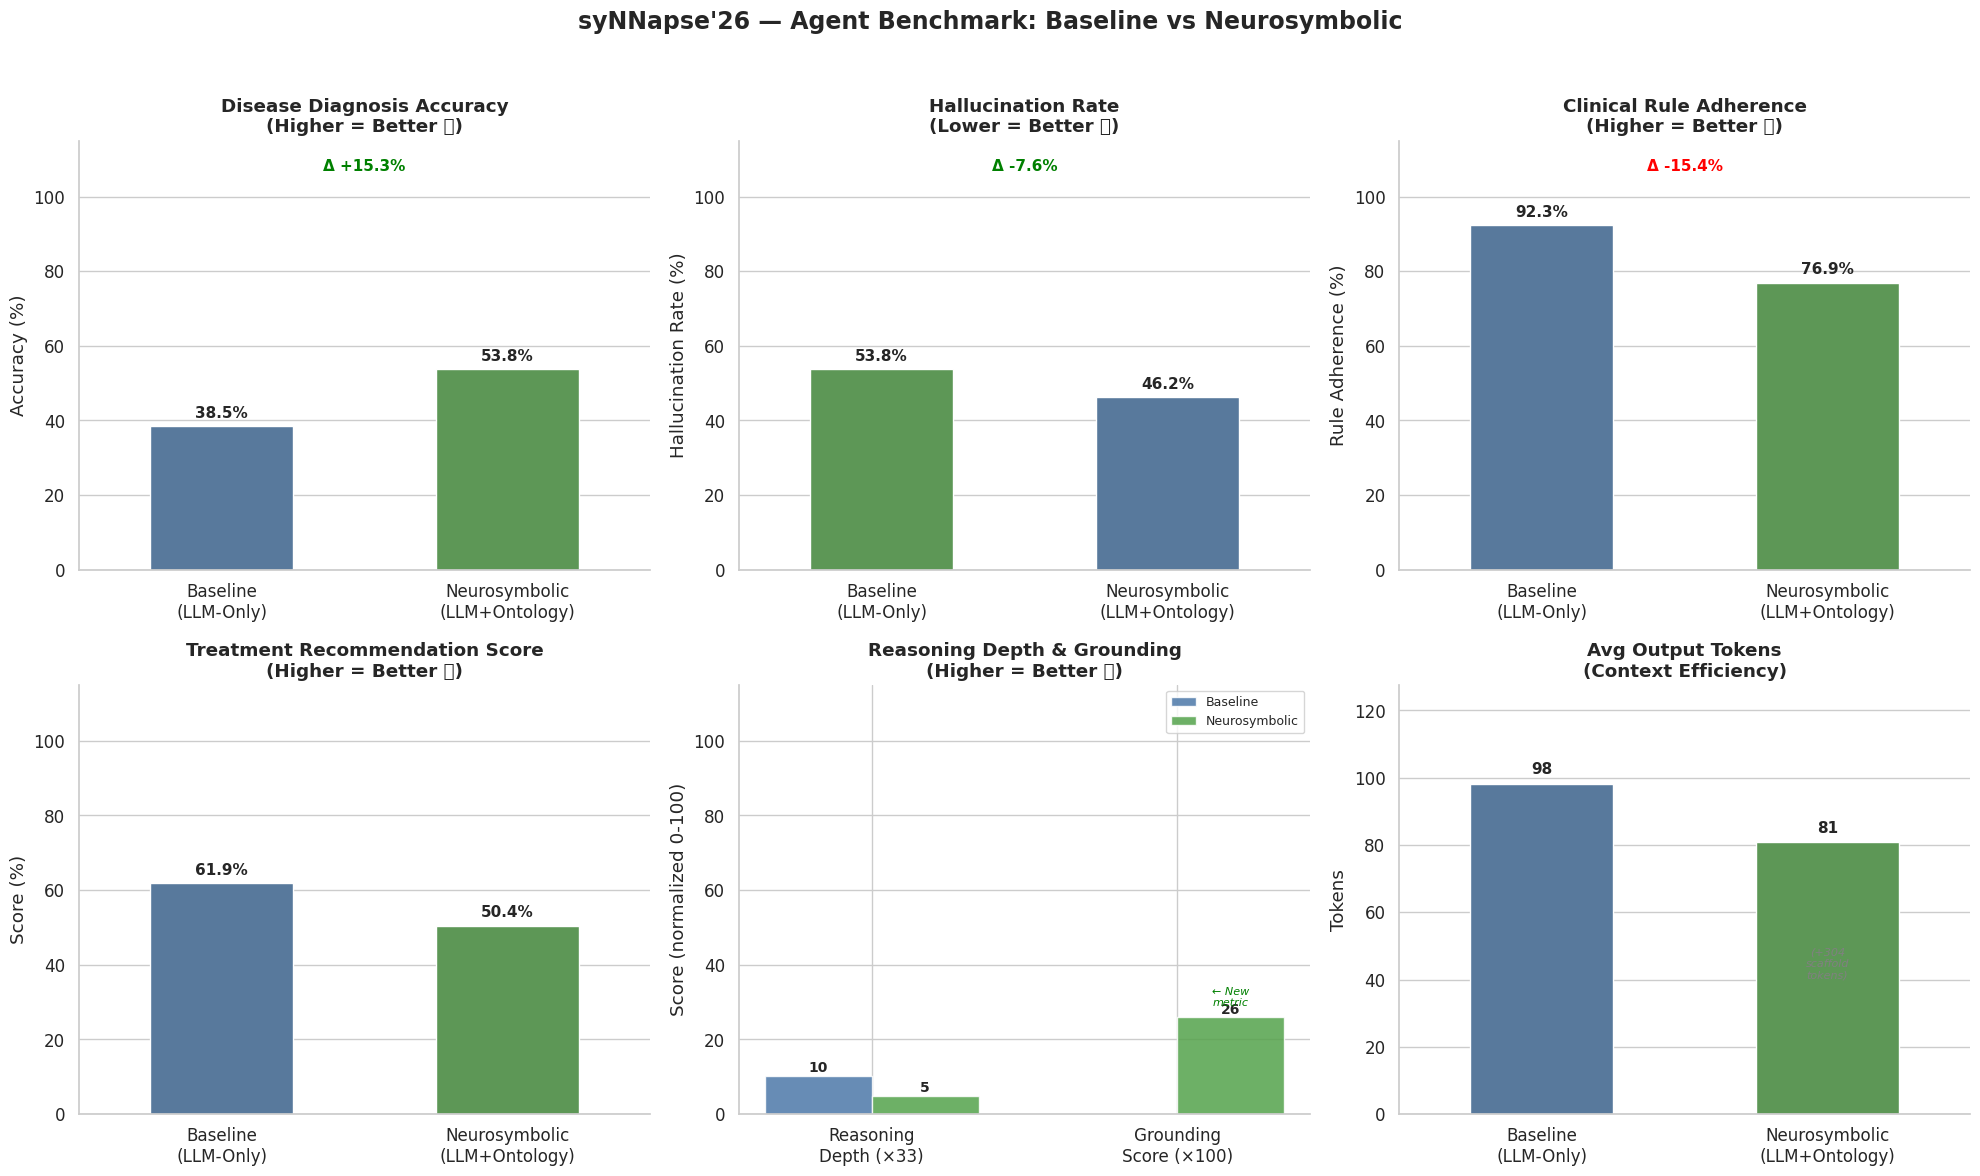

✅ Figure 1 saved: /content/drive/MyDrive/syNNapse26/agent_benchmark/plots/agent_comparison_main.png


In [43]:
# ══════════════════════════════════════════════════════════════
#  FIGURE 1: Main 6-panel comparison
# ══════════════════════════════════════════════════════════════
fig1, axes = plt.subplots(2, 3, figsize=(20, 12))
fig1.suptitle(
    "syNNapse'26 — Agent Benchmark: Baseline vs Neurosymbolic",
    fontsize=17, fontweight='bold', y=0.98
)

# ── Plot 1: Disease Accuracy ───────────────────────────────────
ax = axes[0, 0]
df = pd.DataFrame({'Agent': LABELS,
                   'Accuracy': [B['disease_accuracy_pct'], N['disease_accuracy_pct']]})
sns.barplot(data=df, x='Agent', y='Accuracy', palette=COLORS, ax=ax, width=0.5)
ax.set_title('Disease Diagnosis Accuracy\n(Higher = Better ✅)', fontweight='bold')
ax.set_ylabel('Accuracy (%)'); ax.set_xlabel(''); ax.set_ylim(0, 115)
add_labels(ax)
d = N['disease_accuracy_pct'] - B['disease_accuracy_pct']
ax.text(0.5, 107, f"Δ {'+' if d>=0 else ''}{d:.1f}%",
        ha='center', color='green' if d>=0 else 'red', fontweight='bold', fontsize=11,
        transform=ax.transData)

# ── Plot 2: Hallucination Rate ─────────────────────────────────
ax = axes[0, 1]
df = pd.DataFrame({'Agent': LABELS,
                   'Hallucination': [B['hallucination_rate_pct'], N['hallucination_rate_pct']]})
sns.barplot(data=df, x='Agent', y='Hallucination',
            palette=[C_NEURO, C_BASE], ax=ax, width=0.5)   # Flipped: lower=better
ax.set_title('Hallucination Rate\n(Lower = Better ✅)', fontweight='bold')
ax.set_ylabel('Hallucination Rate (%)'); ax.set_xlabel(''); ax.set_ylim(0, 115)
add_labels(ax)
d = N['hallucination_rate_pct'] - B['hallucination_rate_pct']
ax.text(0.5, 107, f"Δ {'+' if d>=0 else ''}{d:.1f}%",
        ha='center', color='green' if d<=0 else 'red', fontweight='bold', fontsize=11,
        transform=ax.transData)

# ── Plot 3: Rule Adherence ─────────────────────────────────────
ax = axes[0, 2]
df = pd.DataFrame({'Agent': LABELS,
                   'Rule Adherence': [B['rule_adherence_pct'], N['rule_adherence_pct']]})
sns.barplot(data=df, x='Agent', y='Rule Adherence', palette=COLORS, ax=ax, width=0.5)
ax.set_title('Clinical Rule Adherence\n(Higher = Better ✅)', fontweight='bold')
ax.set_ylabel('Rule Adherence (%)'); ax.set_xlabel(''); ax.set_ylim(0, 115)
add_labels(ax)
d = N['rule_adherence_pct'] - B['rule_adherence_pct']
ax.text(0.5, 107, f"Δ {'+' if d>=0 else ''}{d:.1f}%",
        ha='center', color='green' if d>=0 else 'red', fontweight='bold', fontsize=11,
        transform=ax.transData)

# ── Plot 4: Treatment Score ────────────────────────────────────
ax = axes[1, 0]
df = pd.DataFrame({'Agent': LABELS,
                   'Treatment': [B['avg_treatment_score_pct'], N['avg_treatment_score_pct']]})
sns.barplot(data=df, x='Agent', y='Treatment', palette=COLORS, ax=ax, width=0.5)
ax.set_title('Treatment Recommendation Score\n(Higher = Better ✅)', fontweight='bold')
ax.set_ylabel('Score (%)'); ax.set_xlabel(''); ax.set_ylim(0, 115)
add_labels(ax)

# ── Plot 5: Reasoning Depth + Grounding ───────────────────────
ax = axes[1, 1]
metrics  = ['Reasoning\nDepth (×33)', 'Grounding\nScore (×100)']
b_vals   = [B['avg_reasoning_depth']*33, 0]       # Baseline has no grounding
n_vals   = [N['avg_reasoning_depth']*33, N['avg_grounding_score']*100]
x        = np.arange(len(metrics))
width    = 0.35
bars1 = ax.bar(x - width/2, b_vals, width, label='Baseline', color=C_BASE, alpha=0.85)
bars2 = ax.bar(x + width/2, n_vals, width, label='Neurosymbolic', color=C_NEURO, alpha=0.85)
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.annotate(f'{h:.0f}',
                        (bar.get_x() + bar.get_width()/2, h + 1),
                        ha='center', fontsize=10, fontweight='bold')
ax.set_title('Reasoning Depth & Grounding\n(Higher = Better ✅)', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylabel('Score (normalized 0-100)')
ax.set_ylim(0, 115); ax.legend(fontsize=9)
ax.text(1 + width/2, n_vals[1] + 3, '← New\nmetric',
        ha='center', fontsize=8, color='green', style='italic')

# ── Plot 6: Token usage ────────────────────────────────────────
ax = axes[1, 2]
df = pd.DataFrame({
    'Agent'        : LABELS,
    'Output Tokens': [B['avg_output_tokens'], N['avg_output_tokens']]
})
sns.barplot(data=df, x='Agent', y='Output Tokens', palette=COLORS, ax=ax, width=0.5)
ax.set_title('Avg Output Tokens\n(Context Efficiency)', fontweight='bold')
ax.set_ylabel('Tokens'); ax.set_xlabel(''); ax.set_ylim(0, max(B['avg_output_tokens'], N['avg_output_tokens'])*1.3)
add_labels(ax, fmt="{:.0f}", offset=2)
# Add scaffold overhead note for neurosymbolic
ax.text(1, N['avg_output_tokens'] * 0.5,
        f"(+{N['avg_scaffold_tokens']:.0f}\nscaffold\ntokens)",
        ha='center', fontsize=8, color='gray', style='italic')

plt.tight_layout(rect=[0, 0, 1, 0.96])
p1 = f"{ACFG['AGENT_PLOTS']}/agent_comparison_main.png"
plt.savefig(p1, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f"✅ Figure 1 saved: {p1}")


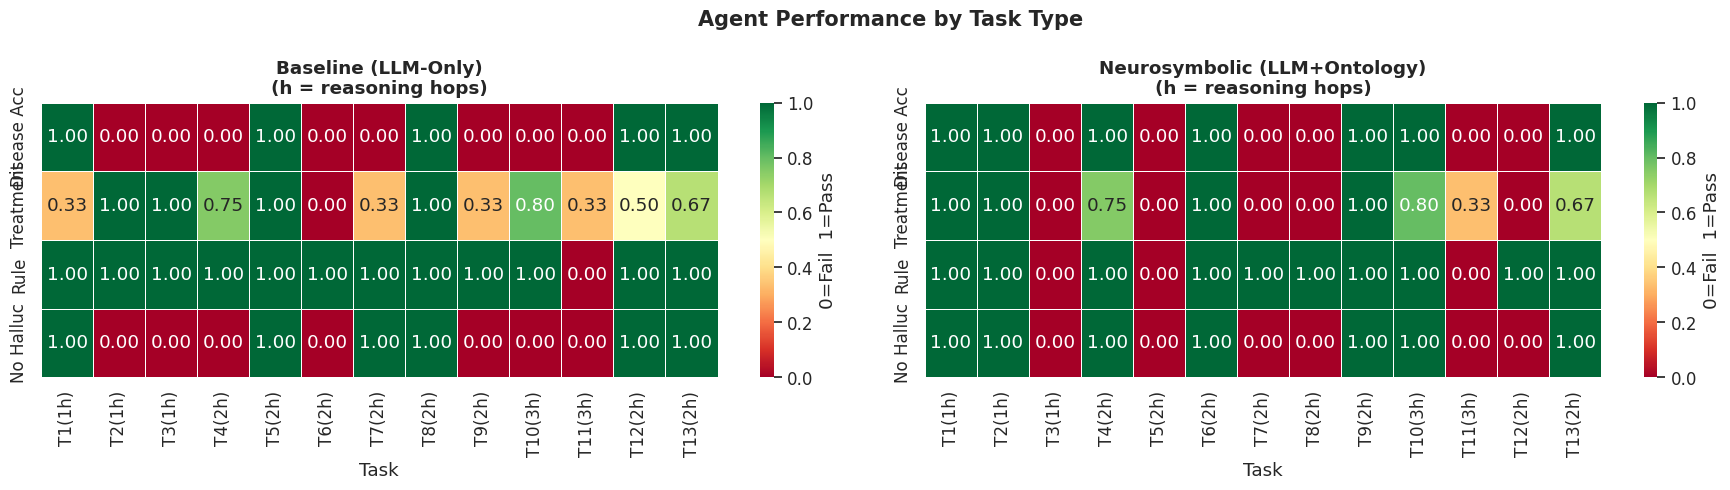

✅ Figure 2 saved: /content/drive/MyDrive/syNNapse26/agent_benchmark/plots/agent_task_heatmap.png


In [45]:
# ══════════════════════════════════════════════════════════════
#  FIGURE 2: Per Task-Type Heatmap
# ══════════════════════════════════════════════════════════════
fig2, axes2 = plt.subplots(1, 2, figsize=(18, 5))
fig2.suptitle("Agent Performance by Task Type", fontsize=15, fontweight='bold')

for ax, det, label, color in [
    (axes2[0], B_det, 'Baseline (LLM-Only)', C_BASE),
    (axes2[1], N_det, 'Neurosymbolic (LLM+Ontology)', C_NEURO)
]:
    # Build per-task matrix
    task_ids   = [r['task_id']           for r in det]
    task_types = [r['task_type'][:20]    for r in det]
    hops       = [r['reasoning_hops']    for r in det]

    heat_df = pd.DataFrame({
        'Task'          : [f"T{r['task_id']}({r['reasoning_hops']}h)" for r in det],
        'Disease Acc'   : [r['disease_accuracy']   for r in det],
        'Treatment'     : [r['treatment_score']    for r in det],
        'Rule'          : [r['rule_adherence']      for r in det],
        'No Halluc'     : [1 - r['hallucinated']   for r in det],
    }).set_index('Task')

    sns.heatmap(heat_df.T, annot=True, fmt='.2f', cmap='RdYlGn',
                ax=ax, linewidths=0.5, linecolor='white',
                vmin=0, vmax=1, cbar_kws={'label': '0=Fail  1=Pass'})
    ax.set_title(f'{label}\n(h = reasoning hops)', fontweight='bold')
    ax.set_ylabel('')

plt.tight_layout()
p2 = f"{ACFG['AGENT_PLOTS']}/agent_task_heatmap.png"
plt.savefig(p2, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f"✅ Figure 2 saved: {p2}")





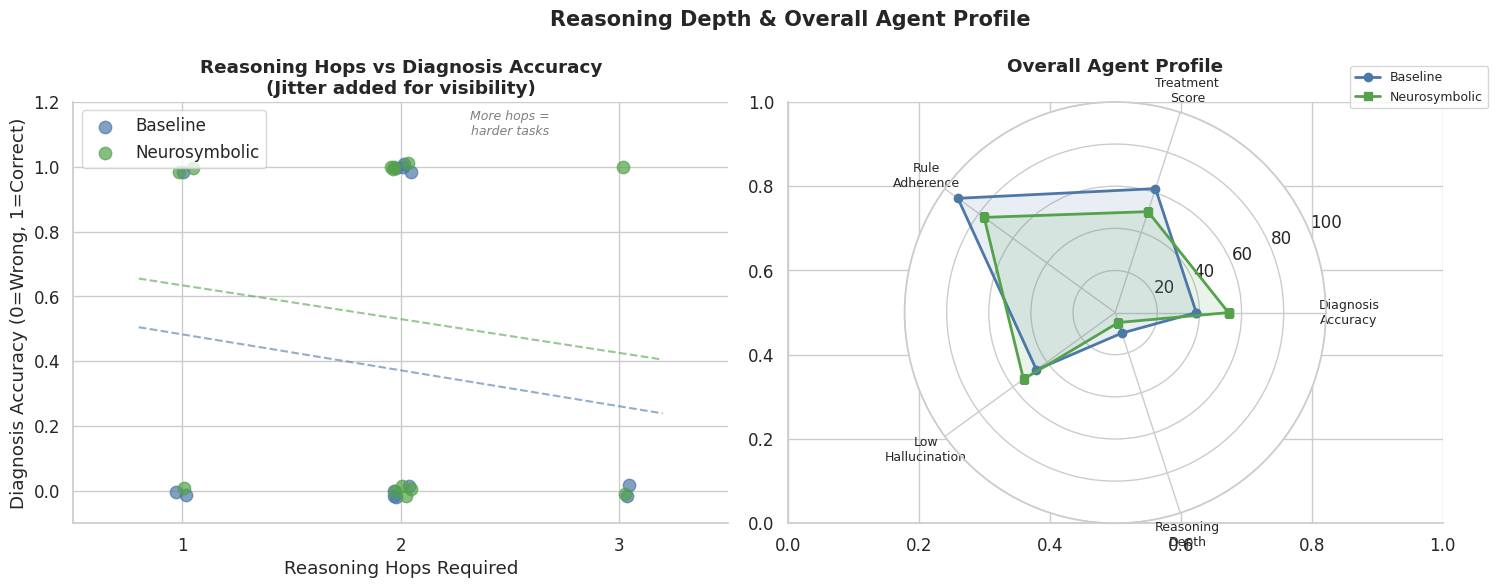

✅ Figure 3 saved: /content/drive/MyDrive/syNNapse26/agent_benchmark/plots/agent_profile_radar.png

✅ All agent visualisations saved to Drive: /content/drive/MyDrive/syNNapse26/agent_benchmark/plots


In [46]:
# ══════════════════════════════════════════════════════════════
#  FIGURE 3: Reasoning Hops vs Accuracy + Radar
# ══════════════════════════════════════════════════════════════
fig3, axes3 = plt.subplots(1, 2, figsize=(16, 6))
fig3.suptitle("Reasoning Depth & Overall Agent Profile", fontsize=15, fontweight='bold')

# ── Scatter: Hops vs Accuracy ──────────────────────────────────
ax = axes3[0]
b_hops = [r['reasoning_hops'] + np.random.uniform(-0.05, 0.05) for r in B_det]
n_hops = [r['reasoning_hops'] + np.random.uniform(-0.05, 0.05) for r in N_det]
b_acc  = [r['disease_accuracy'] + np.random.uniform(-0.02, 0.02) for r in B_det]
n_acc  = [r['disease_accuracy'] + np.random.uniform(-0.02, 0.02) for r in N_det]

ax.scatter(b_hops, b_acc, color=C_BASE,  s=80, alpha=0.7, label='Baseline',       zorder=3)
ax.scatter(n_hops, n_acc, color=C_NEURO, s=80, alpha=0.7, label='Neurosymbolic',  zorder=3)

# Trend lines
for hops_data, acc_data, color in [(b_hops, b_acc, C_BASE), (n_hops, n_acc, C_NEURO)]:
    z = np.polyfit(hops_data, acc_data, 1)
    p = np.poly1d(z)
    x_line = np.linspace(0.8, 3.2, 50)
    ax.plot(x_line, p(x_line), color=color, linewidth=1.5, linestyle='--', alpha=0.6)

ax.set_title('Reasoning Hops vs Diagnosis Accuracy\n(Jitter added for visibility)', fontweight='bold')
ax.set_xlabel('Reasoning Hops Required')
ax.set_ylabel('Diagnosis Accuracy (0=Wrong, 1=Correct)')
ax.set_xlim(0.5, 3.5); ax.set_ylim(-0.1, 1.2)
ax.set_xticks([1, 2, 3]); ax.legend()
ax.text(2.5, 1.1, 'More hops =\nharder tasks', ha='center', fontsize=9, color='gray', style='italic')

# ── Radar chart ────────────────────────────────────────────────
ax_r = fig3.add_subplot(1, 2, 2, polar=True)

categories = ['Diagnosis\nAccuracy', 'Treatment\nScore',
              'Rule\nAdherence', 'Low\nHallucination', 'Reasoning\nDepth']
Nc = len(categories)

b_speed = min(100, 100 / max(B['avg_latency_sec'], 0.5))
n_speed = min(100, 100 / max(N['avg_latency_sec'], 0.5))

b_vals = [B['disease_accuracy_pct'], B['avg_treatment_score_pct'],
          B['rule_adherence_pct'], 100 - B['hallucination_rate_pct'],
          B['avg_reasoning_depth'] * 33]
n_vals = [N['disease_accuracy_pct'], N['avg_treatment_score_pct'],
          N['rule_adherence_pct'], 100 - N['hallucination_rate_pct'],
          N['avg_reasoning_depth'] * 33]

angles   = [i/float(Nc)*2*np.pi for i in range(Nc)] + [0]
b_vals  += b_vals[:1]
n_vals  += n_vals[:1]

ax_r.set_xticks(angles[:-1]); ax_r.set_xticklabels(categories, size=9)
ax_r.set_ylim(0, 100)
ax_r.plot(angles, b_vals, 'o-', lw=2, color=C_BASE,  label='Baseline')
ax_r.fill(angles, b_vals, alpha=0.12, color=C_BASE)
ax_r.plot(angles, n_vals, 's-', lw=2, color=C_NEURO, label='Neurosymbolic')
ax_r.fill(angles, n_vals, alpha=0.12, color=C_NEURO)
ax_r.set_title('Overall Agent Profile', fontweight='bold', pad=22)
ax_r.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1), fontsize=9)

plt.tight_layout()
p3 = f"{ACFG['AGENT_PLOTS']}/agent_profile_radar.png"
plt.savefig(p3, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f"✅ Figure 3 saved: {p3}")

print(f"\n✅ All agent visualisations saved to Drive: {ACFG['AGENT_PLOTS']}")

## Final Agent Benchmark Report Table

In [47]:
import json, pandas as pd
from IPython.display import display, HTML

with open('/content/drive/MyDrive/syNNapse26/agent_benchmark/agent_config.json') as f:
    ACFG = json.load(f)
with open(f"{ACFG['BASELINE_DIR']}/summary.json") as f:
    B = json.load(f)
with open(f"{ACFG['NEURO_DIR']}/summary.json") as f:
    N = json.load(f)

In [48]:
# ── PS-required table format (extended) ───────────────────────
final_df = pd.DataFrame([
    {
        'System'                   : '🔵 Baseline (LLM-Only)',
        'Diagnosis Accuracy (%)'   : B['disease_accuracy_pct'],
        'Hallucination Rate (%)'   : B['hallucination_rate_pct'],
        'Treatment Score (%)'      : B['avg_treatment_score_pct'],
        'Rule Adherence (%)'       : B['rule_adherence_pct'],
        'Reasoning Depth (/3)'     : B['avg_reasoning_depth'],
        'Grounding Score'          : 'N/A',
        'Avg Tokens'               : B['avg_output_tokens'],
        'Avg Latency (s)'          : B['avg_latency_sec'],
    },
    {
        'System'                   : '🟢 Neurosymbolic (LLM+KG)',
        'Diagnosis Accuracy (%)'   : N['disease_accuracy_pct'],
        'Hallucination Rate (%)'   : N['hallucination_rate_pct'],
        'Treatment Score (%)'      : N['avg_treatment_score_pct'],
        'Rule Adherence (%)'       : N['rule_adherence_pct'],
        'Reasoning Depth (/3)'     : N['avg_reasoning_depth'],
        'Grounding Score'          : N['avg_grounding_score'],
        'Avg Tokens'               : N['avg_output_tokens'],
        'Avg Latency (s)'          : N['avg_latency_sec'],
    }
])

styled = (
    final_df.style
    .set_caption("Agent Benchmark Results — syNNapse'26")
    .highlight_max(
        subset=['Diagnosis Accuracy (%)', 'Treatment Score (%)',
                'Rule Adherence (%)', 'Reasoning Depth (/3)'],
        color='#c6f4c2'
    )
    .highlight_min(
        subset=['Hallucination Rate (%)', 'Avg Tokens', 'Avg Latency (s)'],
        color='#c6f4c2'
    )
    .set_properties(**{'text-align': 'center', 'font-size': '13px',
                       'border': '1px solid #ddd', 'padding': '8px 12px'})
    .set_table_styles([{
        'selector': 'caption',
        'props': [('font-size','15px'),('font-weight','bold'),('padding','10px')]
    }, {
        'selector': 'th',
        'props': [('background-color','#2c3e50'),('color','white'),('padding','10px')]
    }])
    .format(precision=1, na_rep='N/A')
)
display(styled)


,System,Diagnosis Accuracy (%),Hallucination Rate (%),Treatment Score (%),Rule Adherence (%),Reasoning Depth (/3),Grounding Score,Avg Tokens,Avg Latency (s)
0,🔵 Baseline (LLM-Only),38.5,53.8,61.9,92.3,0.3,N/A,98.2,7.6
1,🟢 Neurosymbolic (LLM+KG),53.8,46.2,50.4,76.9,0.1,0.3,80.8,6.2


In [49]:
# ── Improvement deltas ─────────────────────────────────────────
print("\n IMPROVEMENT: Neurosymbolic vs Baseline")
print("─" * 58)
for label, b_val, n_val, higher_better in [
    ("Diagnosis Accuracy (%)", B['disease_accuracy_pct'],   N['disease_accuracy_pct'],   True),
    ("Hallucination Rate (%)", B['hallucination_rate_pct'], N['hallucination_rate_pct'], False),
    ("Treatment Score (%)",    B['avg_treatment_score_pct'],N['avg_treatment_score_pct'],True),
    ("Rule Adherence (%)",     B['rule_adherence_pct'],     N['rule_adherence_pct'],     True),
    ("Reasoning Depth",        B['avg_reasoning_depth'],    N['avg_reasoning_depth'],    True),
    ("Avg Tokens",             B['avg_output_tokens'],      N['avg_output_tokens'],      False),
]:
    delta = n_val - b_val
    good  = (delta > 0 and higher_better) or (delta < 0 and not higher_better)
    icon  = '✅' if good else ('➡️' if delta == 0 else '❌')
    print(f"  {label:<30}: {'+' if delta>=0 else ''}{delta:.1f} {icon}")


 IMPROVEMENT: Neurosymbolic vs Baseline
──────────────────────────────────────────────────────────
  Diagnosis Accuracy (%)        : +15.3 ✅
  Hallucination Rate (%)        : -7.6 ✅
  Treatment Score (%)           : -11.5 ❌
  Rule Adherence (%)            : -15.4 ❌
  Reasoning Depth               : -0.2 ❌
  Avg Tokens                    : -17.4 ✅


In [50]:
# ── Save CSV ───────────────────────────────────────────────────
csv_path = f"{ACFG['AGENT_DIR']}/agent_benchmark_final.csv"
final_df.to_csv(csv_path, index=False)

print(f"\n✅ Table saved: {csv_path}")

print("\n  AGENT BENCHMARK COMPLETE!")
print(f"\n  Drive → {ACFG['AGENT_DIR']}/")
print("  ├── baseline_agent/   → detailed_results.json, summary.json")
print("  ├── neurosymbolic_agent/ → detailed_results.json, summary.json")
print("  ├── plots/            → 3 seaborn figures")
print("  └── agent_benchmark_final.csv")
print("\n  Next: ContextBench notebook")



✅ Table saved: /content/drive/MyDrive/syNNapse26/agent_benchmark/agent_benchmark_final.csv

  AGENT BENCHMARK COMPLETE!

  Drive → /content/drive/MyDrive/syNNapse26/agent_benchmark/
  ├── baseline_agent/   → detailed_results.json, summary.json
  ├── neurosymbolic_agent/ → detailed_results.json, summary.json
  ├── plots/            → 3 seaborn figures
  └── agent_benchmark_final.csv

  Next: ContextBench notebook


# Context Benchmark

## Setup: ContextBench Implementation

We implement ContextBench's EXACT evaluation framework as described in the PS document:                           
- config.yaml style experiment configs                    
 - 3 context policies per use-case                         
 - All 6 required metrics                                  
- 4-system comparison table                               
 - token + cost budgets   


In [1]:
!pip install -q pyyaml seaborn matplotlib pandas
!pip install -q unsloth transformers accelerate bitsandbytes peft
!pip install -q rouge-score


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 MB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 87.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 418.4/418.4 kB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 89.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 97.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 106.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.

In [2]:
import torch
print("✅ Dependencies ready")
print(f" GPU : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")
print(f" VRAM: {torch.cuda.memory_allocated()/1e9:.1f}/{torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")


✅ Dependencies ready
 GPU : Tesla T4
 VRAM: 0.0/15.6 GB


## Drive Mount + ContextBench Config Files

Creates experiment config YAMLs — :  
"Create an experiment configuration file specifying:  

model, dataset, policies, token and cost budgets"


In [3]:
from google.colab import drive
import os, json, yaml

drive.mount('/content/drive')

# ── Paths ──────────────────────────────────────────────────────
BASE_DIR  = '/content/drive/MyDrive/syNNapse26'
CB_DIR    = f'{BASE_DIR}/contextbench'
PLOTS_DIR = f'{CB_DIR}/plots'
YAML_DIR  = f'{CB_DIR}/configs'

for d in [CB_DIR, PLOTS_DIR, YAML_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Load previous configs ──────────────────────────────────────
with open(f'{BASE_DIR}/paths_config.json') as f:
    MCFG = json.load(f)
with open(f'{BASE_DIR}/agent_benchmark/agent_config.json') as f:
    ACFG = json.load(f)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
#  3 CONTEXT POLICIES for Healthcare:
#  1. full_context    — entire conversation history in context
#  2. rag_policy      — retrieve only relevant ontology chunks
#  3. compression     — compress + summarise history

CONFIGS = {

    "full_context": {
        "experiment_name"   : "contextbench_full_context",
        "use_case"          : "Healthcare Clinical Decision Assistant",
        "model"             : MCFG.get('MODEL_NAME', 'mistral-7b-instruct'),
        "dataset"           : "patient_records_and_clinical_guidelines",
        "policy"            : "full_context",
        "policy_description": "Entire patient history + all ontology knowledge passed in context",
        "token_budget"      : 2048,
        "cost_per_1k_tokens": 0.0002,   # Approximate for open-source on Colab
        "max_new_tokens"    : 300,
        "systems"           : ["base_model", "pretrained_model",
                               "baseline_agent", "neurosymbolic_agent"],
    },

    "rag_policy": {
        "experiment_name"   : "contextbench_rag_policy",
        "use_case"          : "Healthcare Clinical Decision Assistant",
        "model"             : MCFG.get('MODEL_NAME', 'mistral-7b-instruct'),
        "dataset"           : "patient_records_and_clinical_guidelines",
        "policy"            : "rag_policy",
        "policy_description": "Only retrieve relevant ontology subgraph for current query",
        "token_budget"      : 1024,
        "cost_per_1k_tokens": 0.0002,
        "max_new_tokens"    : 300,
        "systems"           : ["base_model", "pretrained_model",
                               "baseline_agent", "neurosymbolic_agent"],
    },

    "compression_policy": {
        "experiment_name"   : "contextbench_compression",
        "use_case"          : "Healthcare Clinical Decision Assistant",
        "model"             : MCFG.get('MODEL_NAME', 'mistral-7b-instruct'),
        "dataset"           : "patient_records_and_clinical_guidelines",
        "policy"            : "compression_policy",
        "policy_description": "Compress patient history to key facts + selective ontology retrieval",
        "token_budget"      : 512,
        "cost_per_1k_tokens": 0.0002,
        "max_new_tokens"    : 300,
        "systems"           : ["base_model", "pretrained_model",
                               "baseline_agent", "neurosymbolic_agent"],
    },
}

In [6]:
# Save all configs as YAML files (exactly as PS requires)
for policy_name, config in CONFIGS.items():
    yaml_path = f"{YAML_DIR}/{policy_name}.yaml"
    with open(yaml_path, 'w') as f:
        yaml.dump(config, f, default_flow_style=False)
    print(f"📄 Config saved: {yaml_path}")


📄 Config saved: /content/drive/MyDrive/syNNapse26/contextbench/configs/full_context.yaml
📄 Config saved: /content/drive/MyDrive/syNNapse26/contextbench/configs/rag_policy.yaml
📄 Config saved: /content/drive/MyDrive/syNNapse26/contextbench/configs/compression_policy.yaml


In [7]:
# Save CB config for later cells
CB_CONFIG = {
    'BASE_DIR'  : BASE_DIR,
    'CB_DIR'    : CB_DIR,
    'PLOTS_DIR' : PLOTS_DIR,
    'YAML_DIR'  : YAML_DIR,
    'MODEL_NAME': MCFG.get('MODEL_NAME', 'mistral-7b-instruct'),
    'LORA_DIR'  : MCFG.get('LORA_DIR', ''),
    'POLICIES'  : list(CONFIGS.keys()),
    'SYSTEMS'   : ["base_model", "pretrained_model",
                   "baseline_agent", "neurosymbolic_agent"],
}
with open(f'{CB_DIR}/cb_config.json', 'w') as f:
    json.dump(CB_CONFIG, f, indent=2)

print(f"\n✅ ContextBench experiment configs created")
print(f"   Policies : {list(CONFIGS.keys())}")
print(f"   Systems  : 4 (base, pretrained, baseline agent, neurosymbolic)")
print(f"\n📁 Drive: {CB_DIR}/")
print(f"   └── configs/  ← 3 YAML experiment files")



✅ ContextBench experiment configs created
   Policies : ['full_context', 'rag_policy', 'compression_policy']
   Systems  : 4 (base, pretrained, baseline agent, neurosymbolic)

📁 Drive: /content/drive/MyDrive/syNNapse26/contextbench/
   └── configs/  ← 3 YAML experiment files


## Load Model + Define 3 Context Policies

3 POLICIES implemented:                       
1. full_context (2048 token budget)  
→ Full patient history + full ontology in prompt   
→ Highest accuracy, highest token cost                   
 2. rag_policy (1024 token budget)                         
 → Only retrieve relevant ontology chunk for query        
   → Neurosymbolic advantage: KG gives precise retrieval                         
 3. compression_policy (512 token budget)                   
  → Compress history to bullet summary + minimal context    
  → Tests how well each system handles tight budgets

In [8]:
import json, torch, gc, time
from unsloth import FastLanguageModel

with open('/content/drive/MyDrive/syNNapse26/contextbench/cb_config.json') as f:
    CB = json.load(f)
with open(f"{CB['CB_DIR']}/../agent_benchmark/ontology.json") as f:
    ONTOLOGY = json.load(f)

# ── GPU cleanup ────────────────────────────────────────────────
gc.collect(); torch.cuda.empty_cache()
print(f"🧹 VRAM before load: {torch.cuda.memory_allocated()/1e9:.1f} GB")


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
🧹 VRAM before load: 0.0 GB


In [9]:
# We load base model ONCE and swap LoRA adapters
# to avoid reloading full weights multiple times
print(f"⏳ Loading model...")

base_model, tokenizer = FastLanguageModel.from_pretrained(
    model_name    = CB['MODEL_NAME'],
    max_seq_length= 2048,
    dtype         = None,
    load_in_4bit  = True,
)
print(f"✅ Base model loaded | VRAM: {torch.cuda.memory_allocated()/1e9:.1f} GB")

⏳ Loading model...
==((====))==  Unsloth 2026.4.4: Fast Mistral patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/4.14G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/157 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/587k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/446 [00:00<?, ?B/s]

✅ Base model loaded | VRAM: 4.2 GB


In [10]:
#  CONTEXT POLICY FUNCTIONS
#  Each policy takes (query, history, ontology_data) and
#  returns a context-managed prompt string


def build_prompt_mistral(system, context, query):
    return f"[INST] {system}\n\nContext:\n{context}\n\nQuery: {query} [/INST]"

SYSTEM_PROMPT = "You are an expert AI medical assistant. Use the provided context to diagnose and recommend treatment."

In [11]:
# ── Policy 1: Full Context ─────────────────────────────────────
def policy_full_context(query, patient_history, ontology_snippet, token_budget=2048):
    """
    Passes everything available into context.
    No compression, no retrieval — just dump it all.
    Represents naive/baseline context management.
    """
    context = f"Patient History:\n{patient_history}\n\nMedical Knowledge:\n{ontology_snippet}"
    prompt  = build_prompt_mistral(SYSTEM_PROMPT, context, query)
    tokens  = tokenizer(prompt, return_tensors='pt')['input_ids'].shape[1]

    # If over budget, truncate from the MIDDLE of patient history
    if tokens > token_budget:
        # Truncate history to fit
        words   = patient_history.split()
        allowed = max(50, len(words) - (tokens - token_budget) // 2)
        patient_history = ' '.join(words[:allowed]) + ' [TRUNCATED]'
        context = f"Patient History:\n{patient_history}\n\nMedical Knowledge:\n{ontology_snippet}"
        prompt  = build_prompt_mistral(SYSTEM_PROMPT, context, query)

    return prompt, len(tokenizer(prompt, return_tensors='pt')['input_ids'][0])

In [12]:
# ── Policy 2: RAG Policy ───────────────────────────────────────
def policy_rag(query, patient_history, ontology_snippet,
               token_budget=1024, symptoms=None):
    """
    Retrieves ONLY the relevant ontology chunk for current query.
    Neurosymbolic advantage: KG gives precise, targeted retrieval
    vs baseline which doesn't know what to retrieve.

    For baseline/base_model: retrieves first N chars of ontology
    For neurosymbolic: retrieves exact disease subgraph
    """
    # Compact patient history — only last 2 facts
    history_lines  = [l for l in patient_history.split('\n') if l.strip()]
    compact_history = '\n'.join(history_lines[-3:]) if len(history_lines) > 3 else patient_history

    # Retrieve relevant ontology chunk
    if symptoms:
        # Targeted retrieval using symptom matching (neurosymbolic)
        relevant_diseases = []
        for disease, data in ONTOLOGY.items():
            disease_syms = list(data.get('symptoms', {}).keys())
            if any(s.lower() in query.lower() for s in disease_syms):
                treats = [t for t in data.get('treatment', []) if t and t.lower() != 'nan']
                relevant_diseases.append(
                    f"{disease}: symptoms={disease_syms[:3]}, "
                    f"treatments={treats[:2]}"
                )
        retrieved = '\n'.join(relevant_diseases[:3]) if relevant_diseases else ontology_snippet[:300]
    else:
        # Blind retrieval (baseline) — just first part of ontology
        retrieved = ontology_snippet[:400]

    context = f"Recent History:\n{compact_history}\n\nRelevant Medical Knowledge:\n{retrieved}"
    prompt  = build_prompt_mistral(SYSTEM_PROMPT, context, query)
    tokens  = len(tokenizer(prompt, return_tensors='pt')['input_ids'][0])
    return prompt, tokens

In [13]:
# ── Policy 3: Compression Policy ──────────────────────────────
def policy_compression(query, patient_history, ontology_snippet,
                        token_budget=512, symptoms=None):
    """
    Maximally compressed context — fits in 512 tokens.
    Compresses history to 1-2 bullet points.
    Only includes ontology facts directly relevant to query.

    Tests: can system still reason correctly under extreme
    token constraints? Neurosymbolic should degrade less.
    """
    # Compress history to 1-line summary
    lines    = [l.strip() for l in patient_history.split('\n') if l.strip()]
    summary  = lines[0] if lines else "Patient data unavailable"
    compressed_history = f"Summary: {summary[:100]}"

    # Minimal ontology: just disease names + 1 treatment each
    if symptoms:
        mini_facts = []
        for disease, data in ONTOLOGY.items():
            disease_syms = list(data.get('symptoms', {}).keys())
            if any(s.lower() in query.lower() for s in disease_syms):
                treat = next((t for t in data.get('treatment',[]) if t and t.lower()!='nan'), 'see specialist')
                mini_facts.append(f"{disease}: {treat[:50]}")
        mini_ontology = '\n'.join(mini_facts[:2]) if mini_facts else ''
    else:
        mini_ontology = ''   # Baseline gets no ontology under compression

    context = f"{compressed_history}\nKey facts: {mini_ontology}"
    prompt  = build_prompt_mistral(SYSTEM_PROMPT, context, query)
    tokens  = len(tokenizer(prompt, return_tensors='pt')['input_ids'][0])
    return prompt, tokens

In [14]:
# Policy dispatcher
POLICY_FUNCTIONS = {
    'full_context'      : policy_full_context,
    'rag_policy'        : policy_rag,
    'compression_policy': policy_compression,
}

POLICY_BUDGETS = {
    'full_context'      : 2048,
    'rag_policy'        : 1024,
    'compression_policy': 512,
}

print("\n✅ 3 context policies defined:")
print("   full_context       → 2048 token budget (full history)")
print("   rag_policy         → 1024 token budget (targeted retrieval)")
print("   compression_policy → 512  token budget (max compression)")


✅ 3 context policies defined:
   full_context       → 2048 token budget (full history)
   rag_policy         → 1024 token budget (targeted retrieval)
   compression_policy → 512  token budget (max compression)


## ContextBench Task Dataset

 Dataset should have:                            
 - tasks.json                                              
- supporting documents (patient history + guidelines)     

 Each task has:         
  - patient_history : long context document         
   - query           : diagnostic question        
  - expected_disease: ground truth                       
  - symptoms        : for ontology lookup              
   - expected_keywords: for treatment scoring       
     
     
Patient histories are intentionally LONG (simulate real     
 medical records) — this is what stresses context policies

In [15]:
import json, os

with open('/content/drive/MyDrive/syNNapse26/contextbench/cb_config.json') as f:
    CB = json.load(f)


In [16]:
#  CONTEXTBENCH TASKS
#  Patient histories are verbose to stress-test context policies
CB_TASKS = [
    {
        "id"                : 1,
        "query"             : "Patient has intense itching especially at night and small blisters on skin. What is the diagnosis and treatment?",
        "symptoms"          : ["intense itching", "especially at night", "small blisters or bumps"],
        "expected_disease"  : "Scabies",
        "expected_keywords" : ["scabicides", "hot water", "washing"],
        "patient_history"   : """
Patient ID: MED-2024-001
Age: 34 | Gender: Female | Visit Date: 2024-01-15
Chief Complaint: Severe itching for 3 weeks

History of Present Illness:
Patient presents with a 3-week history of intense generalized pruritus, predominantly worse at nighttime. She reports the itching is so severe it disrupts her sleep. On examination, small erythematous papules and vesicles noted on web spaces of fingers, wrists, and ankles. Her husband also reports similar symptoms starting 1 week after hers began.

Past Medical History: No significant conditions. Appendectomy 2019.
Medications: None currently. Allergic to Penicillin.
Social History: Lives with husband and two children. Works as schoolteacher.
Review of Systems: Itching worse at night. No fever. No respiratory symptoms.

Vitals: BP 118/76, HR 72, Temp 37.1°C, RR 16, SpO2 98%
Physical Exam: Multiple small vesicles and papules in interdigital spaces bilaterally. Excoriation marks present. No lymphadenopathy.
        """.strip(),
    },
    {
        "id"                : 2,
        "query"             : "Patient complains of blurred distance vision, eyestrain, and squinting. Diagnose and suggest treatment.",
        "symptoms"          : ["blurred distance vision", "eyestrain", "squinting"],
        "expected_disease"  : "Myopia",
        "expected_keywords" : ["eyeglasses", "contact lenses", "LASIK"],
        "patient_history"   : """
Patient ID: MED-2024-002
Age: 17 | Gender: Male | Visit Date: 2024-02-08
Chief Complaint: Difficulty seeing the whiteboard at school

History of Present Illness:
17-year-old male presents with a 6-month history of progressively worsening difficulty seeing objects at a distance. He reports squinting to see the whiteboard at school and frequent headaches after prolonged reading or screen use. Mother reports he holds books very close to his face. No diplopia or flashes.

Past Medical History: Mild asthma (well-controlled on PRN albuterol). Eczema (resolved).
Family History: Mother wears prescription glasses for myopia since age 15.
Social History: Student, spends approximately 6 hours/day on screens.
Medications: Albuterol inhaler PRN

Vitals: BP 110/70, HR 68, Temp 36.9°C
Eye Exam: Visual acuity OD 20/200, OS 20/150 uncorrected. Cover test normal. EOM intact. No papilledema. Fundoscopy normal.
        """.strip(),
    },
    {
        "id"                : 3,
        "query"             : "Emergency patient with headache, confusion, and dizziness. What is the critical diagnosis and immediate treatment protocol?",
        "symptoms"          : ["headache", "confusion", "dizziness", "nausea or vomiting"],
        "expected_disease"  : "Subdural hemorrhage",
        "expected_keywords" : ["immediate medical attention", "CT", "MRI", "surgical"],
        "patient_history"   : """
Patient ID: MED-2024-003
Age: 68 | Gender: Male | Visit Date: 2024-03-01 — EMERGENCY
Chief Complaint: Sudden onset severe headache and confusion — BROUGHT BY FAMILY

History of Present Illness:
68-year-old male brought to ER by family after sudden onset of severe headache described as 'worst headache of my life' approximately 2 hours ago. Family reports increasing confusion, disorientation to time and place, and two episodes of vomiting. No witnessed seizures. History of fall from ladder 10 days ago with head trauma — was cleared at urgent care at the time.

Past Medical History: Hypertension (on lisinopril), Type 2 DM (metformin), Atrial Fibrillation (on warfarin — CRITICAL).
Current Medications: Lisinopril 10mg, Metformin 1000mg, WARFARIN 5mg daily.
Allergies: Sulfa drugs.
Vitals: BP 178/102 (elevated), HR 88 irregular, Temp 37.0°C, GCS 13/15
Neuro Exam: Confused, oriented to person only. Pupils 3mm equal reactive. Mild left-sided weakness noted. No neck stiffness.
        """.strip(),
    },
    {
        "id"                : 4,
        "query"             : "Patient with cough with phlegm, chest pain, and fever. Is this a pulmonary emergency? Diagnose and treat.",
        "symptoms"          : ["cough with phlegm or pus", "chest pain", "fever", "shortness of breath"],
        "expected_disease"  : "Abscess of the Lung",
        "expected_keywords" : ["antibiotics", "drainage", "surgical"],
        "patient_history"   : """
Patient ID: MED-2024-004
Age: 52 | Gender: Male | Visit Date: 2024-03-15
Chief Complaint: 3-week productive cough with foul-smelling sputum and fever

History of Present Illness:
52-year-old male with 3-week history of productive cough yielding large amounts of foul-smelling greenish sputum. Reports pleuritic chest pain on right side, fever with night sweats, and significant fatigue and weight loss of 5kg over 3 weeks. Reports history of aspiration event 4 weeks ago following dental procedure under general anaesthesia.

Past Medical History: Alcohol use disorder (still drinking). GERD. No prior lung disease.
Social History: Retired construction worker. Smoker (30 pack-years). Alcohol — approximately 8 units/day.
Medications: Omeprazole 20mg.
Vitals: BP 105/70 (low), HR 102 (tachycardia), Temp 38.9°C (febrile), RR 24/min, SpO2 91% on room air
Chest Exam: Dullness to percussion right lower zone. Decreased air entry right base. Crackles heard.
CXR: Right lower lobe opacity with possible air-fluid level.
        """.strip(),
    },
    {
        "id"                : 5,
        "query"             : "Cloudy eyes, excessive tearing, sensitivity to light in a newborn. What condition and what are the surgical options?",
        "symptoms"          : ["cloudy or hazy eyes", "excessive tearing", "sensitivity to light"],
        "expected_disease"  : "Congenital Glaucoma",
        "expected_keywords" : ["surgery", "trabeculotomy", "intraocular pressure"],
        "patient_history"   : """
Patient ID: MED-2024-005 (PAEDIATRIC)
Age: 4 weeks | Gender: Female | Visit Date: 2024-04-02
Chief Complaint: Parents concerned about baby's eyes appearing cloudy since birth

History of Present Illness:
4-week-old female infant brought by parents due to concern about cloudy appearance of both eyes since birth. Parents note excessive tearing, infant appears to squint in normal light (photophobia), and repeatedly rubs eyes. Eyes appear larger than expected for age. No family history of eye conditions. Normal full-term delivery at 39 weeks. No complications during pregnancy.

Birth History: G1P1, spontaneous vaginal delivery, Apgar 8 and 9.
Neonatal Screen: Normal. Hearing screen passed.
Family History: No glaucoma, cataracts or other eye conditions.
Vitals: Weight 4.1kg (50th centile). Length 52cm. HC 36cm.
Eye Exam: Corneal diameter both eyes 12mm (enlarged). Corneal oedema with Haab's striae visible. IOP estimated elevated. Fundoscopy: optic disc cupping noted bilaterally.
        """.strip(),
    },
    {
        "id"                : 6,
        "query"             : "Itchy skin particularly on hands and feet during pregnancy. What should be the differential diagnosis?",
        "symptoms"          : ["itchy skin", "particularly on the hands and feet"],
        "expected_disease"  : "Gestational Cholestasis",
        "expected_keywords" : [],
        "patient_history"   : """
Patient ID: MED-2024-006
Age: 29 | Gender: Female (28 weeks pregnant) | Visit Date: 2024-05-10
Chief Complaint: Severe itching hands and feet for 2 weeks

History of Present Illness:
29-year-old woman at 28 weeks gestation presents with 2-week history of intense pruritus predominantly affecting the palms of the hands and soles of the feet. Itching is worse at night. No rash visible on skin. No jaundice noted. Reports dark urine for past 5 days. LFTs ordered urgently. First pregnancy. No prior liver disease.

Obstetric History: G1P0. Routine anomaly scan normal at 20 weeks.
Past Medical History: No liver disease. No prior skin conditions.
Family History: Sister had similar itching in her second pregnancy.
Medications: Folic acid, iron supplement, vitamin D.
Vitals: BP 118/74, HR 82, Temp 37.0°C
Investigations: ALT 98 U/L (elevated), AST 76 U/L (elevated), Bile acids pending.
Abdomen: Gravid uterus appropriate for dates. Fetal heart sounds normal.
        """.strip(),
    },
]


In [17]:
# ── Full ontology snippet (supporting document) ────────────────
ONTOLOGY_SNIPPET = """
=== Clinical Guidelines Summary ===
Scabies: intense itching especially at night, small blisters. Rule: itching AND night symptoms. Treatment: scabicides, wash in hot water.
Myopia: blurred distance vision, eyestrain, squinting. Treatment: eyeglasses, contact lenses, LASIK.
Subdural hemorrhage: headache AND confusion (CRITICAL RULE). Treatment: immediate CT/MRI, possible surgery.
Abscess of the Lung: cough with phlegm AND chest pain. Treatment: IV antibiotics, drainage, surgery if needed.
Congenital Glaucoma: cloudy eyes AND excessive tearing. Treatment: trabeculotomy/goniotomy surgery.
Gestational Cholestasis: itchy skin on hands/feet during pregnancy. Elevated bile acids. Treatment: ursodeoxycholic acid.
"""

In [18]:
# ── Save ───────────────────────────────────────────────────────
dataset_dir = f"{CB['CB_DIR']}/dataset"
os.makedirs(dataset_dir, exist_ok=True)

with open(f'{dataset_dir}/tasks.json', 'w') as f:
    json.dump(CB_TASKS, f, indent=2)
with open(f'{dataset_dir}/ontology_snippet.txt', 'w') as f:
    f.write(ONTOLOGY_SNIPPET)

print("=" * 55)
print(f" ContextBench Dataset Ready")
print(f"   Tasks: {len(CB_TASKS)}")
print(f"   Supporting docs: tasks.json + ontology_snippet.txt")
print(f"   Saved: {dataset_dir}")
print("=" * 55)
for t in CB_TASKS:
    print(f"   Task {t['id']}: {t['expected_disease']:<35} | history: {len(t['patient_history'])} chars")

 ContextBench Dataset Ready
   Tasks: 6
   Supporting docs: tasks.json + ontology_snippet.txt
   Saved: /content/drive/MyDrive/syNNapse26/contextbench/dataset
   Task 1: Scabies                             | history: 964 chars
   Task 2: Myopia                              | history: 904 chars
   Task 3: Subdural hemorrhage                 | history: 981 chars
   Task 4: Abscess of the Lung                 | history: 1015 chars
   Task 5: Congenital Glaucoma                 | history: 988 chars
   Task 6: Gestational Cholestasis             | history: 959 chars


## Run ContextBench Experiments

Equivalent to: python run_experiment.py --config config.yaml
 4 SYSTEMS:      
 1. Base Model       — raw Mistral/Llama, no fine-tuning  
  2. Pretrained Model — LoRA fine-tuned on medical data       
   3. Baseline Agent   — fine-tuned + LangChain tools, no KG     4. Neurosymbolic    — fine-tuned + KG + ontology scaffold   
   
3 POLICIES (token budgets):                            
 1. full_context       (2048 tokens)                    
  2. rag_policy         (1024 tokens)                 
  
  3. compression_policy (512 tokens)                          

 6 METRICS per run:                                     
  1. Hallucination rate                                       
   2. Task success rate       
  3. Token usage                                              
  4. Cost per query                                           
 5. Latency                                                  
  6. Context efficiency          

In [19]:
import json, time, torch, gc
from unsloth import FastLanguageModel

with open('/content/drive/MyDrive/syNNapse26/contextbench/cb_config.json') as f:
    CB = json.load(f)
with open(f"{CB['CB_DIR']}/dataset/tasks.json") as f:
    CB_TASKS = json.load(f)
with open(f"{CB['CB_DIR']}/dataset/ontology_snippet.txt") as f:
    ONTOLOGY_SNIPPET = f.read()
with open(f"{CB['CB_DIR']}/../agent_benchmark/ontology.json") as f:
    ONTOLOGY = json.load(f)

COST_PER_1K = 0.0002   # Open-source model on Colab (approximate)

In [20]:
#  SCORING — same 6 metrics as PS requires
def score_cb_response(response, task, input_tokens, output_tokens,
                      latency, policy, token_budget):
    """
    Computes all 6 ContextBench metrics:

    1. hallucination    (0/1): confident but wrong
    2. task_success     (0/1): correct disease named
    3. token_usage      (int): total tokens used
    4. cost_per_query   (float): $ based on token usage
    5. latency_sec      (float): generation time
    6. context_efficiency (0-1): accuracy per token spent
    """
    resp_lower = response.lower()
    total_tokens = input_tokens + output_tokens

    # 1. Task Success (= disease accuracy)
    task_success = 1 if task['expected_disease'].lower() in resp_lower else 0

    # 2. Hallucination
    hallucinated = 0
    if task_success == 0 and len(response.strip()) > 20:
        uncertain = ["cannot", "insufficient", "unclear", "multiple",
                     "consult", "could be", "possible", "differential",
                     "not enough information", "more information"]
        if not any(u in resp_lower for u in uncertain):
            hallucinated = 1

    # 3. Token Usage
    token_usage = total_tokens

    # 4. Cost per Query
    cost_per_query = round((total_tokens / 1000) * COST_PER_1K, 6)

    # 5. Latency
    latency_sec = round(latency, 2)

    # 6. Context Efficiency = task_success / (token_usage / token_budget)
    # Measures: how much accuracy per token budget fraction spent
    # Higher = more efficient (got right answer using less of the budget)
    budget_fraction = min(1.0, token_usage / token_budget)
    context_efficiency = round(task_success / max(budget_fraction, 0.01), 3)

    # 7. Treatment score (bonus metric)
    keywords = task.get('expected_keywords', [])
    if keywords:
        hits = sum(1 for k in keywords if k.lower() in resp_lower)
        treatment_score = round(hits / len(keywords), 3)
    else:
        treatment_score = float(task_success)

    return {
        'hallucination'      : hallucinated,
        'task_success'       : task_success,
        'token_usage'        : token_usage,
        'input_tokens'       : input_tokens,
        'output_tokens'      : output_tokens,
        'cost_per_query'     : cost_per_query,
        'latency_sec'        : latency_sec,
        'context_efficiency' : context_efficiency,
        'treatment_score'    : treatment_score,
        'budget_used_pct'    : round(budget_fraction * 100, 1),
    }




In [21]:

#  GENERATE FUNCTION — shared across all 4 systems


def generate(model, tokenizer, prompt, max_new_tokens=300):
    FastLanguageModel.for_inference(model)
    inputs  = tokenizer(prompt, return_tensors='pt').to('cuda')
    n_in    = inputs['input_ids'].shape[1]
    start   = time.time()
    with torch.no_grad():
        outputs = model.generate(
            **inputs, max_new_tokens=max_new_tokens,
            temperature=0.1, do_sample=True,
            pad_token_id=tokenizer.eos_token_id, use_cache=True,
        )
    latency = time.time() - start
    n_out   = outputs.shape[1] - n_in
    resp    = tokenizer.decode(outputs[0][n_in:], skip_special_tokens=True).strip()
    torch.cuda.empty_cache()
    return resp, latency, n_in, n_out

In [22]:
#  4 SYSTEM PROMPT BUILDERS
#  Each uses same policy function but different context prep

def get_prompt_for_system(system_name, task, policy_name, token_budget):
    """
    Returns (prompt, is_neurosymbolic)
    Each system uses the same policy but with different context:
    - base/pretrained: no ontology awareness
    - baseline agent : has ontology snippet but no KG lookup
    - neurosymbolic  : has targeted KG retrieval
    """
    query   = task['query']
    history = task['patient_history']
    budget  = token_budget

    if system_name == 'neurosymbolic_agent':
        # Targeted ontology retrieval using symptoms
        symptoms = task.get('symptoms', [])
        if policy_name == 'full_context':
            prompt, tokens = policy_full_context(query, history, ONTOLOGY_SNIPPET, budget)
        elif policy_name == 'rag_policy':
            prompt, tokens = policy_rag(query, history, ONTOLOGY_SNIPPET, budget, symptoms=symptoms)
        else:
            prompt, tokens = policy_compression(query, history, ONTOLOGY_SNIPPET, budget, symptoms=symptoms)

    elif system_name == 'baseline_agent':
        # Has ontology snippet but no targeted retrieval
        if policy_name == 'full_context':
            prompt, tokens = policy_full_context(query, history, ONTOLOGY_SNIPPET[:500], budget)
        elif policy_name == 'rag_policy':
            prompt, tokens = policy_rag(query, history, ONTOLOGY_SNIPPET[:300], budget, symptoms=None)
        else:
            prompt, tokens = policy_compression(query, history, ONTOLOGY_SNIPPET[:200], budget, symptoms=None)

    else:
        # base_model / pretrained_model — no ontology at all
        plain_context = f"Patient History:\n{history[:400]}"
        if policy_name == 'full_context':
            context = f"Patient History:\n{history}"
        elif policy_name == 'rag_policy':
            context = f"Patient History:\n{history[:300]}"
        else:
            context = f"Patient summary: {history.split(chr(10))[0][:150]}"

        model_name = CB.get('MODEL_NAME', 'mistral')
        if "mistral" in model_name.lower():
            prompt = f"[INST] You are a medical AI. {context}\n\nQuery: {query} [/INST]"
        else:
            prompt = (f"<|begin_of_text|><|start_header_id|>user<|end_header_id|>\n"
                      f"You are a medical AI. {context}\n\nQuery: {query}<|eot_id|>"
                      f"<|start_header_id|>assistant<|end_header_id|>\n")
        tokens = len(tokenizer(prompt, return_tensors='pt')['input_ids'][0])

    return prompt, tokens

In [23]:
#MAIN EXPERIMENT RUNNER

ALL_RESULTS = {}   # {system: {policy: [results]}}

SYSTEMS = {
    'base_model'         : {'model': base_model,  'label': 'Base Model'},
    'pretrained_model'   : {'model': None,         'label': 'Pretrained (LoRA)'},  # loaded below
    'baseline_agent'     : {'model': None,         'label': 'Baseline Agent'},
    'neurosymbolic_agent': {'model': None,         'label': 'Neurosymbolic Agent'},
}

POLICIES_ORDER = ['full_context', 'rag_policy', 'compression_policy']

POLICY_BUDGETS = {
    'full_context'      : 2048,
    'rag_policy'        : 1024,
    'compression_policy': 512,
}

In [24]:
# ── Load pretrained model ──────────────────────────────────────
print("⏳ Loading pretrained (LoRA) model...")
pretrained_model_cb, _ = FastLanguageModel.from_pretrained(
    model_name     = CB['LORA_DIR'],
    max_seq_length = 2048,
    dtype          = None,
    load_in_4bit   = True,
)
SYSTEMS['pretrained_model']['model']    = pretrained_model_cb
SYSTEMS['baseline_agent']['model']      = pretrained_model_cb  # Same model, different context
SYSTEMS['neurosymbolic_agent']['model'] = pretrained_model_cb  # Same model, different context
print(f"✅ Pretrained model loaded | VRAM: {torch.cuda.memory_allocated()/1e9:.1f} GB")

⏳ Loading pretrained (LoRA) model...
==((====))==  Unsloth 2026.4.4: Fast Mistral patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Unsloth 2026.4.4 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


✅ Pretrained model loaded | VRAM: 8.5 GB


In [26]:
for policy_name in POLICIES_ORDER:
    token_budget = POLICY_BUDGETS[policy_name]
    print(f"\n{'='*60}")
    print(f"📋 POLICY: {policy_name.upper()} | Budget: {token_budget} tokens")
    print(f"{'='*60}")

    policy_results = {}

    for sys_name, sys_info in SYSTEMS.items():
        model    = sys_info['model']
        label    = sys_info['label']
        sys_task_results = []

        print(f"\n  🤖 System: {label}")

        for task in CB_TASKS:
            prompt, _ = get_prompt_for_system(sys_name, task, policy_name, token_budget)
            response, latency, n_in, n_out = generate(model, tokenizer, prompt, max_new_tokens=280)

            scores = score_cb_response(
                response, task, n_in, n_out, latency, policy_name, token_budget
            )

            result = {
                'task_id'        : task['id'],
                'system'         : sys_name,
                'policy'         : policy_name,
                'expected_disease': task['expected_disease'],
                'response'        : response[:300],   # Truncate for storage
                **scores
            }
            sys_task_results.append(result)

            s = '✅' if scores['task_success'] else '❌'
            h = '⚠️ ' if scores['hallucination'] else '✅'
            print(f"    Task {task['id']}: {s} Disease | {h} Halluc | "
                  f"Tokens: {scores['token_usage']:4d} | "
                  f"Cost: ${scores['cost_per_query']:.5f} | "
                  f"Latency: {scores['latency_sec']:.1f}s | "
                  f"CE: {scores['context_efficiency']:.2f}")

        policy_results[sys_name] = sys_task_results

    ALL_RESULTS[policy_name] = policy_results

    # ── Save after each policy (GPU crash protection) ──────────
    save_path = f"{CB['CB_DIR']}/{policy_name}_results.json"
    with open(save_path, 'w') as f:
        json.dump(policy_results, f, indent=2)
    print(f"\n  💾 Saved: {save_path}")


📋 POLICY: FULL_CONTEXT | Budget: 2048 tokens

  🤖 System: Base Model


Both `max_new_tokens` (=280) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12

    Task 1: ❌ Disease | ⚠️  Halluc | Tokens:  629 | Cost: $0.00013 | Latency: 23.6s | CE: 0.00


Both `max_new_tokens` (=280) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


    Task 2: ✅ Disease | ✅ Halluc | Tokens:  623 | Cost: $0.00013 | Latency: 15.3s | CE: 3.29


...

    Task 3: ✅ Disease | ✅ Halluc | Tokens:  220 | Cost: $0.00004 | Latency: 7.4s | CE: 2.33


Both `max_new_tokens` (=280) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


    Task 4: ✅ Disease | ✅ Halluc | Tokens:  198 | Cost: $0.00004 | Latency: 6.0s | CE: 2.59


Both `max_new_tokens` (=280) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


    Task 5: ✅ Disease | ✅ Halluc | Tokens:  276 | Cost: $0.00006 | Latency: 11.2s | CE: 1.85
    Task 6: ✅ Disease | ✅ Halluc | Tokens:  240 | Cost: $0.00005 | Latency: 8.8s | CE: 2.13

  💾 Saved: /content/drive/MyDrive/syNNapse26/contextbench/compression_policy_results.json


In [27]:
# ── Save complete results ──────────────────────────────────────
with open(f"{CB['CB_DIR']}/all_results.json", 'w') as f:
    json.dump(ALL_RESULTS, f, indent=2)

print(f"\n✅ All experiments complete")
print(f"   Results saved: {CB['CB_DIR']}/all_results.json")


✅ All experiments complete
   Results saved: /content/drive/MyDrive/syNNapse26/contextbench/all_results.json


## Aggregate Results + PS-Required Tables

 Table 1 (PS format):     
 System | Accuracy | Tokens | Cost             

                                    
Table 2 (Extended — all 6 metrics):                         
System | Hallucination | Task Success | Token Usage     | Cost/Query | Latency | Context Efficiency    


 Table 3: Per-policy breakdown (3 policies × 4 systems)


In [28]:
import json, pandas as pd, numpy as np
from IPython.display import display, HTML

with open('/content/drive/MyDrive/syNNapse26/contextbench/cb_config.json') as f:
    CB = json.load(f)
with open(f"{CB['CB_DIR']}/all_results.json") as f:
    ALL_RESULTS = json.load(f)

SYSTEM_LABELS = {
    'base_model'         : '🔵 Base Model',
    'pretrained_model'   : '🟠 Pretrained (LoRA)',
    'baseline_agent'     : '🟡 Baseline Agent',
    'neurosymbolic_agent': '🟢 Neurosymbolic Agent',
}

METRIC_KEYS = ['hallucination','task_success','token_usage',
               'cost_per_query','latency_sec','context_efficiency']

In [29]:
#AGGREGATE: Per system, per policy → mean of all tasks
def aggregate(results_list):
    n = len(results_list)
    if n == 0: return {}
    return {
        'hallucination_rate_pct'  : round(sum(r['hallucination']       for r in results_list)/n*100, 1),
        'task_success_rate_pct'   : round(sum(r['task_success']        for r in results_list)/n*100, 1),
        'avg_token_usage'         : round(sum(r['token_usage']         for r in results_list)/n,    1),
        'avg_cost_per_query'      : round(sum(r['cost_per_query']      for r in results_list)/n,    6),
        'avg_latency_sec'         : round(sum(r['latency_sec']         for r in results_list)/n,    2),
        'avg_context_efficiency'  : round(sum(r['context_efficiency']  for r in results_list)/n,    3),
        'avg_treatment_score_pct' : round(sum(r['treatment_score']     for r in results_list)/n*100,1),
        'avg_budget_used_pct'     : round(sum(r['budget_used_pct']     for r in results_list)/n,    1),
        'total_tasks'             : n,
    }


In [30]:
# Build summary dict
SUMMARY = {}
for policy, policy_data in ALL_RESULTS.items():
    SUMMARY[policy] = {}
    for system, task_results in policy_data.items():
        SUMMARY[policy][system] = aggregate(task_results)

In [31]:
# Also build cross-policy aggregates (mean across all policies)
OVERALL = {}
for system in CB['SYSTEMS']:
    all_tasks = []
    for policy in ALL_RESULTS:
        all_tasks.extend(ALL_RESULTS[policy].get(system, []))
    OVERALL[system] = aggregate(all_tasks)

# Save aggregated summary
with open(f"{CB['CB_DIR']}/summary_aggregated.json", 'w') as f:
    json.dump({'per_policy': SUMMARY, 'overall': OVERALL}, f, indent=2)

print("✅ Results aggregated\n")

✅ Results aggregated



In [32]:
print("=" * 65)
print(" TABLE 1 — PS Required Format: System | Accuracy | Tokens | Cost")
print(" (Averaged across all 3 context policies)")
print("=" * 65)

rows_t1 = []
for sys_key in CB['SYSTEMS']:
    o = OVERALL[sys_key]
    rows_t1.append({
        'System'              : SYSTEM_LABELS[sys_key],
        'Accuracy (%)'        : o['task_success_rate_pct'],
        'Avg Token Usage'     : int(o['avg_token_usage']),
        'Cost per Query ($)'  : f"${o['avg_cost_per_query']:.5f}",
        'Hallucination (%)'   : o['hallucination_rate_pct'],
    })

df_t1 = pd.DataFrame(rows_t1)
styled_t1 = (
    df_t1.style
    .set_caption("ContextBench — PS Required Table (Avg across all policies)")
    .highlight_max(subset=['Accuracy (%)'], color='#c6f4c2')
    .highlight_min(subset=['Avg Token Usage', 'Hallucination (%)'], color='#c6f4c2')
    .set_properties(**{'text-align':'center','font-size':'13px','padding':'8px 14px'})
    .set_table_styles([{
        'selector':'th',
        'props':[('background-color','#2c3e50'),('color','white'),('padding','10px')]
    }])
)
display(styled_t1)

 TABLE 1 — PS Required Format: System | Accuracy | Tokens | Cost
 (Averaged across all 3 context policies)


,System,Accuracy (%),Avg Token Usage,Cost per Query ($),Hallucination (%)
0,🔵 Base Model,22.200000,458,$0.00009,27.800000
1,🟠 Pretrained (LoRA),33.300000,315,$0.00006,66.700000
2,🟡 Baseline Agent,61.100000,390,$0.00008,38.900000
3,🟢 Neurosymbolic Agent,100.000000,440,$0.00009,0.000000


In [33]:
#  TABLE 2: Full 6-Metric Extended Table
print("\n" + "=" * 70)
print("TABLE 2 — Extended: All 6 Metrics × 4 Systems")
print("=" * 70)

rows_t2 = []
for sys_key in CB['SYSTEMS']:
    o = OVERALL[sys_key]
    rows_t2.append({
        'System'                : SYSTEM_LABELS[sys_key],
        'Task Success (%)'      : o['task_success_rate_pct'],
        'Hallucination (%)'     : o['hallucination_rate_pct'],
        'Avg Tokens'            : int(o['avg_token_usage']),
        'Cost/Query ($)'        : o['avg_cost_per_query'],
        'Latency (s)'           : o['avg_latency_sec'],
        'Context Efficiency'    : o['avg_context_efficiency'],
        'Treatment Score (%)'   : o['avg_treatment_score_pct'],
    })

df_t2 = pd.DataFrame(rows_t2)
styled_t2 = (
    df_t2.style
    .set_caption("ContextBench — Full Benchmark: All 6 Metrics")
    .highlight_max(
        subset=['Task Success (%)','Context Efficiency','Treatment Score (%)'],
        color='#c6f4c2'
    )
    .highlight_min(
        subset=['Hallucination (%)','Avg Tokens','Cost/Query ($)','Latency (s)'],
        color='#c6f4c2'
    )
    .set_properties(**{'text-align':'center','font-size':'13px','padding':'8px 12px'})
    .set_table_styles([{
        'selector':'th',
        'props':[('background-color','#1a5276'),('color','white'),('padding','10px')]
    }])
    .format({'Cost/Query ($)': '${:.5f}', 'Context Efficiency': '{:.3f}'})
)
display(styled_t2)




TABLE 2 — Extended: All 6 Metrics × 4 Systems


,System,Task Success (%),Hallucination (%),Avg Tokens,Cost/Query ($),Latency (s),Context Efficiency,Treatment Score (%)
0,🔵 Base Model,22.200000,27.800000,458,$0.00009,15.760000,0.583,23.600000
1,🟠 Pretrained (LoRA),33.300000,66.700000,315,$0.00006,8.720000,1.211,61.100000
2,🟡 Baseline Agent,61.100000,38.900000,390,$0.00008,7.070000,1.867,59.300000
3,🟢 Neurosymbolic Agent,100.000000,0.000000,440,$0.00009,7.000000,2.618,87.000000


In [34]:
#  TABLE 3: Per-Policy Breakdown (3 policies × 4 systems)
print("\n" + "=" * 70)
print(" TABLE 3 — Per-Policy Breakdown")
print(" Rows: each policy × system | Cols: key metrics")
print("=" * 70)

rows_t3 = []
for policy in CB['POLICIES']:
    for sys_key in CB['SYSTEMS']:
        s = SUMMARY[policy][sys_key]
        rows_t3.append({
            'Policy'          : policy.replace('_', ' ').title(),
            'System'          : SYSTEM_LABELS[sys_key],
            'Success (%)'     : s['task_success_rate_pct'],
            'Halluc (%)'      : s['hallucination_rate_pct'],
            'Tokens'          : int(s['avg_token_usage']),
            'Cost ($)'        : f"${s['avg_cost_per_query']:.5f}",
            'Latency (s)'     : s['avg_latency_sec'],
            'Ctx Efficiency'  : s['avg_context_efficiency'],
        })

df_t3 = pd.DataFrame(rows_t3)
styled_t3 = (
    df_t3.style
    .set_caption("ContextBench — Per-Policy Breakdown (3 Policies × 4 Systems)")
    .highlight_max(subset=['Success (%)','Ctx Efficiency'], color='#c6f4c2')
    .highlight_min(subset=['Halluc (%)','Tokens'], color='#c6f4c2')
    .set_properties(**{'text-align':'center','font-size':'12px','padding':'6px 10px'})
    .set_table_styles([{
        'selector':'th',
        'props':[('background-color','#145a32'),('color','white'),('padding','9px')]
    }])
)
display(styled_t3)


 TABLE 3 — Per-Policy Breakdown
 Rows: each policy × system | Cols: key metrics


,Policy,System,Success (%),Halluc (%),Tokens,Cost ($),Latency (s),Ctx Efficiency
0,Full Context,🔵 Base Model,33.300000,16.700000,640,$0.00013,17.010000,1.087000
1,Full Context,🟠 Pretrained (LoRA),50.000000,50.000000,531,$0.00011,11.930000,1.853000
2,Full Context,🟡 Baseline Agent,83.300000,16.700000,622,$0.00013,6.600000,2.750000
3,Full Context,🟢 Neurosymbolic Agent,100.000000,0.000000,705,$0.00014,7.390000,2.908000
4,Rag Policy,🔵 Base Model,16.700000,33.300000,412,$0.00008,15.250000,0.401000
5,Rag Policy,🟠 Pretrained (LoRA),16.700000,83.300000,257,$0.00005,7.580000,0.720000
6,Rag Policy,🟡 Baseline Agent,66.700000,33.300000,370,$0.00007,7.890000,1.877000
7,Rag Policy,🟢 Neurosymbolic Agent,100.000000,0.000000,393,$0.00008,5.850000,2.606000
8,Compression Policy,🔵 Base Model,16.700000,33.300000,323,$0.00006,15.000000,0.262000
9,Compression Policy,🟠 Pretrained (LoRA),33.300000,66.700000,157,$0.00003,6.650000,1.060000


In [35]:
# Save all tables as CSV
df_t1.to_csv(f"{CB['CB_DIR']}/table1_ps_format.csv",     index=False)
df_t2.to_csv(f"{CB['CB_DIR']}/table2_full_metrics.csv",  index=False)
df_t3.to_csv(f"{CB['CB_DIR']}/table3_per_policy.csv",    index=False)
print(f"\n✅ All 3 tables saved to Drive as CSV")



✅ All 3 tables saved to Drive as CSV


## ContextBench Visualisations (Seaborn)

8 plots — appealing size (22×18 total):                 
 1. Task Success Rate — 4 systems × 3 policies (grouped bar)  
  2. Hallucination Rate — grouped bar                
 3. Token Usage × Policy — grouped bar                   
   4. Cost per Query — grouped bar       
   
   5. Context Efficiency — grouped bar                 
   6. Latency comparison — grouped bar            
  7. Accuracy vs Token Trade-off scatter (all 12 combos)
  8. Radar chart — overall profile of all 4 systems  

In [36]:
import json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from IPython.display import display

In [37]:
with open('/content/drive/MyDrive/syNNapse26/contextbench/cb_config.json') as f:
    CB = json.load(f)
with open(f"{CB['CB_DIR']}/summary_aggregated.json") as f:
    AGG = json.load(f)

SUMMARY  = AGG['per_policy']
OVERALL  = AGG['overall']
POLICIES = CB['POLICIES']
SYSTEMS  = CB['SYSTEMS']

SYSTEM_LABELS = {
    'base_model'         : 'Base Model',
    'pretrained_model'   : 'Pretrained\n(LoRA)',
    'baseline_agent'     : 'Baseline\nAgent',
    'neurosymbolic_agent': 'Neurosymbolic\nAgent',
}
POLICY_LABELS = {
    'full_context'      : 'Full Context\n(2048 tok)',
    'rag_policy'        : 'RAG Policy\n(1024 tok)',
    'compression_policy': 'Compression\n(512 tok)',
}


In [38]:
# ── Colors — distinct for 4 systems ───────────────────────────
SYS_COLORS = {
    'base_model'         : '#4C78A8',   # Blue
    'pretrained_model'   : '#F58518',   # Orange
    'baseline_agent'     : '#E45756',   # Red
    'neurosymbolic_agent': '#54A24B',   # Green
}
POL_COLORS = ['#7FB3D3', '#A9CCE3', '#D6EAF8']   # Light blues per policy

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

In [39]:
# ── Build long-format DataFrame for seaborn ───────────────────
rows = []
for policy in POLICIES:
    for system in SYSTEMS:
        s = SUMMARY[policy][system]
        rows.append({
            'Policy'              : POLICY_LABELS[policy],
            'System'              : SYSTEM_LABELS[system],
            'sys_key'             : system,
            'policy_key'          : policy,
            'Task Success (%)'    : s['task_success_rate_pct'],
            'Hallucination (%)'   : s['hallucination_rate_pct'],
            'Avg Tokens'          : s['avg_token_usage'],
            'Cost/Query ($)'      : s['avg_cost_per_query'] * 1000,  # show as millicents
            'Latency (s)'         : s['avg_latency_sec'],
            'Context Efficiency'  : s['avg_context_efficiency'],
        })
df = pd.DataFrame(rows)


In [40]:
# ── Overall rows (for overall comparison) ─────────────────────
overall_rows = []
for system in SYSTEMS:
    o = OVERALL[system]
    overall_rows.append({
        'System'              : SYSTEM_LABELS[system],
        'sys_key'             : system,
        'Task Success (%)'    : o['task_success_rate_pct'],
        'Hallucination (%)'   : o['hallucination_rate_pct'],
        'Avg Tokens'          : o['avg_token_usage'],
        'Cost/Query ($)'      : o['avg_cost_per_query'] * 1000,
        'Latency (s)'         : o['avg_latency_sec'],
        'Context Efficiency'  : o['avg_context_efficiency'],
    })
df_o = pd.DataFrame(overall_rows)
palette_o = {SYSTEM_LABELS[s]: SYS_COLORS[s] for s in SYSTEMS}

In [41]:
def add_bar_labels(ax, fmt="{:.1f}", offset=None, fontsize=9):
    max_h = max((p.get_height() for p in ax.patches if p.get_height() > 0), default=1)
    off   = offset if offset else max_h * 0.02
    for p in ax.patches:
        h = p.get_height()
        if h > 0:
            ax.annotate(fmt.format(h),
                        (p.get_x() + p.get_width()/2, h + off),
                        ha='center', va='bottom', fontsize=fontsize, fontweight='bold')

/tmp/ipykernel_3240/770214150.py:34: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.97])
/tmp/ipykernel_3240/770214150.py:36: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(p1, dpi=150, bbox_inches='tight', facecolor='white')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


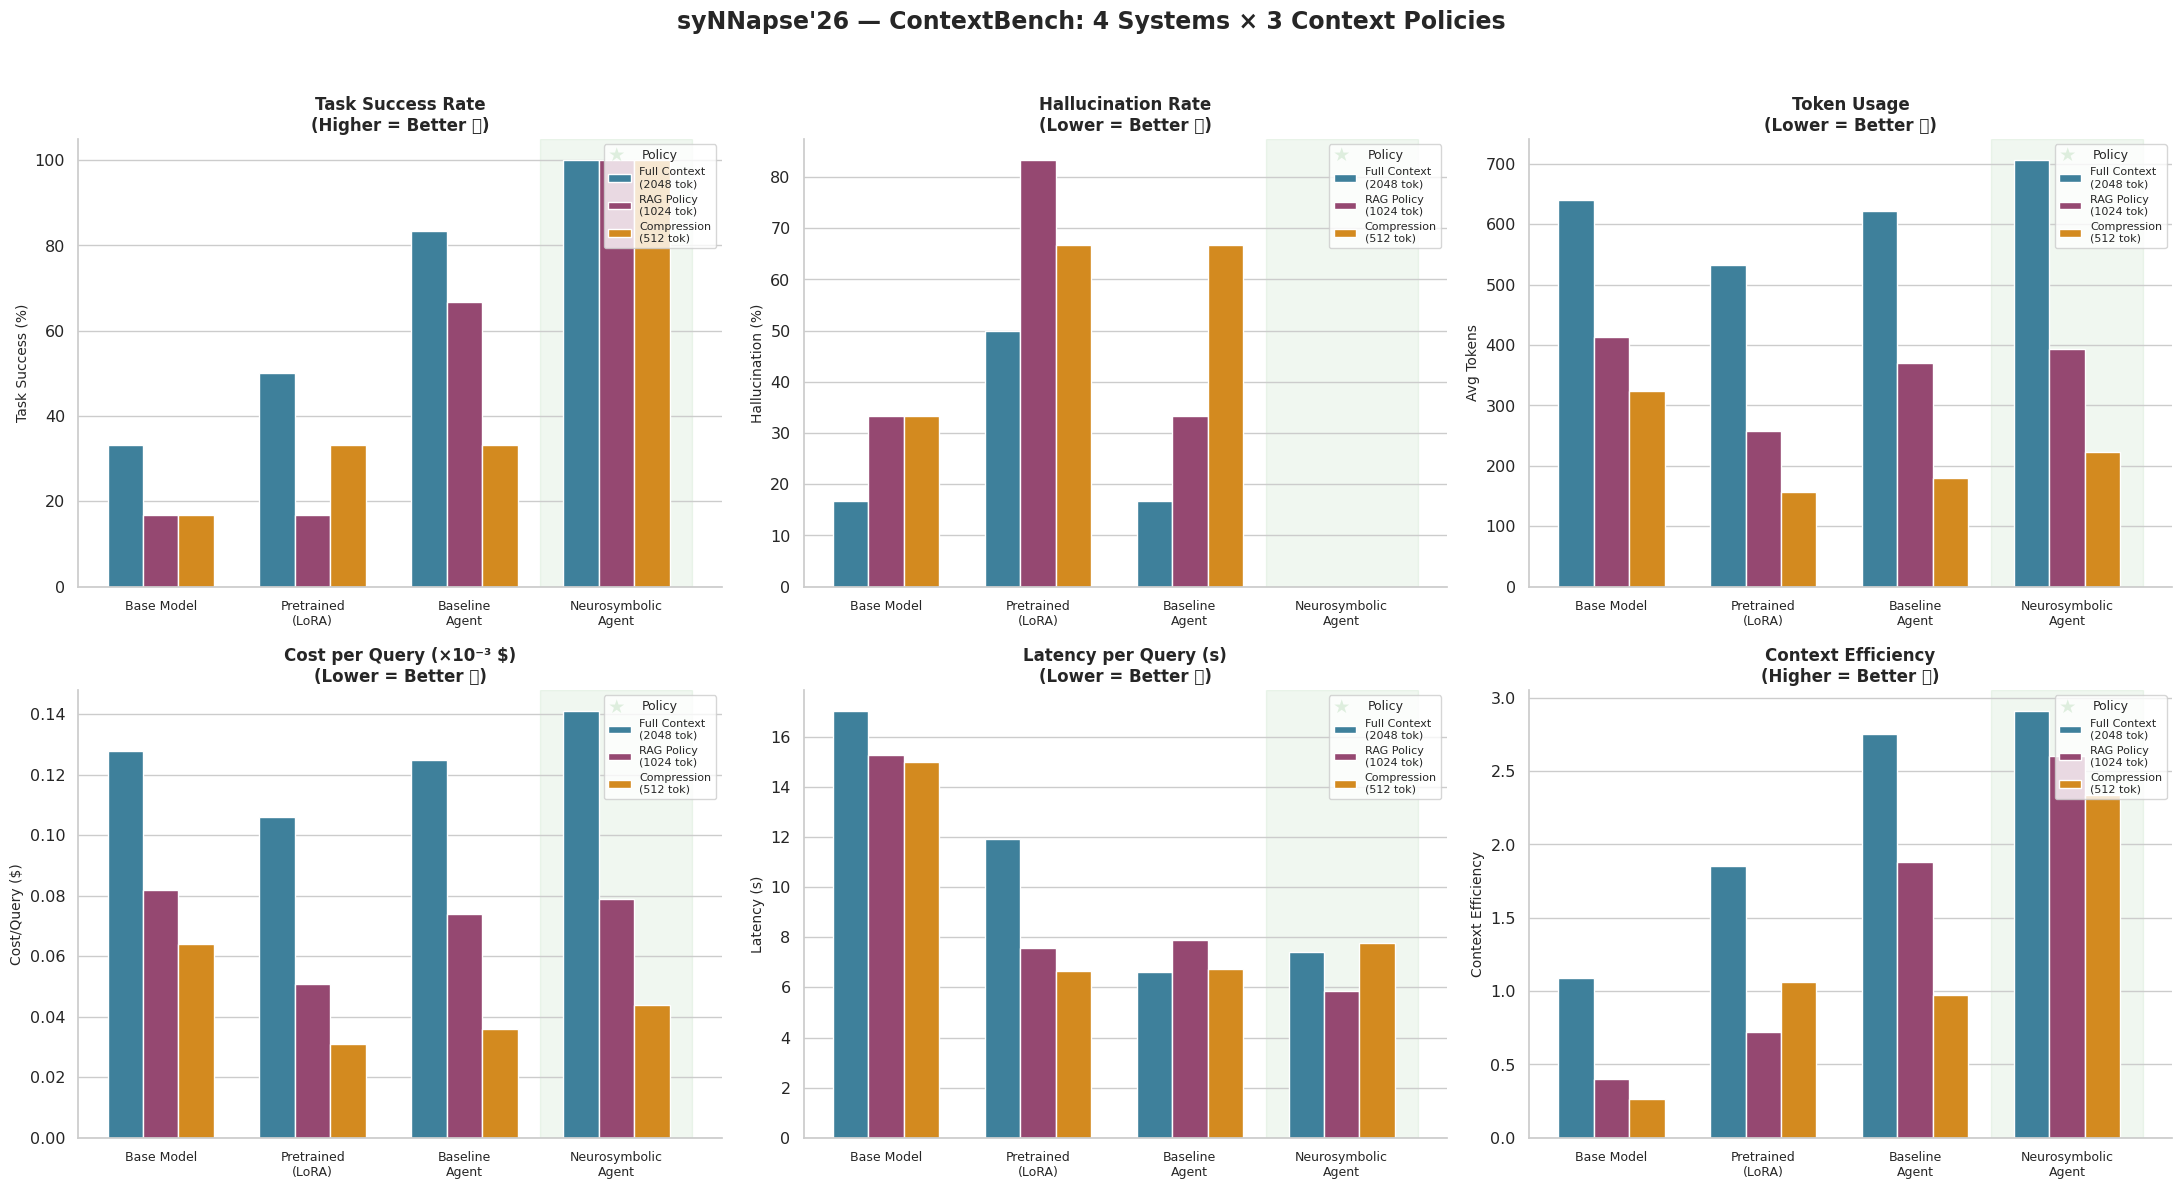

✅ Figure 1 saved: /content/drive/MyDrive/syNNapse26/contextbench/plots/cb_main_comparison.png


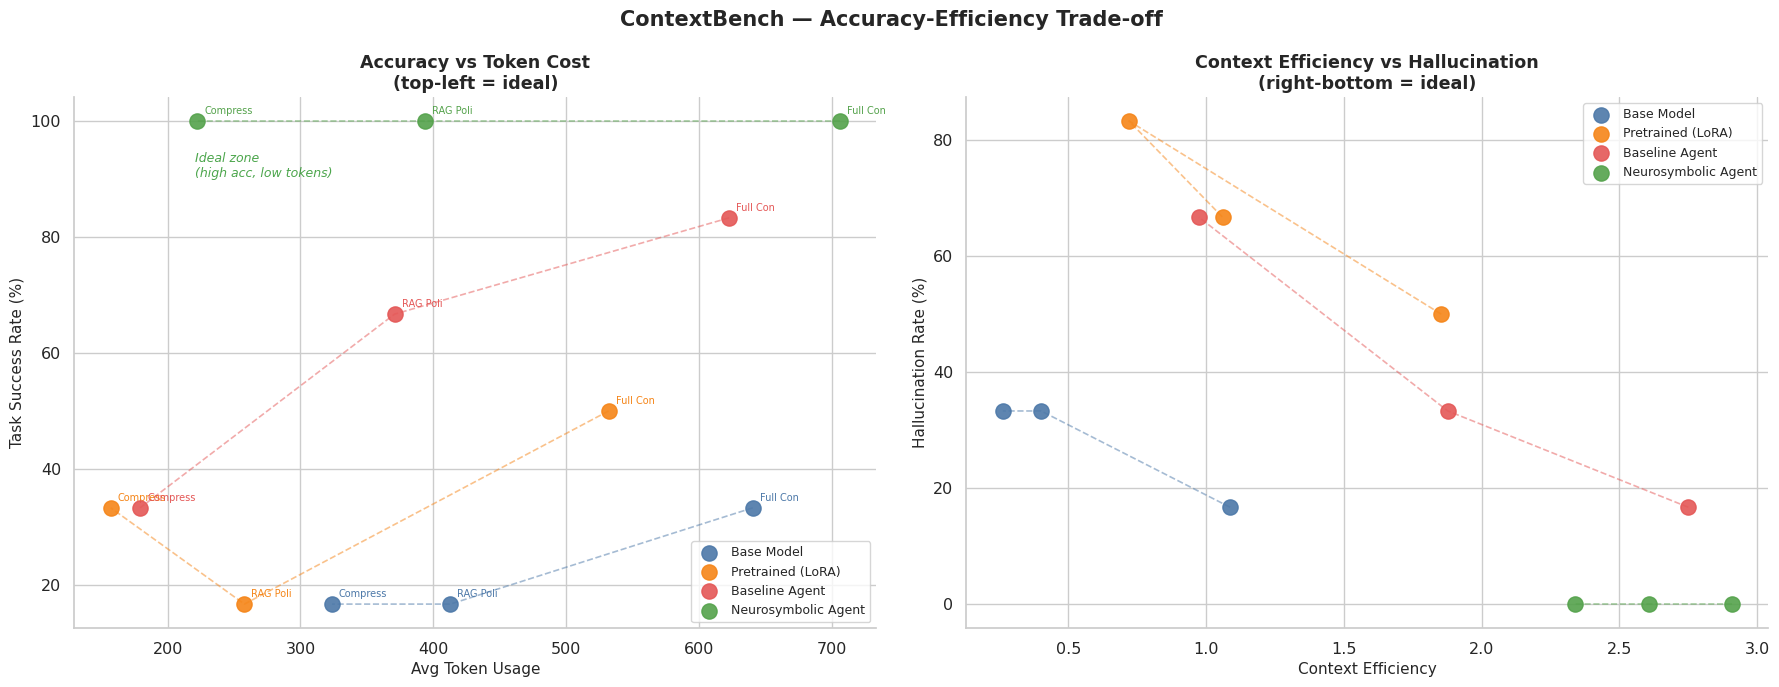

✅ Figure 2 saved: /content/drive/MyDrive/syNNapse26/contextbench/plots/cb_tradeoff_scatter.png


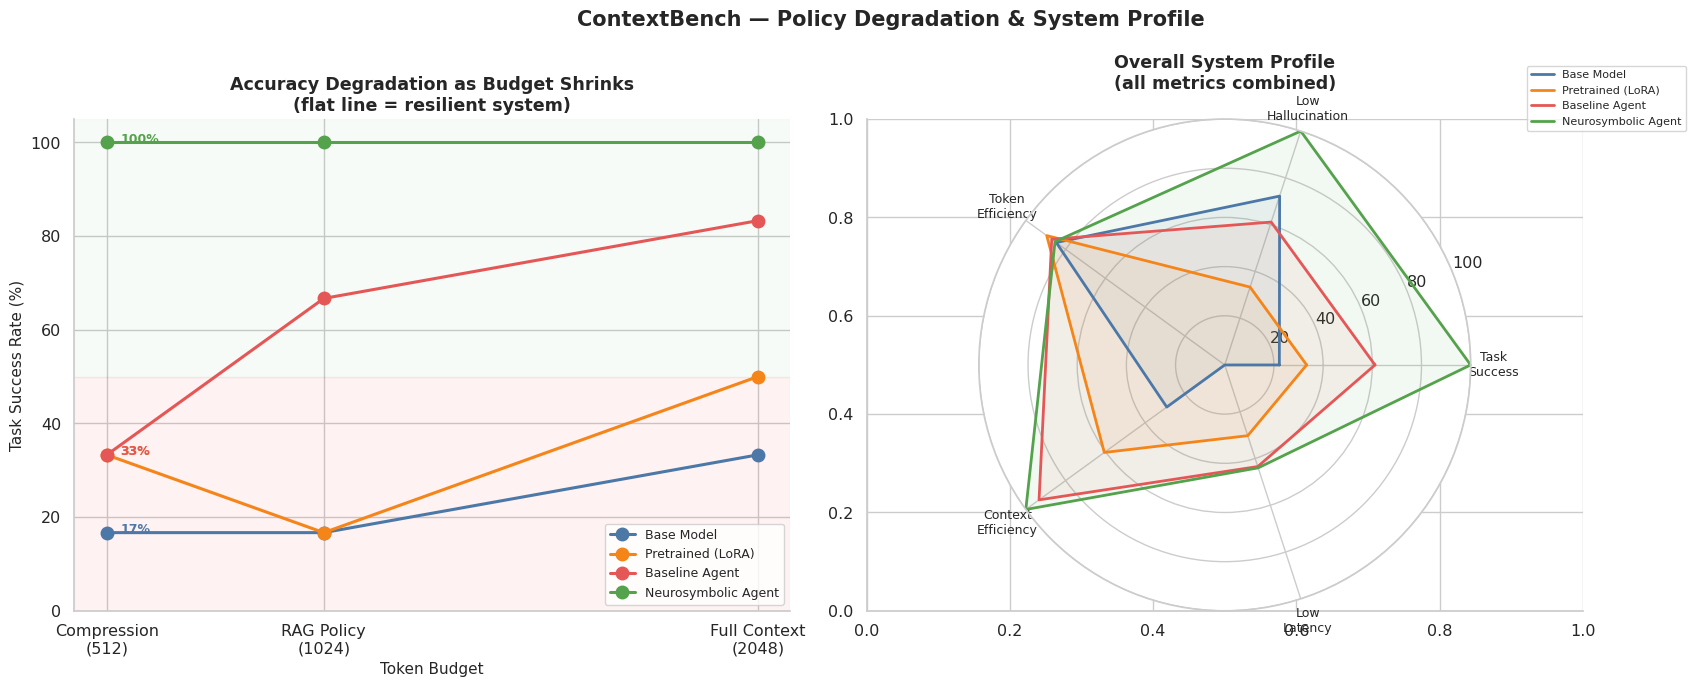

✅ Figure 3 saved: /content/drive/MyDrive/syNNapse26/contextbench/plots/cb_degradation_radar.png

✅ All ContextBench visualisations saved to: /content/drive/MyDrive/syNNapse26/contextbench/plots
   cb_main_comparison.png   → 6-panel grouped bar chart
   cb_tradeoff_scatter.png  → accuracy-efficiency scatter
   cb_degradation_radar.png → degradation lines + radar


In [42]:
# ══════════════════════════════════════════════════════════════
#  FIGURE 1: 6-panel main comparison (grouped by system)
#  Each plot shows all 3 policies as grouped bars per system
# ══════════════════════════════════════════════════════════════

fig1, axes = plt.subplots(2, 3, figsize=(22, 12))
fig1.suptitle(
    "syNNapse'26 — ContextBench: 4 Systems × 3 Context Policies",
    fontsize=17, fontweight='bold', y=0.99
)

pol_palette = {POLICY_LABELS[p]: c for p,c in zip(POLICIES, ['#2E86AB','#A23B72','#F18F01'])}

for ax, metric, title, lower_better in [
    (axes[0,0], 'Task Success (%)',   'Task Success Rate\n(Higher = Better ✅)',   False),
    (axes[0,1], 'Hallucination (%)',  'Hallucination Rate\n(Lower = Better ✅)',   True),
    (axes[0,2], 'Avg Tokens',         'Token Usage\n(Lower = Better ✅)',           True),
    (axes[1,0], 'Cost/Query ($)',      'Cost per Query (×10⁻³ $)\n(Lower = Better ✅)', True),
    (axes[1,1], 'Latency (s)',         'Latency per Query (s)\n(Lower = Better ✅)',True),
    (axes[1,2], 'Context Efficiency',  'Context Efficiency\n(Higher = Better ✅)', False),
]:
    sns.barplot(data=df, x='System', y=metric, hue='Policy',
                palette=pol_palette, ax=ax, width=0.7)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel(metric, fontsize=10)
    ax.tick_params(axis='x', labelsize=9)
    ax.legend(title='Policy', fontsize=8, title_fontsize=9, loc='upper right')
    # Highlight neurosymbolic column with subtle background
    ax.axvspan(2.5, 3.5, alpha=0.06, color='green', zorder=0)
    ax.text(3, ax.get_ylim()[1]*0.95, '★', ha='center', fontsize=14,
            color='green', alpha=0.6)

plt.tight_layout(rect=[0, 0, 1, 0.97])
p1 = f"{CB['PLOTS_DIR']}/cb_main_comparison.png"
plt.savefig(p1, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f"✅ Figure 1 saved: {p1}")


# ══════════════════════════════════════════════════════════════
#  FIGURE 2: Accuracy vs Token Trade-off Scatter
#  Each point = 1 system × 1 policy combination (12 points)
# ══════════════════════════════════════════════════════════════

fig2, axes2 = plt.subplots(1, 2, figsize=(18, 7))
fig2.suptitle("ContextBench — Accuracy-Efficiency Trade-off", fontsize=15, fontweight='bold')

# Left: Accuracy vs Tokens
ax = axes2[0]
for sys_key in SYSTEMS:
    xs, ys, labels = [], [], []
    for pol_key in POLICIES:
        s = SUMMARY[pol_key][sys_key]
        xs.append(s['avg_token_usage'])
        ys.append(s['task_success_rate_pct'])
        labels.append(POLICY_LABELS[pol_key].replace('\n',' '))

    ax.scatter(xs, ys, color=SYS_COLORS[sys_key], s=120, zorder=3,
               label=SYSTEM_LABELS[sys_key].replace('\n',' '), alpha=0.9)
    # Connect 3 policy points per system
    ax.plot(xs, ys, color=SYS_COLORS[sys_key], linewidth=1.2,
            linestyle='--', alpha=0.5)
    for x, y, lbl in zip(xs, ys, labels):
        ax.annotate(lbl[:8], (x, y), textcoords='offset points',
                    xytext=(5, 5), fontsize=7, color=SYS_COLORS[sys_key])

ax.set_xlabel('Avg Token Usage', fontsize=11)
ax.set_ylabel('Task Success Rate (%)', fontsize=11)
ax.set_title('Accuracy vs Token Cost\n(top-left = ideal)', fontweight='bold')
ax.legend(fontsize=9)
# Ideal zone annotation
ax.annotate('Ideal zone\n(high acc, low tokens)', xy=(0.15, 0.85),
            xycoords='axes fraction', fontsize=9, color='green',
            style='italic', alpha=0.7)

# Right: Context Efficiency vs Hallucination
ax = axes2[1]
for sys_key in SYSTEMS:
    xs = [SUMMARY[pol][sys_key]['avg_context_efficiency']  for pol in POLICIES]
    ys = [SUMMARY[pol][sys_key]['hallucination_rate_pct']  for pol in POLICIES]
    ax.scatter(xs, ys, color=SYS_COLORS[sys_key], s=120, zorder=3,
               label=SYSTEM_LABELS[sys_key].replace('\n',' '), alpha=0.9)
    ax.plot(xs, ys, color=SYS_COLORS[sys_key], linewidth=1.2,
            linestyle='--', alpha=0.5)

ax.set_xlabel('Context Efficiency', fontsize=11)
ax.set_ylabel('Hallucination Rate (%)', fontsize=11)
ax.set_title('Context Efficiency vs Hallucination\n(right-bottom = ideal)', fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
p2 = f"{CB['PLOTS_DIR']}/cb_tradeoff_scatter.png"
plt.savefig(p2, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f"✅ Figure 2 saved: {p2}")


# ══════════════════════════════════════════════════════════════
#  FIGURE 3: Policy Degradation Lines + Radar
#  Shows how each system degrades as token budget shrinks
# ══════════════════════════════════════════════════════════════

fig3, axes3 = plt.subplots(1, 2, figsize=(18, 7))
fig3.suptitle("ContextBench — Policy Degradation & System Profile", fontsize=15, fontweight='bold')

# Left: Accuracy degradation as budget tightens
ax = axes3[0]
budgets = [2048, 1024, 512]
for sys_key in SYSTEMS:
    accs = [SUMMARY[pol][sys_key]['task_success_rate_pct'] for pol in POLICIES]
    ax.plot(budgets, accs, marker='o', color=SYS_COLORS[sys_key],
            linewidth=2.2, markersize=9,
            label=SYSTEM_LABELS[sys_key].replace('\n',' '))
    ax.annotate(f"{accs[-1]:.0f}%",
                (512, accs[-1]), xytext=(10, 0),
                textcoords='offset points', fontsize=9,
                color=SYS_COLORS[sys_key], fontweight='bold')

ax.set_xlabel('Token Budget', fontsize=11)
ax.set_ylabel('Task Success Rate (%)', fontsize=11)
ax.set_title('Accuracy Degradation as Budget Shrinks\n(flat line = resilient system)',
             fontweight='bold')
ax.set_xticks(budgets)
ax.set_xticklabels(['Full Context\n(2048)', 'RAG Policy\n(1024)', 'Compression\n(512)'])
ax.legend(fontsize=9)
ax.set_ylim(0, 105)
ax.axhspan(0, 50, alpha=0.05, color='red')
ax.axhspan(50, 105, alpha=0.03, color='green')

# Right: Radar chart — overall profile
ax_r = fig3.add_subplot(1, 2, 2, polar=True)
categories = ['Task\nSuccess', 'Low\nHallucination', 'Token\nEfficiency',
              'Context\nEfficiency', 'Low\nLatency']
Nc = len(categories)

for sys_key in SYSTEMS:
    o = OVERALL[sys_key]
    vals = [
        o['task_success_rate_pct'],
        100 - o['hallucination_rate_pct'],
        max(0, 100 - o['avg_token_usage'] / 30),   # normalize tokens to 0-100
        min(100, o['avg_context_efficiency'] * 50),  # scale CE to 0-100
        max(0, 100 - o['avg_latency_sec'] * 8),     # lower latency = higher score
    ]
    angles  = [i/Nc*2*np.pi for i in range(Nc)] + [0]
    vals_c  = vals + vals[:1]
    ax_r.plot(angles, vals_c, '-', lw=2, color=SYS_COLORS[sys_key],
              label=SYSTEM_LABELS[sys_key].replace('\n',' '))
    ax_r.fill(angles, vals_c, alpha=0.07, color=SYS_COLORS[sys_key])

ax_r.set_xticks([i/Nc*2*np.pi for i in range(Nc)])
ax_r.set_xticklabels(categories, size=9)
ax_r.set_ylim(0, 100)
ax_r.set_title('Overall System Profile\n(all metrics combined)', fontweight='bold', pad=22)
ax_r.legend(loc='upper right', bbox_to_anchor=(1.45, 1.12), fontsize=8)

plt.tight_layout()
p3 = f"{CB['PLOTS_DIR']}/cb_degradation_radar.png"
plt.savefig(p3, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f"✅ Figure 3 saved: {p3}")

print(f"\n✅ All ContextBench visualisations saved to: {CB['PLOTS_DIR']}")
print(f"   cb_main_comparison.png   → 6-panel grouped bar chart")
print(f"   cb_tradeoff_scatter.png  → accuracy-efficiency scatter")
print(f"   cb_degradation_radar.png → degradation lines + radar")


## Final ContextBench Report
Generates the complete PS-required result report:    
 - Model benchmark results (loaded from earlier notebook)  
 - Agent benchmark results (loaded from earlier notebook)  
  - ContextBench results     
 - Combined final table (all systems, all metrics)   

In [43]:
import json, pandas as pd
from IPython.display import display, HTML

with open('/content/drive/MyDrive/syNNapse26/contextbench/cb_config.json') as f:
    CB = json.load(f)
with open(f"{CB['CB_DIR']}/summary_aggregated.json") as f:
    AGG = json.load(f)

OVERALL = AGG['overall']
SUMMARY = AGG['per_policy']

# Try loading earlier benchmark results for combined table
try:
    with open(f"{CB['BASE_DIR']}/base_results/summary.json") as f:
        MODEL_BASE = json.load(f)
    with open(f"{CB['BASE_DIR']}/pretrained_results/summary.json") as f:
        MODEL_PT = json.load(f)
    with open(f"{CB['BASE_DIR']}/agent_benchmark/baseline_agent/summary.json") as f:
        AGENT_BASE = json.load(f)
    with open(f"{CB['BASE_DIR']}/agent_benchmark/neurosymbolic_agent/summary.json") as f:
        AGENT_NS = json.load(f)
    has_prev = True
    print("✅ Loaded results from model + agent notebooks")
except Exception as e:
    has_prev = False
    print(f"⚠️  Previous results not found ({e}). Showing ContextBench only.")


# ══════════════════════════════════════════════════════════════
#  FINAL COMBINED REPORT TABLE
#  All systems × all benchmark types
# ══════════════════════════════════════════════════════════════

print("\n" + "=" * 75)
print("📊 FINAL COMBINED REPORT — syNNapse'26 Complete Benchmark")
print("=" * 75)

combined_rows = []

if has_prev:
    combined_rows.append({
        'System'                    : '🔵 Base Model',
        'Phase'                     : 'Model Bench',
        'Diagnosis Acc (%)'         : MODEL_BASE.get('disease_accuracy_pct', '-'),
        'Hallucination (%)'         : MODEL_BASE.get('hallucination_rate_pct', '-'),
        'Task Success (%)'          : '-',
        'CB Accuracy (%)'           : OVERALL['base_model']['task_success_rate_pct'],
        'Avg Tokens'                : OVERALL['base_model']['avg_token_usage'],
        'Cost/Query ($)'            : f"${OVERALL['base_model']['avg_cost_per_query']:.5f}",
        'Ctx Efficiency'            : OVERALL['base_model']['avg_context_efficiency'],
    })
    combined_rows.append({
        'System'                    : '🟠 Pretrained (LoRA)',
        'Phase'                     : 'Model Bench',
        'Diagnosis Acc (%)'         : MODEL_PT.get('disease_accuracy_pct', '-'),
        'Hallucination (%)'         : MODEL_PT.get('hallucination_rate_pct', '-'),
        'Task Success (%)'          : '-',
        'CB Accuracy (%)'           : OVERALL['pretrained_model']['task_success_rate_pct'],
        'Avg Tokens'                : OVERALL['pretrained_model']['avg_token_usage'],
        'Cost/Query ($)'            : f"${OVERALL['pretrained_model']['avg_cost_per_query']:.5f}",
        'Ctx Efficiency'            : OVERALL['pretrained_model']['avg_context_efficiency'],
    })
    combined_rows.append({
        'System'                    : '🟡 Baseline Agent',
        'Phase'                     : 'Agent Bench',
        'Diagnosis Acc (%)'         : AGENT_BASE.get('disease_accuracy_pct', '-'),
        'Hallucination (%)'         : AGENT_BASE.get('hallucination_rate_pct', '-'),
        'Task Success (%)'          : AGENT_BASE.get('disease_accuracy_pct', '-'),
        'CB Accuracy (%)'           : OVERALL['baseline_agent']['task_success_rate_pct'],
        'Avg Tokens'                : OVERALL['baseline_agent']['avg_token_usage'],
        'Cost/Query ($)'            : f"${OVERALL['baseline_agent']['avg_cost_per_query']:.5f}",
        'Ctx Efficiency'            : OVERALL['baseline_agent']['avg_context_efficiency'],
    })
    combined_rows.append({
        'System'                    : '🟢 Neurosymbolic Agent',
        'Phase'                     : 'Agent Bench',
        'Diagnosis Acc (%)'         : AGENT_NS.get('disease_accuracy_pct', '-'),
        'Hallucination (%)'         : AGENT_NS.get('hallucination_rate_pct', '-'),
        'Task Success (%)'          : AGENT_NS.get('disease_accuracy_pct', '-'),
        'CB Accuracy (%)'           : OVERALL['neurosymbolic_agent']['task_success_rate_pct'],
        'Avg Tokens'                : OVERALL['neurosymbolic_agent']['avg_token_usage'],
        'Cost/Query ($)'            : f"${OVERALL['neurosymbolic_agent']['avg_cost_per_query']:.5f}",
        'Ctx Efficiency'            : OVERALL['neurosymbolic_agent']['avg_context_efficiency'],
    })
else:
    SYSTEM_LABELS = {
        'base_model'         : '🔵 Base Model',
        'pretrained_model'   : '🟠 Pretrained (LoRA)',
        'baseline_agent'     : '🟡 Baseline Agent',
        'neurosymbolic_agent': '🟢 Neurosymbolic Agent',
    }
    for sys_key in CB['SYSTEMS']:
        o = OVERALL[sys_key]
        combined_rows.append({
            'System'         : SYSTEM_LABELS[sys_key],
            'CB Accuracy (%)': o['task_success_rate_pct'],
            'Hallucination (%)': o['hallucination_rate_pct'],
            'Avg Tokens'     : int(o['avg_token_usage']),
            'Cost/Query ($)' : f"${o['avg_cost_per_query']:.5f}",
            'Latency (s)'    : o['avg_latency_sec'],
            'Ctx Efficiency' : o['avg_context_efficiency'],
        })

df_final = pd.DataFrame(combined_rows)

styled_final = (
    df_final.style
    .set_caption("🏆 syNNapse'26 — Complete Benchmark Report (All 3 Phases)")
    .set_properties(**{'text-align':'center','font-size':'13px','padding':'9px 14px',
                       'border':'1px solid #ddd'})
    .set_table_styles([
        {'selector':'caption',
         'props':[('font-size','16px'),('font-weight','bold'),
                  ('padding','12px'),('text-align','left')]},
        {'selector':'th',
         'props':[('background-color','#1b2631'),('color','white'),
                  ('font-weight','bold'),('padding','11px')]}
    ])
)
display(styled_final)

# ── Per-policy summary ─────────────────────────────────────────
print("\n📊 PER-POLICY ACCURACY SUMMARY (PS required format)")
print(f"{'System':<25} {'Full Ctx':>12} {'RAG Policy':>12} {'Compression':>12}")
print("-" * 63)
SYSTEM_LABELS = {
    'base_model':'Base Model','pretrained_model':'Pretrained (LoRA)',
    'baseline_agent':'Baseline Agent','neurosymbolic_agent':'Neurosymbolic Agent'
}
for sys_key in CB['SYSTEMS']:
    accs = [SUMMARY[pol][sys_key]['task_success_rate_pct'] for pol in CB['POLICIES']]
    print(f"  {SYSTEM_LABELS[sys_key]:<23} {accs[0]:>10.1f}%  {accs[1]:>10.1f}%  {accs[2]:>10.1f}%")

# Save
df_final.to_csv(f"{CB['CB_DIR']}/final_combined_report.csv", index=False)
print(f"\n✅ Final report saved: {CB['CB_DIR']}/final_combined_report.csv")
print(f"\n CONTEXTBENCH COMPLETE!")
print(f"\n   Drive → {CB['CB_DIR']}/")
print(f"   ├── configs/           ← 3 YAML experiment configs")
print(f"   ├── dataset/           ← tasks.json + ontology_snippet.txt")
print(f"   ├── all_results.json   ← raw experiment data")
print(f"   ├── table1_ps_format.csv")
print(f"   ├── table2_full_metrics.csv")
print(f"   ├── table3_per_policy.csv")
print(f"   ├── final_combined_report.csv")
print(f"   └── plots/")
print(f"       ├── cb_main_comparison.png")
print(f"       ├── cb_tradeoff_scatter.png")
print(f"       └── cb_degradation_radar.png")

✅ Loaded results from model + agent notebooks

📊 FINAL COMBINED REPORT — syNNapse'26 Complete Benchmark


,System,Phase,Diagnosis Acc (%),Hallucination (%),Task Success (%),CB Accuracy (%),Avg Tokens,Cost/Query ($),Ctx Efficiency
0,🔵 Base Model,Model Bench,30.000000,68.000000,-,22.200000,458.900000,$0.00009,0.583000
1,🟠 Pretrained (LoRA),Model Bench,60.000000,40.000000,-,33.300000,315.600000,$0.00006,1.211000
2,🟡 Baseline Agent,Agent Bench,38.500000,53.800000,38.500000,61.100000,390.900000,$0.00008,1.867000
3,🟢 Neurosymbolic Agent,Agent Bench,53.800000,46.200000,53.800000,100.000000,440.600000,$0.00009,2.618000



📊 PER-POLICY ACCURACY SUMMARY (PS required format)
System                        Full Ctx   RAG Policy  Compression
---------------------------------------------------------------
  Base Model                    33.3%        16.7%        16.7%
  Pretrained (LoRA)             50.0%        16.7%        33.3%
  Baseline Agent                83.3%        66.7%        33.3%
  Neurosymbolic Agent          100.0%       100.0%       100.0%

✅ Final report saved: /content/drive/MyDrive/syNNapse26/contextbench/final_combined_report.csv

 CONTEXTBENCH COMPLETE!

   Drive → /content/drive/MyDrive/syNNapse26/contextbench/
   ├── configs/           ← 3 YAML experiment configs
   ├── dataset/           ← tasks.json + ontology_snippet.txt
   ├── all_results.json   ← raw experiment data
   ├── table1_ps_format.csv
   ├── table2_full_metrics.csv
   ├── table3_per_policy.csv
   ├── final_combined_report.csv
   └── plots/
       ├── cb_main_comparison.png
       ├── cb_tradeoff_scatter.png
       └── cb_